In [1]:
# NOTE: This file is the source for three Jupyter notebook cells.
# Copy each section into its own cell.
# =============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · API path · Global parameters · Fixed refractive indices ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import os
import platform
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import h5py

# ─────────────────────────────────────────────────────────────────────────────
# Lumerical installation paths
# ► Set LUMERICAL_VERSION to exactly match your installation folder name.
#   Check:  C:\Program Files\Lumerical\   and read the subfolder name.
# ─────────────────────────────────────────────────────────────────────────────
LUMERICAL_VERSION = "v202"          # ← confirmed from your traceback

if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

# ── 1. Clear any previously cached failed import ─────────────────────────────
# If lumapi was imported and failed in this kernel session, Python stores the
# broken module in sys.modules and returns the same failure on every retry.
# Removing it forces a clean re-import.
if "lumapi" in sys.modules:
    del sys.modules["lumapi"]

# ── 2. Add the API folder to sys.path ────────────────────────────────────────
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)

# ── 3. Register the bin directory as a DLL search path ───────────────────────
# REQUIRED on Python 3.8+ (you are on 3.11).
# os.environ["PATH"] manipulation does NOT work for CDLL() from Python 3.8
# onwards — Windows changed DLL resolution to ignore PATH by default.
# os.add_dll_directory() is the correct API.
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):          # Python 3.8+  ← your case
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:                                          # Python < 3.8 fallback
        os.environ["PATH"] = (
            str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")
        )

# ── 4. Verify the paths exist before importing ───────────────────────────────
assert Path(LUMERICAL_API).exists(), (
    f"Lumerical API path not found:\n  {LUMERICAL_API}\n"
    f"Check LUMERICAL_VERSION = '{LUMERICAL_VERSION}'"
)
assert Path(LUMERICAL_BIN).exists(), (
    f"Lumerical bin path not found:\n  {LUMERICAL_BIN}"
)

import lumapi  # noqa — must come after all path setup above
print(f"lumapi imported successfully from:\n  {lumapi.__file__}")

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger("SiN_FDE")

# ─────────────────────────────────────────────────────────────────────────────
# I/O  ─ directory and HDF5 output path
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME = "LUM_SiN_STRp_400nm_wdth_sweep_V1"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_STRp_SiN_mode_analysis_LUM"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"

# ─────────────────────────────────────────────────────────────────────────────
# Waveguide geometry  (µm throughout unless stated)
#
#  Cross-section  (Y-Z plane, X = propagation direction):
#
#     ┌────────────────────────────────────────────┐
#     │        Aqueous  n = 1.33  (upper clad)     │  z >  +core_t/2
#     │     ┌────────────────────┐                 │
#     │     │       SiN          │  core_t = 0.4   │  z ∈ [-0.2, +0.2] µm
#     │     └────────────────────┘                 │
#     │        SiO₂  n = 1.4469  (lower clad)      │  z < -0.2 µm
#     └────────────────────────────────────────────┘
#              ←—— width sweep ——→
# ─────────────────────────────────────────────────────────────────────────────
CORE_THICKNESS_UM  = 0.400    # SiN core height  [µm]
N_MODES_REQUEST    = 6        # max modes to request from the FDE eigenvalue solver

# Simulation domain margins
SIM_Y_MARGIN_UM    = 2.5      # lateral cladding margin each side beyond core half-width [µm]
SIM_Z_BELOW_UM     = 2.0      # SiO₂ substrate depth below core bottom [µm]
SIM_Z_ABOVE_UM     = 2.0      # aqueous depth above core top           [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Fixed refractive indices  (evaluated at 1550 nm via Sellmeier,
# held constant across the entire wavelength and width sweep)
#
#   n_SiN  = sqrt(1 + 2.9144·λ²/(λ²-0.1366²) + 0.004873/(λ²-1.6606²))
#          → 1.980780 at 1550 nm
#
#   n_SiO2 = sqrt(1 + 1.1056·λ²/(λ²-0.078²) + 2.360·λ²/(λ²-16.681²)) + 0.002
#          → 1.446940 at 1550 nm
#
#   n_aq   = 1.33   (aqueous medium, constant by definition)
# ─────────────────────────────────────────────────────────────────────────────
N_SIN_FIXED   = 1.99   # SiN  @ 1550 nm  — used for FDE index and mesh sizing
N_SIO2_FIXED  = 1.4469   # SiO₂ @ 1550 nm  — used for FDE index and guided-mode cutoff
N_UPPER_CLADDING = 1.33  # aqueous medium   — used for FDE index (constant)

# ─────────────────────────────────────────────────────────────────────────────
# Width sweep   600 nm → 1500 nm,  100 uniformly-spaced points
# ─────────────────────────────────────────────────────────────────────────────
SWEEP_WIDTHS_UM = np.linspace(0.600, 1.500, 100)    # [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Wavelength sweep  :  λ₀ = 1550 nm  +  12 jumps of (10/13) nm  →  13 points
#
#   λₙ = 1550 + n × (10/13)  nm      n = 0, 1, … 12
#   λ₁₂ = 1550 + 120/13 ≈ 1559.2308 nm
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_START_NM  = 1550.0
DELTA_LAMBDA_NM  = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
N_WAVELENGTHS    = 13                    # 0 … 12 inclusive
SWEEP_WL_NM  = LAMBDA_START_NM + np.arange(N_WAVELENGTHS) * DELTA_LAMBDA_NM
SWEEP_WL_UM  = SWEEP_WL_NM * 1e-3       # [µm]
SWEEP_WL_M   = SWEEP_WL_UM * 1e-6       # [m]  — Lumerical SI units

# ─────────────────────────────────────────────────────────────────────────────
# Derived domain dimensions
# ─────────────────────────────────────────────────────────────────────────────
# y: accommodate the widest core (1.5 µm) + 2 × lateral margin
SIM_Y_SPAN_UM  = SWEEP_WIDTHS_UM.max() + 2.0 * SIM_Y_MARGIN_UM      # 6.5 µm

# z: SiO₂ below  +  core  +  aqueous above
SIM_Z_SPAN_UM  = SIM_Z_BELOW_UM + CORE_THICKNESS_UM + SIM_Z_ABOVE_UM # 4.4 µm

# ─────────────────────────────────────────────────────────────────────────────
# Mesh sizing:  target ≈ λ_max / (N_SIN_FIXED × 10)
#   i.e. 10 mesh cells per wavelength inside the core material.
#   N_SIN_FIXED is used directly here — no separate approximation variable.
#
# Raise MESH_CELLS_PER_WVL to 15–20 for publication-grade neff accuracy.
# ─────────────────────────────────────────────────────────────────────────────
MESH_CELLS_PER_WVL = 10
_mesh_step_um      = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
MESH_CELLS_Y       = int(np.ceil(SIM_Y_SPAN_UM / _mesh_step_um))   # ≈ 83
MESH_CELLS_Z       = int(np.ceil(SIM_Z_SPAN_UM / _mesh_step_um))   # ≈ 56

# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)")
print("=" * 62)
print(f"  Version      : {VERSION_NAME}")
print(f"  Widths       : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)")
print(f"  Wavelengths  : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts,  Δλ = 10/13 ≈ {DELTA_LAMBDA_NM:.5f} nm)")
print(f"  Core h       : {CORE_THICKNESS_UM*1e3:.0f} nm")
print(f"  n_SiN        : {N_SIN_FIXED}  (fixed @ 1550 nm)")
print(f"  n_SiO₂       : {N_SIO2_FIXED}  (fixed @ 1550 nm)  ← guided-mode cutoff")
print(f"  n_aqueous    : {N_UPPER_CLADDING}  (constant)")
print(f"  Domain       : y = {SIM_Y_SPAN_UM:.2f} µm,  z = {SIM_Z_SPAN_UM:.2f} µm")
print(f"  Mesh step    : ≈ {_mesh_step_um*1e3:.1f} nm  "
      f"({MESH_CELLS_Y} × {MESH_CELLS_Z} cells,  "
      f"≈ λ_max / (n_SiN × {MESH_CELLS_PER_WVL}))")
print(f"  Total FDE    : {len(SWEEP_WIDTHS_UM)} × {N_WAVELENGTHS} = "
      f"{len(SWEEP_WIDTHS_UM)*N_WAVELENGTHS} runs")
print(f"  HDF5 output  : {HDF5_PATH}")
print("=" * 62)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FDE helpers  +  main sweep function                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Helper 1 :  _init_fde_geometry
#   Clears the session, creates the FDE solver region and the three material
#   rectangles.  Called ONCE at the start; geometry is then updated in-loop
#   via setnamed() to avoid rebuilding from scratch on every width step.
#
#   Material indices are set from the fixed constants N_SIN_FIXED,
#   N_SIO2_FIXED, N_UPPER_CLADDING — no Sellmeier evaluation.
#
#   Structure override order (same default mesh-order → last added wins):
#     1st added  →  Aqueous_bg          (background, lowest priority)
#     2nd added  →  SiO2_lower_clad     (overrides Aqueous below the core)
#     3rd added  →  SiN_core            (overrides everything, highest priority)
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
):
    """
    Creates FDE solver region + three material rectangles in a clean session.
    Indices are taken directly from the module-level constants
    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : Aqueous background (full domain, lowest priority) ────
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)             # 1.33, constant

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    # Spans full y, from domain bottom up to the core bottom (z = -core_t/2)
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)                 # 1.4469, fixed

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    # y span is updated in the inner width loop; all other dims are fixed.
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)                  # 1.9808, fixed


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2 :  _extract_mode_results
#   After findmodes() reads neff (complex), TE polarization fraction, and
#   counts guided modes.
#
#   Guided criterion:  Re(neff) > N_SIO2_FIXED
#   This is the physically correct cutoff for an asymmetric waveguide whose
#   highest-index cladding is SiO₂.  Radiation modes discretised by the
#   finite simulation domain have neff < N_SIO2_FIXED and are filtered out.
#
#   Returns arrays of shape (n_modes_request,) — NaN where a mode was not found.
# ─────────────────────────────────────────────────────────────────────────────
def _extract_mode_results(mode, n_modes_request: int):
    """
    Extract neff (complex), TE fraction, and guided-mode count from the FDE
    result after findmodes().

    Uses N_SIO2_FIXED (module-level constant) as the guided-mode cutoff.

    Returns
    -------
    neff_real : np.ndarray  (n_modes_request,)   Re(neff), NaN if not found
    neff_imag : np.ndarray  (n_modes_request,)   Im(neff)
    te_frac   : np.ndarray  (n_modes_request,)   TE polarization fraction
    n_guided  : int                               count of guided modes
    """
    neff_real = np.full(n_modes_request, np.nan, dtype=np.float64)
    neff_imag = np.full(n_modes_request, np.nan, dtype=np.float64)
    te_frac   = np.full(n_modes_request, np.nan, dtype=np.float64)
    n_guided  = 0

    for m_i in range(1, n_modes_request + 1):
        mode_grp = f"FDE::data::mode{m_i}"
        try:
            raw_neff = mode.getdata(mode_grp, "neff")
            raw_te   = mode.getdata(mode_grp, "TE polarization fraction")
        except Exception:
            break   # no more modes available — stop

        # Normalise to Python scalar regardless of array shape returned
        neff_c = complex(np.asarray(raw_neff).flat[0])
        te_v   = float(np.asarray(raw_te).flat[0])

        neff_real[m_i - 1] = neff_c.real
        neff_imag[m_i - 1] = neff_c.imag
        te_frac  [m_i - 1] = te_v

        # Guided-mode test: Re(neff) must exceed the highest cladding index
        if neff_c.real > N_SIO2_FIXED:
            n_guided += 1

    return neff_real, neff_imag, te_frac, n_guided


# ─────────────────────────────────────────────────────────────────────────────
# Helper 3 :  _init_hdf5
#   Creates a fresh HDF5 file with pre-allocated datasets and full metadata.
#   Uses chunked storage so incremental slice-writes are efficient.
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(
    path            : Path,
    n_w             : int,
    n_wl            : int,
    n_modes         : int,
    sweep_widths_um : np.ndarray,
    sweep_wl_um     : np.ndarray,
    metadata        : dict,
):
    with h5py.File(path, "w") as f:
        # — metadata group ————————————————————————————————————————————————————
        md = f.create_group("metadata")
        md.create_dataset("sweep_widths_um",      data=sweep_widths_um)
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_um * 1e3)
        md.create_dataset("sweep_wavelengths_um", data=sweep_wl_um)
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        # — result datasets  (NaN-initialised, chunked per width row) ─────────
        chunk_shape = (1, n_wl, n_modes)
        nan3d = np.full((n_w, n_wl, n_modes), np.nan, dtype=np.float64)
        rg = f.create_group("results")
        rg.create_dataset("neff_real", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("neff_imag", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("te_frac",   data=nan3d, chunks=chunk_shape)
        rg.create_dataset("n_guided",
                          data=np.zeros((n_w, n_wl), dtype=np.int32),
                          chunks=(1, n_wl))

        # — progress flag ─────────────────────────────────────────────────────
        f.create_group("flags").create_dataset(
            "computed",
            data=np.zeros((n_w, n_wl), dtype=bool),
            chunks=(1, n_wl),
        )


# ─────────────────────────────────────────────────────────────────────────────
# Main function :  run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,           # set True for headless / HPC runs
):
    """
    2-D FDE width sweep for a straight SiN waveguide on SiO₂ with aqueous top
    cladding, using Lumerical MODE Solutions via the Python lumapi.

    Material indices are fixed constants (N_SIN_FIXED, N_SIO2_FIXED,
    N_UPPER_CLADDING) — no Sellmeier evaluation at any point.

    Sweep axes
    ----------
    - Inner  :  SiN core y-span  (600 nm → 1500 nm,  100 pts)
    - Outer  :  wavelength        (1550.0 nm → 1559.23 nm,  13 pts)

    At each (width, λ) point the function
      1. Updates the FDE solver wavelength and the core y-span.
      2. Runs mesh  →  findmodes()  →  extracts neff + TE fraction.
      3. Counts guided modes  (Re(neff) > N_SIO2_FIXED).
      4. Writes results to HDF5 immediately and flushes — safe to interrupt.

    Re-running skips already-computed points automatically (cache check via
    flags/computed dataset in HDF5).

    Returns
    -------
    dict with keys:
        neff_real       np.ndarray  [n_widths, n_wl, n_modes_request]
        neff_imag       np.ndarray  [n_widths, n_wl, n_modes_request]
        te_frac         np.ndarray  [n_widths, n_wl, n_modes_request]
        n_guided        np.ndarray  [n_widths, n_wl]
        computed        np.ndarray  [n_widths, n_wl]  bool
        sweep_widths_um np.ndarray  [n_widths]  µm
        sweep_wl_nm     np.ndarray  [n_wl]      nm
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute all fixed geometry quantities ─────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um

    # Core sits at z = 0  →  SiO₂ slab spans  z ∈ [-(half_t + sim_z_below), -half_t]
    sio2_z_span = sim_z_below_um
    sio2_z_ctr  = -(half_t + sim_z_below_um / 2.0)

    # Simulation region centre (= 0 when below == above, i.e. symmetric domain)
    sim_z_ctr   = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : N_UPPER_CLADDING,
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        # Wavelength for the initial FDE setup: first point of the sweep.
        # Derived from the function parameter sweep_wl_um — not from any global.
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),   # µm → m
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        # ── Keep HDF5 open for the entire sweep  (flush after each point) ─────
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                # Fast-skip: all widths at this λ already cached
                if computed[:, wl_idx].all():
                    continue

                # Wavelength in SI metres — derived from function parameter
                wl_m = float(wl_um * 1e-6)

                # Only the FDE solver wavelength changes per outer iteration.
                # Material indices are fixed — no setnamed index update here.
                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  n_SiO₂ = {N_SIO2_FIXED}  "
                    f"n_aq = {N_UPPER_CLADDING}  (all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    # ── Cache check ───────────────────────────────────────
                    if computed[w_idx, wl_idx]:
                        continue

                    # ── Update core width (only geometry change per step) ──
                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    # ── Run FDE mesh  →  find modes ───────────────────────
                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        # Mark as done with NaN result to skip on re-run
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    # ── Extract and classify modes ─────────────────────────
                    # n_found is passed only for awareness; _extract_mode_results
                    # iterates up to n_modes_request and breaks on missing modes.
                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    # ── Store in memory ───────────────────────────────────
                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    # ── Write to HDF5  (incremental, fault-safe) ──────────
                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    # ── Progress report every 10 completed runs ───────────
                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            # ── Close-out metadata ────────────────────────────────────────
            hf["metadata"].attrs["timestamp_end"]   = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"]  = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Execute sweep + quick sanity output                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

results = run_width_sweep_fde()

# ── Unpack for downstream cells ───────────────────────────────────────────────
neff_real       = results["neff_real"]          # [n_widths, n_wl, n_modes]
neff_imag       = results["neff_imag"]
te_frac         = results["te_frac"]
n_guided        = results["n_guided"]           # [n_widths, n_wl]
computed        = results["computed"]
sweep_widths_um = results["sweep_widths_um"]    # [100]  µm
sweep_wl_nm     = results["sweep_wl_nm"]        # [13]   nm

print("\n" + "=" * 58)
print("  Sweep complete — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided.shape}")
print(f"  Points computed  : {computed.sum()} / {computed.size}")
print(f"  HDF5 saved to    : {HDF5_PATH}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided[i, 0]
    ne0    = neff_real[i, 0, 0]
    te0    = te_frac [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

11:40:23 │ INFO │ No cache found — initialising new HDF5 file.
11:40:23 │ INFO │ Launching Lumerical MODE …


lumapi imported successfully from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py
  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)
  Version      : LUM_SiN_STRp_400nm_wdth_sweep_V1
  Widths       : 600 → 1500 nm  (100 pts)
  Wavelengths  : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 ≈ 0.76923 nm)
  Core h       : 400 nm
  n_SiN        : 1.99  (fixed @ 1550 nm)
  n_SiO₂       : 1.4469  (fixed @ 1550 nm)  ← guided-mode cutoff
  n_aqueous    : 1.33  (constant)
  Domain       : y = 6.50 µm,  z = 4.40 µm
  Mesh step    : ≈ 78.4 nm  (83 × 57 cells,  ≈ λ_max / (n_SiN × 10))
  Total FDE    : 100 × 13 = 1300 runs
  HDF5 output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5


11:40:27 │ INFO │ Geometry initialised  (1300 FDE runs remaining) …
11:40:27 │ INFO │ ─── λ[ 0] = 1550.0000 nm │ n_SiN = 1.99  n_SiO₂ = 1.4469  n_aq = 1.33  (all fixed)
11:40:43 │ INFO │   [  10/1300]  w =  681.8 nm │ n_guided = 2 │ 0.6 sim/s │ ETA  2239 s
11:40:54 │ INFO │   [  20/1300]  w =  772.7 nm │ n_guided = 2 │ 0.7 sim/s │ ETA  1774 s
11:41:02 │ INFO │   [  30/1300]  w =  863.6 nm │ n_guided = 2 │ 0.8 sim/s │ ETA  1545 s
11:41:11 │ INFO │   [  40/1300]  w =  954.5 nm │ n_guided = 2 │ 0.9 sim/s │ ETA  1425 s
11:41:20 │ INFO │   [  50/1300]  w = 1045.5 nm │ n_guided = 2 │ 0.9 sim/s │ ETA  1352 s
11:41:29 │ INFO │   [  60/1300]  w = 1136.4 nm │ n_guided = 2 │ 1.0 sim/s │ ETA  1297 s
11:41:37 │ INFO │   [  70/1300]  w = 1227.3 nm │ n_guided = 2 │ 1.0 sim/s │ ETA  1257 s
11:41:45 │ INFO │   [  80/1300]  w = 1318.2 nm │ n_guided = 3 │ 1.0 sim/s │ ETA  1212 s
11:41:54 │ INFO │   [  90/1300]  w = 1409.1 nm │ n_guided = 3 │ 1.0 sim/s │ ETA  1186 s
11:42:03 │ INFO │   [ 100/1300]  w = 15


  Sweep complete — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

  Guided-mode count at λ = 1550.0000 nm  (first 15 widths):
  Width [nm]    n_guided    neff_mode0   TE_frac_0
  ----------------------------------------------
       600.0           2       1.49352       0.988
       609.1           2       1.49631       0.988
       618.2           2       1.49915       0.989
       627.3           2       1.50825       0.988
       636.4           2       1.51104       0.988
       645.5           2       1.51383       0.988
       654.5           2       1.51577       0.988
       663.6           2       1.51882       0.988
       672.7           2       1.52204       0.988
       681.8           2       1.52544       0.988
       690.9         

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — SiO₂ cladding sweep : new constants + extended functions         ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–3 ALREADY EXECUTED.                                       ║
# ║  All imports, sweep arrays, mesh constants, helper functions and the        ║
# ║  first-sweep result dict are live in the kernel namespace.                  ║
# ║                                                                             ║
# ║  Only two things change vs the aqueous sweep:                               ║
# ║    1. The background/upper-cladding index  (1.33 → N_SIO2_FIXED = 1.4469)  ║
# ║    2. The output HDF5 file                                                  ║
# ║                                                                             ║
# ║  Strategy: extend _init_fde_geometry and run_width_sweep_fde with one new  ║
# ║  optional parameter each (default = original value → zero behaviour        ║
# ║  change for the aqueous sweep if it is ever re-run).                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants only — nothing from Cell 1 is repeated
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_SIO2     = "LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1"
HDF5_PATH_SIO2        = DATA_DIR / f"{VERSION_NAME_SIO2}.h5"
N_UPPER_CLADDING_SIO2 = N_SIO2_FIXED      # 1.4469 — Silica replaces aqueous

print(f"SiO₂-cladding sweep")
print(f"  version  : {VERSION_NAME_SIO2}")
print(f"  output   : {HDF5_PATH_SIO2}")
print(f"  n_upper  : {N_UPPER_CLADDING_SIO2}  (Silica, symmetric stack)")
print(f"  n_lower  : {N_SIO2_FIXED}  (SiO₂ substrate — unchanged)")
print(f"  n_core   : {N_SIN_FIXED}   (SiN core — unchanged)")
print(f"  cutoff   : Re(neff) > {N_SIO2_FIXED}  (same threshold, now symmetric)")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Extended _init_fde_geometry
# ─────────────────────────────────────────────────────────────────────────────
# ONE change vs Cell-2 version:
#   parameter  n_background (default = N_UPPER_CLADDING)  replaces the
#   hardcoded  N_UPPER_CLADDING  on the Aqueous_bg rectangle.
# All other geometry, mesh and solver settings are identical.
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
    n_background      = N_UPPER_CLADDING,  # ← NEW: upper/lateral cladding index
                                           #   default keeps aqueous behaviour
):
    """
    Creates FDE solver region + three material rectangles in a clean session.

    n_background sets the index of the Aqueous_bg rectangle (upper and lateral
    cladding).  Defaults to N_UPPER_CLADDING (1.33, aqueous) so the original
    call in run_width_sweep_fde remains valid without any argument change.
    Pass N_SIO2_FIXED (1.4469) for the symmetric SiO₂-cladding sweep.

    N_SIN_FIXED and N_SIO2_FIXED (core and lower cladding) are always taken
    from module-level constants — they never change between sweeps.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : background (full domain, lowest priority) ─────────────
    # Name kept as "Aqueous_bg" for consistency; index is n_background.
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_background)                  # ← ONLY line changed

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


# ─────────────────────────────────────────────────────────────────────────────
# Extended run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
# THREE changes vs Cell-2 version (all keyed on the new n_upper_cladding param):
#   1. parameter  n_upper_cladding  (default = N_UPPER_CLADDING)  added to sig
#   2. metadata dict key  "n_upper_cladding"  uses the parameter, not the const
#   3. _init_fde_geometry call passes  n_background = n_upper_cladding
#   4. log.info message shows n_upper_cladding instead of the hardcoded const
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,
    n_upper_cladding   = N_UPPER_CLADDING,  # ← NEW: default = aqueous (1.33)
):
    """
    2-D FDE width sweep for a straight SiN waveguide.

    n_upper_cladding controls the lateral and upper background index:
      - N_UPPER_CLADDING (1.33)  →  aqueous cladding  [original behaviour]
      - N_SIO2_FIXED     (1.4469) →  symmetric SiO₂ stack

    All other parameters, data structures, caching and HDF5 logic are
    identical to the original Cell-2 version.
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute fixed geometry quantities ─────────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : n_upper_cladding,   # ← CHANGE 1: param, not const
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
            n_background    = n_upper_cladding,          # ← CHANGE 2: forwarded
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                if computed[:, wl_idx].all():
                    continue

                wl_m = float(wl_um * 1e-6)

                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  "
                    f"n_lower = {N_SIO2_FIXED}  "
                    f"n_upper = {n_upper_cladding}  "    # ← CHANGE 3: param
                    f"(all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    if computed[w_idx, wl_idx]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


print("Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.")
print("Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Execute SiO₂ cladding sweep                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Only three arguments differ from the aqueous sweep defaults:
#   n_upper_cladding → N_UPPER_CLADDING_SIO2  (the material change)
#   hdf5_path        → HDF5_PATH_SIO2          (separate output file)
#   version_name     → VERSION_NAME_SIO2        (separate metadata label)
# All sweep arrays, mesh, geometry and solver settings are inherited.

print("=" * 62)
print("  SiN Straight Waveguide — SiO₂ symmetric cladding sweep")
print("=" * 62)
print(f"  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)")
print(f"  n_upper = n_lower = {N_UPPER_CLADDING_SIO2}  (Silica)")
print(f"  Widths  : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)  — inherited")
print(f"  λ range : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts)  — inherited")
print(f"  Output  : {HDF5_PATH_SIO2}")
print("=" * 62)

results_sio2 = run_width_sweep_fde(
    n_upper_cladding = N_UPPER_CLADDING_SIO2,
    hdf5_path        = HDF5_PATH_SIO2,
    version_name     = VERSION_NAME_SIO2,
)

# ── Unpack into clearly namespaced variables for downstream cells ─────────────
neff_real_sio2       = results_sio2["neff_real"]       # [n_widths, n_wl, n_modes]
neff_imag_sio2       = results_sio2["neff_imag"]
te_frac_sio2         = results_sio2["te_frac"]
n_guided_sio2        = results_sio2["n_guided"]        # [n_widths, n_wl]
computed_sio2        = results_sio2["computed"]
# sweep_widths_um and sweep_wl_nm are identical to the aqueous sweep —
# no new variable needed; downstream cells reference the originals.

print("\n" + "=" * 58)
print("  SiO₂ cladding sweep — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real_sio2.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided_sio2.shape}")
print(f"  Points computed  : {computed_sio2.sum()} / {computed_sio2.size}")
print(f"  HDF5 saved to    : {HDF5_PATH_SIO2}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided_sio2[i, 0]
    ne0    = neff_real_sio2[i, 0, 0]
    te0    = te_frac_sio2  [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

12:00:32 │ INFO │ No cache found — initialising new HDF5 file.
12:00:32 │ INFO │ Launching Lumerical MODE …


SiO₂-cladding sweep
  version  : LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1
  output   : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
  n_upper  : 1.4469  (Silica, symmetric stack)
  n_lower  : 1.4469  (SiO₂ substrate — unchanged)
  n_core   : 1.99   (SiN core — unchanged)
  cutoff   : Re(neff) > 1.4469  (same threshold, now symmetric)

Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.
Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).
  SiN Straight Waveguide — SiO₂ symmetric cladding sweep
  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)
  n_upper = n_lower = 1.4469  (Silica)
  Widths  : 600 → 1500 nm  (100 pts)  — inherited
  λ range : 1550.0000 → 1559.2308 nm  (13 pts)  — inherited
  Output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

12:00:36 │ INFO │ Geometry initialised  (1300 FDE runs remaining) …
12:00:36 │ INFO │ ─── λ[ 0] = 1550.0000 nm │ n_SiN = 1.99  n_lower = 1.4469  n_upper = 1.4469  (all fixed)
12:00:48 │ INFO │   [  10/1300]  w =  681.8 nm │ n_guided = 2 │ 0.8 sim/s │ ETA  1574 s
12:01:02 │ INFO │   [  20/1300]  w =  772.7 nm │ n_guided = 2 │ 0.7 sim/s │ ETA  1715 s
12:01:12 │ INFO │   [  30/1300]  w =  863.6 nm │ n_guided = 2 │ 0.8 sim/s │ ETA  1532 s
12:01:21 │ INFO │   [  40/1300]  w =  954.5 nm │ n_guided = 2 │ 0.9 sim/s │ ETA  1424 s
12:01:30 │ INFO │   [  50/1300]  w = 1045.5 nm │ n_guided = 2 │ 0.9 sim/s │ ETA  1359 s
12:01:39 │ INFO │   [  60/1300]  w = 1136.4 nm │ n_guided = 3 │ 0.9 sim/s │ ETA  1311 s
12:01:49 │ INFO │   [  70/1300]  w = 1227.3 nm │ n_guided = 3 │ 0.9 sim/s │ ETA  1299 s
12:01:59 │ INFO │   [  80/1300]  w = 1318.2 nm │ n_guided = 4 │ 1.0 sim/s │ ETA  1275 s
12:02:09 │ INFO │   [  90/1300]  w = 1409.1 nm │ n_guided = 4 │ 1.0 sim/s │ ETA  1253 s
12:02:19 │ INFO │   [ 100/1300]  


  SiO₂ cladding sweep — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

  Guided-mode count at λ = 1550.0000 nm  (first 15 widths):
  Width [nm]    n_guided    neff_mode0   TE_frac_0
  ----------------------------------------------
       600.0           2       1.53834       0.992
       609.1           2       1.54074       0.992
       618.2           2       1.54317       0.992
       627.3           2       1.54640       0.992
       636.4           2       1.54892       0.992
       645.5           2       1.55145       0.992
       654.5           2       1.55319       0.992
       663.6           2       1.55590       0.992
       672.7           2       1.55871       0.992
       681.8           2       1.56165       0.992
       

  Post-processing summary — polarization-resolved mode analysis
  Width : 600 → 1500 nm  (100 pts)
  λ     : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 nm)

  Aqueous  (n_upper = 1.33)
    TE  max modes = 2  │  MM cutoff ≈ 1309 nm
    TM  max modes = 1  │  single-mode across full sweep

  Silica   (n_upper = 1.4469)
    TE  max modes = 2  │  MM cutoff ≈ 1100 nm
    TM  max modes = 2  │  MM cutoff ≈ 1236 nm

──────────────────────────────────────────────────────────────
  Plotting: Aqueous cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.pdf


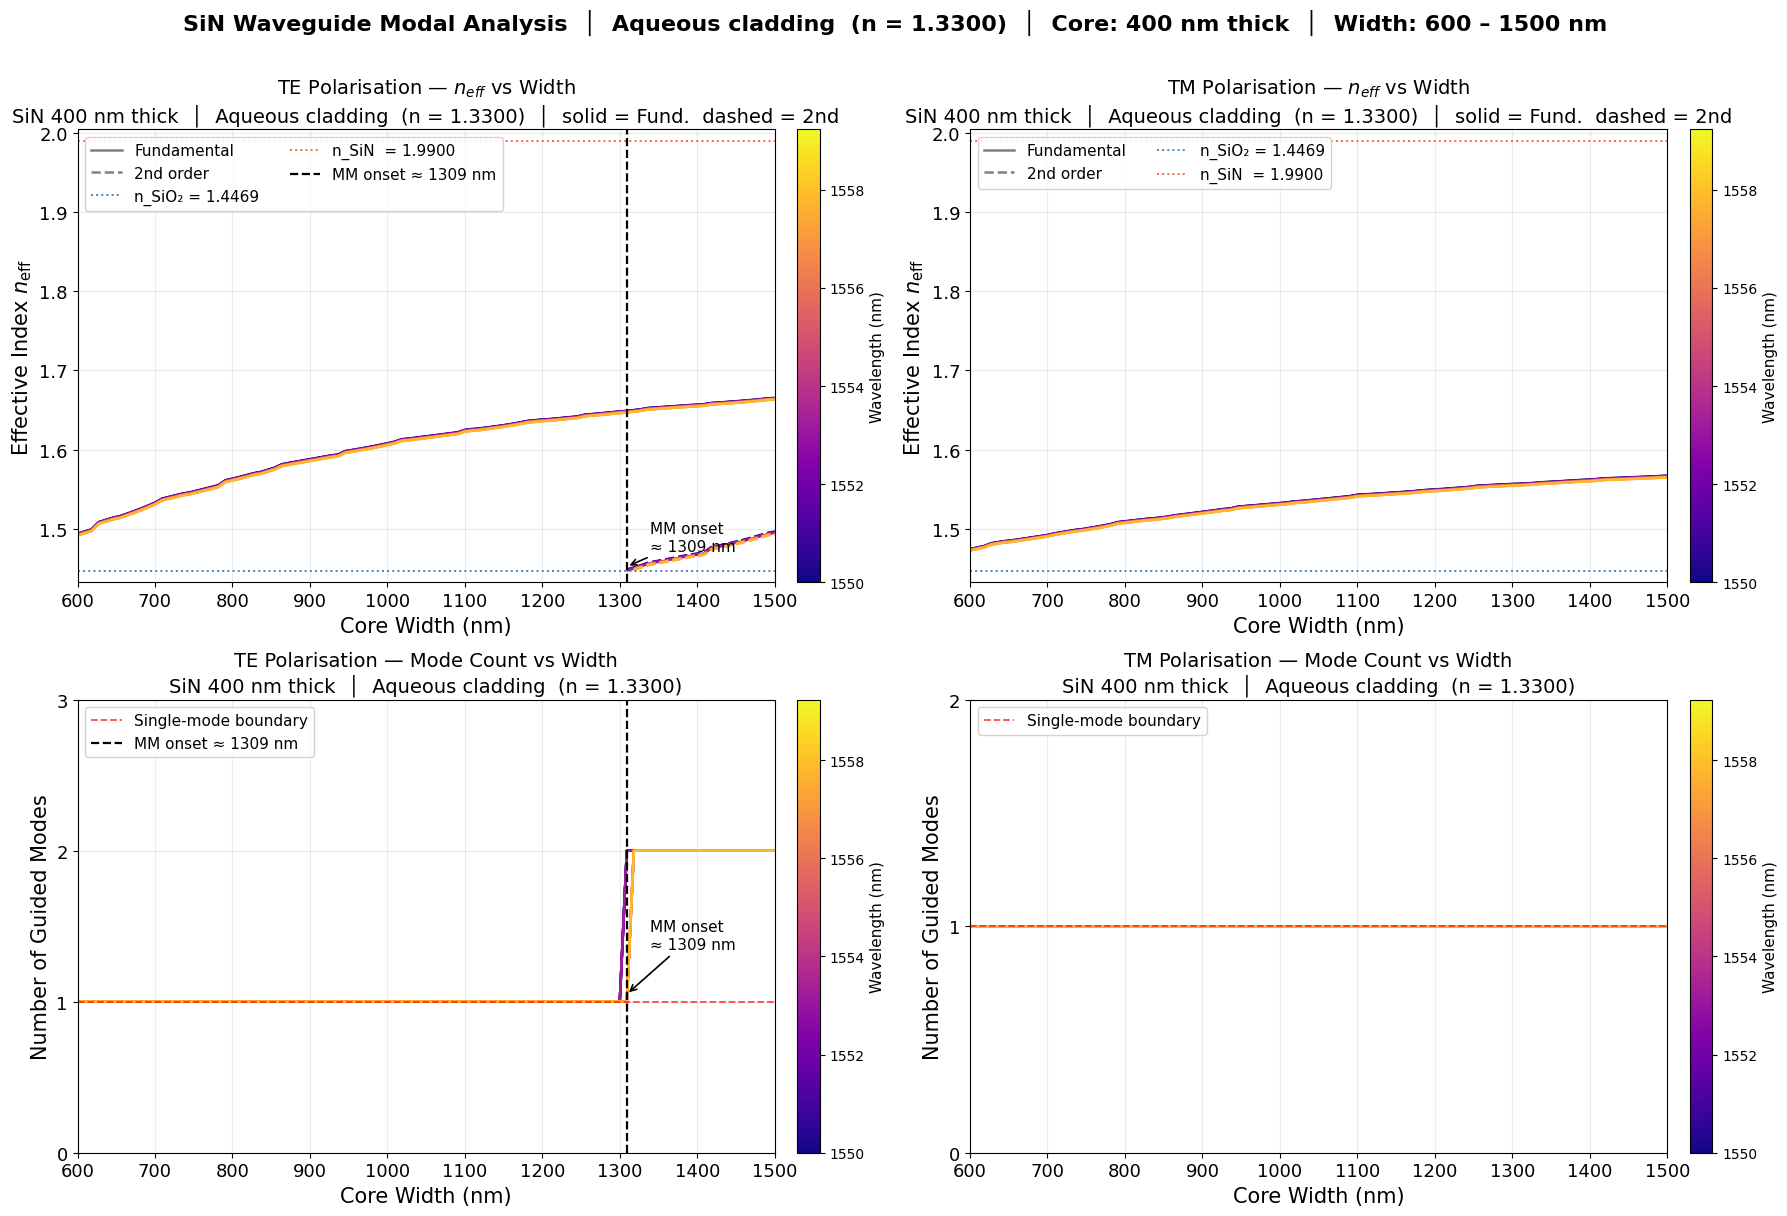


──────────────────────────────────────────────────────────────
  Plotting: Silica cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.pdf


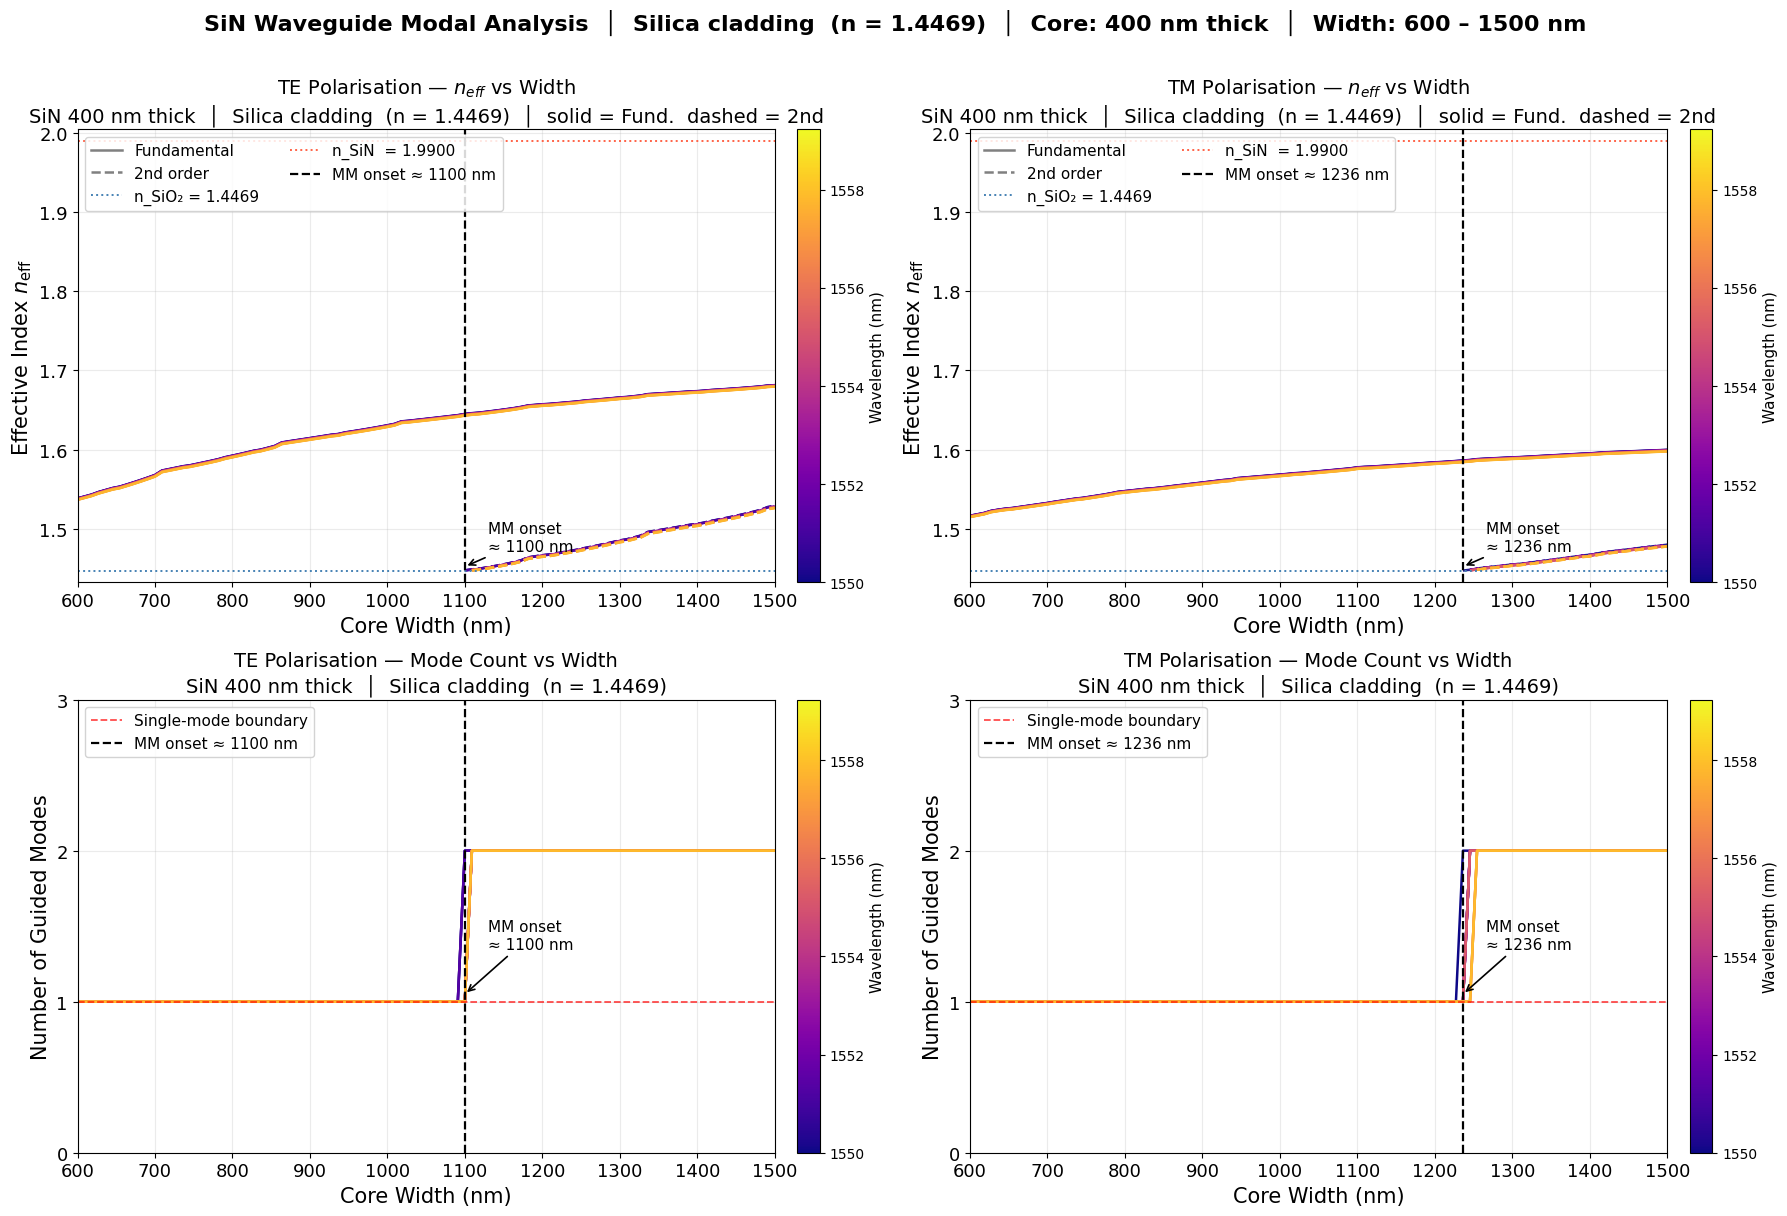

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Post-processing: TE/TM extraction for both cladding sweeps      ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–5 ALREADY EXECUTED.                                       ║
# ║  Reuses without redefining:                                                 ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, N_SIN_FIXED, N_SIO2_FIXED,               ║
# ║    N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2, CORE_THICKNESS_UM,            ║
# ║    DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,                              ║
# ║    neff_real, te_frac, neff_real_sio2, te_frac_sio2,                      ║
# ║    sweep_widths_um, sweep_wl_nm                                            ║
# ║                                                                             ║
# ║  New in this cell:                                                          ║
# ║    matplotlib imports, plotting style constants,                            ║
# ║    extract_pol_data(), find_mm_cutoff_nm(),                                ║
# ║    pol_aq / pol_sio2 dicts                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plotting style constants  ─ consistent with Tidy3D notebook
# ─────────────────────────────────────────────────────────────────────────────
TE_THRESHOLD    = 0.5               # te_frac > threshold → TE, else TM
MAX_POL_MODES   = 2                 # track up to 2 modes per polarization
PLASMA_RANGE    = (0.0, 0.85)       # crop plasma to avoid bright yellow tip
LINESTYLES      = ['-', '--']       # fund. = solid, 2nd order = dashed
FIG_SIZE_2X2    = (18, 12)
FONT_SUPTITLE   = 16
FONT_TITLE      = 14
FONT_AXLABEL    = 15
FONT_TICK       = 13
FONT_LEGEND     = 11
FONT_CBAR       = 11
FONT_ANNOT      = 11
LEGEND_ALPHA    = 0.85
GRID_ALPHA      = 0.25
SAVE_DPI        = 150


# ─────────────────────────────────────────────────────────────────────────────
# Helper 1:  extract_pol_data
# ─────────────────────────────────────────────────────────────────────────────
def extract_pol_data(neff_real_arr, te_frac_arr, n_guided_cutoff,
                     te_threshold=TE_THRESHOLD, max_modes=MAX_POL_MODES):
    """
    Separate raw FDE mode arrays into TE and TM sub-arrays.

    Modes are visited in Lumerical's natural order (highest neff first).
    A mode qualifies if:
        (a)  Re(neff) > n_guided_cutoff      (guided — above SiO₂ cutoff)
        (b)  te_frac > te_threshold           (TE)
             te_frac ≤ te_threshold           (TM)

    Parameters
    ----------
    neff_real_arr   : np.ndarray  [n_w, n_wl, n_modes]  Re(neff) from FDE
    te_frac_arr     : np.ndarray  [n_w, n_wl, n_modes]  TE polarization fraction
    n_guided_cutoff : float    minimum neff for a guided mode (= N_SIO2_FIXED)
    te_threshold    : float    default 0.5
    max_modes       : int      max modes per polarization to store (default 2)

    Returns
    -------
    dict:
        neff_TE  np.ndarray  [n_w, n_wl, max_modes]  TE neff (NaN = absent)
        neff_TM  np.ndarray  [n_w, n_wl, max_modes]  TM neff
        n_TE     np.ndarray  [n_w, n_wl]  int   guided TE mode count
        n_TM     np.ndarray  [n_w, n_wl]  int   guided TM mode count
    """
    n_w, n_wl, n_mod = neff_real_arr.shape

    neff_TE = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    neff_TM = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    n_TE    = np.zeros((n_w, n_wl), dtype=np.int32)
    n_TM    = np.zeros((n_w, n_wl), dtype=np.int32)

    for w_i in range(n_w):
        for wl_i in range(n_wl):
            te_cnt = tm_cnt = 0
            for m_i in range(n_mod):
                ne = neff_real_arr[w_i, wl_i, m_i]
                tf = te_frac_arr  [w_i, wl_i, m_i]

                if np.isnan(ne):
                    break                           # no more modes at this point

                if ne <= n_guided_cutoff:
                    continue                        # non-guided; skip

                if tf > te_threshold:               # TE mode
                    if te_cnt < max_modes:
                        neff_TE[w_i, wl_i, te_cnt] = ne
                    te_cnt += 1
                else:                               # TM mode
                    if tm_cnt < max_modes:
                        neff_TM[w_i, wl_i, tm_cnt] = ne
                    tm_cnt += 1

            n_TE[w_i, wl_i] = te_cnt
            n_TM[w_i, wl_i] = tm_cnt

    return dict(neff_TE=neff_TE, neff_TM=neff_TM, n_TE=n_TE, n_TM=n_TM)


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2:  find_mm_cutoff_nm
# ─────────────────────────────────────────────────────────────────────────────
def find_mm_cutoff_nm(n_pol_arr, sweep_widths_um):
    """
    Return the first waveguide width (nm) at which more than one guided mode
    exists for the given polarization across ANY wavelength in the sweep.

    Parameters
    ----------
    n_pol_arr      : [n_w, n_wl]  int   mode count per polarization
    sweep_widths_um: [n_w]        float  width array in µm

    Returns
    -------
    float (nm) if found, None otherwise.
    """
    for w_i in range(len(sweep_widths_um)):
        if np.any(n_pol_arr[w_i, :] > 1):
            return float(sweep_widths_um[w_i] * 1e3)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Extract polarization data for both sweeps
# n_guided_cutoff = N_SIO2_FIXED for both:
#   aqueous stack : SiO₂ is highest-index cladding → modes leak into SiO₂ first
#   silica  stack : both claddings are SiO₂         → same cutoff
# ─────────────────────────────────────────────────────────────────────────────
pol_aq   = extract_pol_data(neff_real,      te_frac,      N_SIO2_FIXED)
pol_sio2 = extract_pol_data(neff_real_sio2, te_frac_sio2, N_SIO2_FIXED)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 66)
print("  Post-processing summary — polarization-resolved mode analysis")
print(f"  Width : {sweep_widths_um[0]*1e3:.0f} → {sweep_widths_um[-1]*1e3:.0f} nm  "
      f"({len(sweep_widths_um)} pts)")
print(f"  λ     : {sweep_wl_nm[0]:.4f} → {sweep_wl_nm[-1]:.4f} nm  "
      f"({len(sweep_wl_nm)} pts,  Δλ = 10/13 nm)")
print("=" * 66)

for env_str, pd, n_uc in [
    (f"Aqueous  (n_upper = {N_UPPER_CLADDING})",    pol_aq,   N_UPPER_CLADDING),
    (f"Silica   (n_upper = {N_UPPER_CLADDING_SIO2:.4f})", pol_sio2, N_UPPER_CLADDING_SIO2),
]:
    c_TE = find_mm_cutoff_nm(pd["n_TE"], sweep_widths_um)
    c_TM = find_mm_cutoff_nm(pd["n_TM"], sweep_widths_um)

    print(f"\n  {env_str}")
    print(f"    TE  max modes = {int(pd['n_TE'].max())}  │  "
          + (f"MM cutoff ≈ {c_TE:.0f} nm" if c_TE else "single-mode across full sweep"))
    print(f"    TM  max modes = {int(pd['n_TM'].max())}  │  "
          + (f"MM cutoff ≈ {c_TM:.0f} nm" if c_TM else "single-mode across full sweep"))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Publication plots: 2 × (2×2 figure)                             ║
# ║                                                                             ║
# ║  Reuses: pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                  ║
# ║           N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2 ║
# ║           CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2    ║
# ║           all style constants from Cell 6                                   ║
# ║                                                                             ║
# ║  New: plot_modal_analysis()  (reusable for both environments)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def plot_modal_analysis(
    pol_data,
    sweep_widths_um,
    sweep_wl_nm,
    n_core,
    n_lower_clad,
    n_upper_clad,
    core_thickness_nm,
    env_label,
    save_stem=None,
):
    """
    Generate a 2×2 publication-quality figure for one cladding environment.

    Subplot layout:
        [0,0]  TE   effective index  vs core width   (all wavelengths)
        [0,1]  TM   effective index  vs core width
        [1,0]  TE   guided mode count vs core width
        [1,1]  TM   guided mode count vs core width

    Styling matches the Tidy3D reference notebook:
        plasma colormap for wavelength curves
        solid line = fundamental,  dashed = 2nd order
        steelblue dotted = n_SiO₂ reference
        tomato   dotted = n_SiN  reference
        black dashed vertical = MM onset
        colorbar for wavelength encoding (replaces 13-entry λ legend)

    Parameters
    ----------
    pol_data          : dict  from extract_pol_data
    sweep_widths_um   : [n_w]  µm
    sweep_wl_nm       : [n_wl] nm
    n_core            : float  N_SIN_FIXED
    n_lower_clad      : float  N_SIO2_FIXED
    n_upper_clad      : float  N_UPPER_CLADDING or N_UPPER_CLADDING_SIO2
    core_thickness_nm : float  waveguide height in nm
    env_label         : str    e.g. "Aqueous" or "Silica"
    save_stem         : str or Path or None
                        If given, saves  <save_stem>.png  and  <save_stem>.pdf

    Returns
    -------
    matplotlib.figure.Figure
    """
    neff_TE   = pol_data["neff_TE"]      # [n_w, n_wl, MAX_POL_MODES]
    neff_TM   = pol_data["neff_TM"]
    n_TE_arr  = pol_data["n_TE"]         # [n_w, n_wl]  int
    n_TM_arr  = pol_data["n_TM"]

    n_wl       = len(sweep_wl_nm)
    widths_nm  = sweep_widths_um * 1e3   # µm → nm for x-axis

    # Plasma colormap — one colour per wavelength, consistent with Tidy3D nb
    colors     = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], n_wl))

    # MM cutoff widths
    cutoff_TE_nm = find_mm_cutoff_nm(n_TE_arr, sweep_widths_um)
    cutoff_TM_nm = find_mm_cutoff_nm(n_TM_arr, sweep_widths_um)

    # ── Figure and axes ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

    # ── Shared colorbar setup (wavelength encoding) ───────────────────────────
    _cbar_norm = Normalize(vmin=sweep_wl_nm[0], vmax=sweep_wl_nm[-1])
    _cbar_sm   = cm.ScalarMappable(cmap='plasma', norm=_cbar_norm)
    _cbar_sm.set_array([])

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: neff subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _neff_ax(ax, neff_arr, cutoff_nm, pol_str):
        # ── Curve per (wavelength × mode order) ──────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            col = colors[wl_i]
            for m_i, ls in enumerate(LINESTYLES):
                y = neff_arr[:, wl_i, m_i]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    widths_nm, y,
                    color=col, linewidth=1.8, linestyle=ls,
                    alpha=0.9, label="_nolegend_",
                )

        # ── Reference lines (identical to Tidy3D notebook) ───────────────────
        ax.axhline(n_lower_clad, color='steelblue', linestyle=':', linewidth=1.4,
                   label=f"n_SiO₂ = {n_lower_clad:.4f}")
        ax.axhline(n_core,       color='tomato',    linestyle=':', linewidth=1.4,
                   label=f"n_SiN  = {n_core:.4f}")

        # ── MM cutoff annotation ──────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color='black', linestyle='--', linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, n_lower_clad + 0.005),
                xytext     = (cutoff_nm + 30, n_lower_clad + 0.025),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting (exact Tidy3D values) ─────────────────────────────
        ax.set_ylim(n_lower_clad - 0.015, n_core + 0.015)
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_xlabel("Core Width (nm)",                   fontsize=FONT_AXLABEL)
        ax.set_ylabel(r"Effective Index $n_\mathrm{eff}$", fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — $n_{{eff}}$ vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})  │  solid = Fund.  dashed = 2nd",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: line-style proxies + reference lines ──────────────────────
        proxy_handles = [
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="-",
                   label="Fundamental"),
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="--",
                   label="2nd order"),
            Line2D([0],[0], color="steelblue", linewidth=1.4, linestyle=":",
                   label=f"n_SiO₂ = {n_lower_clad:.4f}"),
            Line2D([0],[0], color="tomato",    linewidth=1.4, linestyle=":",
                   label=f"n_SiN  = {n_core:.4f}"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  ncol=2, loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: mode-count subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _count_ax(ax, n_pol, cutoff_nm, pol_str):
        # ── Curve per wavelength ──────────────────────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            ax.plot(
                widths_nm, n_pol[:, wl_i],
                color=colors[wl_i], linewidth=1.8,
                label="_nolegend_",
            )

        # ── Single-mode boundary ──────────────────────────────────────────────
        ax.axhline(1, color="red", linestyle="--", linewidth=1.3,
                   alpha=0.7, label="Single-mode boundary")

        # ── MM cutoff ─────────────────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color="black", linestyle="--", linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, 1.05),
                xytext     = (cutoff_nm + 30, 1.35),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting ───────────────────────────────────────────────────
        max_cnt = int(n_pol.max()) if n_pol.max() > 0 else 2
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_ylim(0, max_cnt + 1)
        ax.set_yticks(range(0, max_cnt + 2))
        ax.set_xlabel("Core Width (nm)",          fontsize=FONT_AXLABEL)
        ax.set_ylabel("Number of Guided Modes",   fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — Mode Count vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: reference lines only ──────────────────────────────────────
        proxy_handles = [
            Line2D([0],[0], color="red",   linewidth=1.3, linestyle="--",
                   alpha=0.7, label="Single-mode boundary"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ── Draw the four subplots ────────────────────────────────────────────────
    _neff_ax (axes[0, 0], neff_TE,  cutoff_TE_nm, "TE")
    _neff_ax (axes[0, 1], neff_TM,  cutoff_TM_nm, "TM")
    _count_ax(axes[1, 0], n_TE_arr, cutoff_TE_nm, "TE")
    _count_ax(axes[1, 1], n_TM_arr, cutoff_TM_nm, "TM")

    fig.suptitle(
        f"SiN Waveguide Modal Analysis  │  {env_label} cladding  "
        f"(n = {n_upper_clad:.4f})  │  "
        f"Core: {core_thickness_nm:.0f} nm thick  │  "
        f"Width: {widths_nm[0]:.0f} – {widths_nm[-1]:.0f} nm",
        fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save_stem is not None:
        for ext in (".png", ".pdf"):
            out = str(save_stem) + ext
            plt.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            print(f"  Saved → {out}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Execute: aqueous cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Aqueous cladding")
print("─" * 62)

fig_aq = plot_modal_analysis(
    pol_data          = pol_aq,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Aqueous",
    save_stem         = DATA_DIR / f"{VERSION_NAME}_modal_analysis_aqueous",
)

# ─────────────────────────────────────────────────────────────────────────────
# Execute: silica cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Silica cladding")
print("─" * 62)

fig_sio2 = plot_modal_analysis(
    pol_data          = pol_sio2,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING_SIO2,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Silica",
    save_stem         = DATA_DIR / f"{VERSION_NAME_SIO2}_modal_analysis_sio2clad",
)

12:21:42 │ INFO │ No ring sweep cache found — initialising group: ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
12:21:42 │ INFO │ Launching MODE session  (100 radii to compute) …


  Ring Resonator — Radius Sweep for FSR Matching
  Target FSR           : 10.00 nm
  Resonance wavelength : 1550.0 nm
  Waveguide width      : 1000 nm
  Waveguide height     : 400 nm
  n_core               : 1.99   (N_SIN_FIXED)
  n_lower_clad         : 1.4469  (N_SIO2_FIXED)
  n_upper_clad         : 1.33   (N_UPPER_CLADDING)
  Required ng·L        : 240.2500 µm
  ng stencil           : ±5.0 nm  (300 FDE solves if uncached)
  Radius sweep         : 18.0 – 20.0 µm  (100 pts)
  HDF5 group           : ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
  HDF5 file            : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

 Radius (µm)        neff          ng   TE frac     ng·L (µm)    Δ/target    source
----------------------------------------------------------------------------------
       18.00      1.6127      1.7218     1.000      194.7258     -18.95%       FDE
       18.02      1.6124      

12:22:21 │ INFO │   [  5/100]  R = 18.1 µm  |  0.13 radii/s  |  ETA 727 s


       18.08      1.6117      1.7339     1.000      196.9823     -18.01%       FDE
       18.10      1.6115      1.7412     1.000      198.0331     -17.57%       FDE
       18.12      1.6113      1.7519     0.999      199.4742     -16.97%       FDE
       18.14      1.6111      1.7670     0.999      201.4087     -16.17%       FDE
       18.16      1.6109      1.7864     0.999      203.8550     -15.15%       FDE


12:22:46 │ INFO │   [ 10/100]  R = 18.2 µm  |  0.16 radii/s  |  ETA 570 s


...

       19.90      1.6096      2.0219     0.994      252.7941      +5.22%       FDE
       19.92      1.6096      2.0219     0.994      253.0521      +5.33%       FDE
       19.94      1.6096      2.0219     0.994      253.3101      +5.44%       FDE
       19.96      1.6096      2.0219     0.994      253.5681      +5.54%       FDE
       19.98      1.6096      2.0219     0.994      253.8261      +5.65%       FDE


12:30:24 │ INFO │   [100/100]  R = 20.0 µm  |  0.19 radii/s  |  ETA 0 s


       20.00      1.6096      2.0219     0.994      254.0840      +5.76%       FDE


12:30:25 │ INFO │ MODE session closed  (100 new solves in 522.1 s, avg 1.74 s/FDE)
12:30:25 │ INFO │ HDF5 closed  →  D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5



  BEST MATCH
  Bend radius  R = 18.9293 µm
  Ring length  L = 118.9363 µm  (= 2π × R)
  neff           = 1.609820
  ng             = 2.020543
  ng·L achieved  = 240.3158 µm
  ng·L target    = 240.2500 µm
  Residual       = 0.06585 µm  (0.027 %)
  FSR predicted  = 9.9973 nm  (target 10.00 nm)


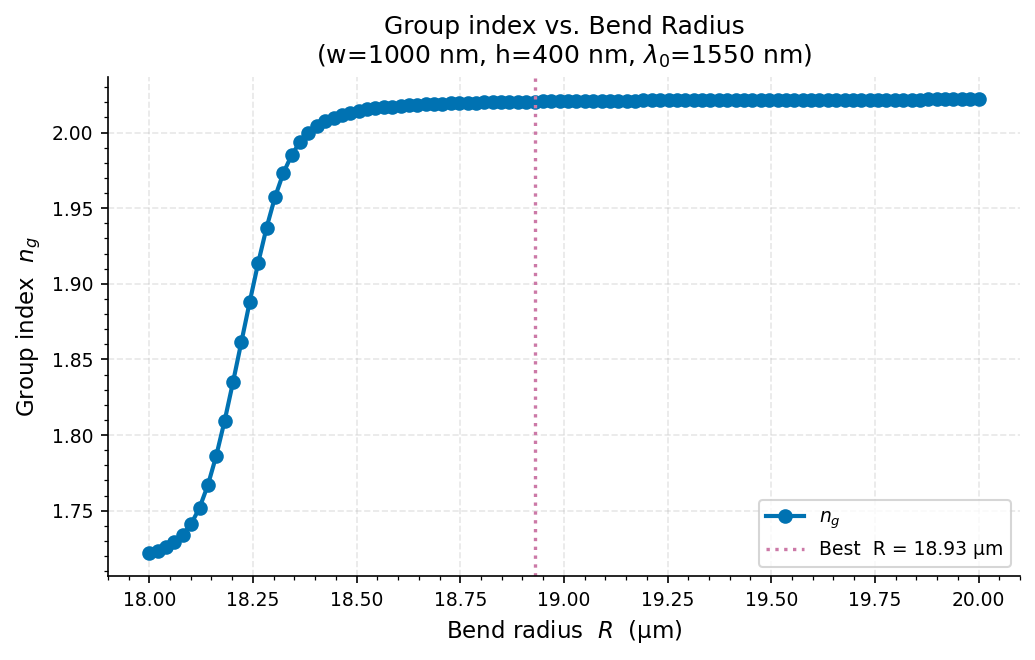

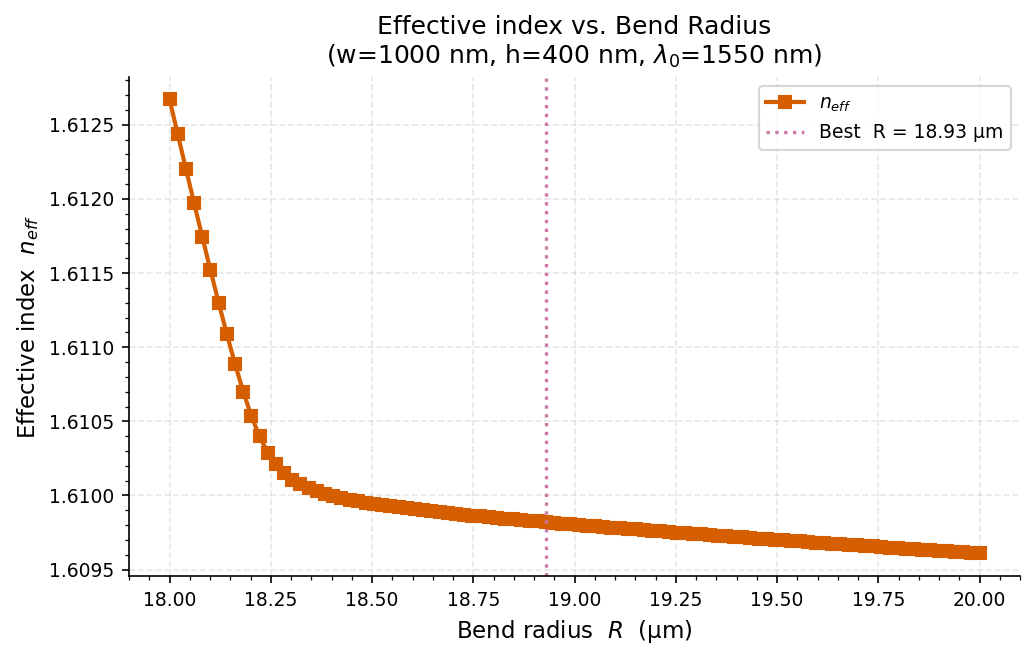

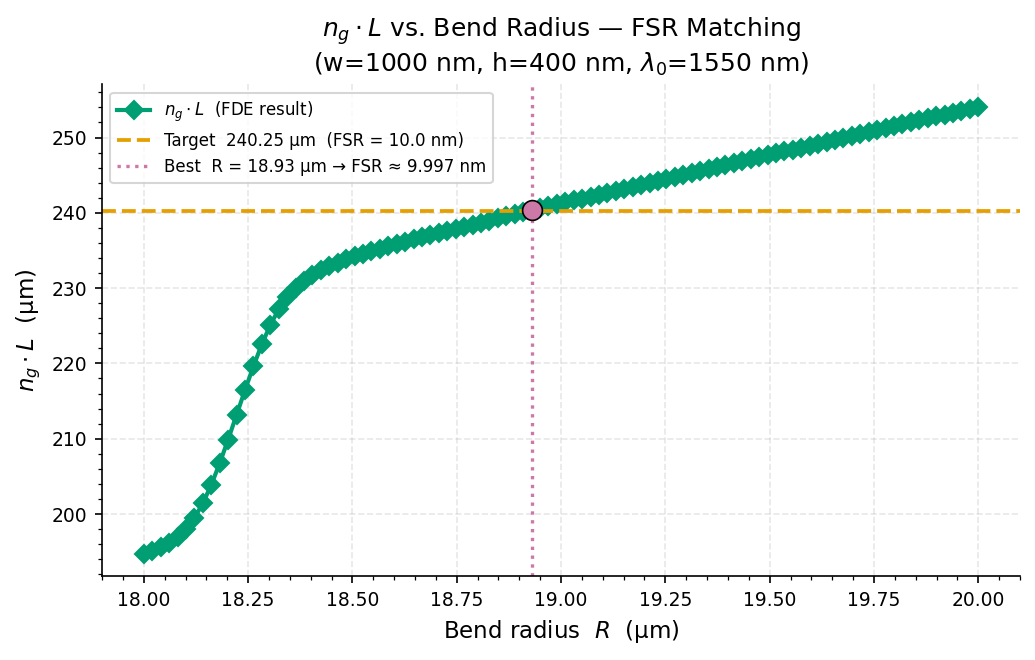


  Cached in : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
  HDF5 group: ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts

  Variables exported to the next cell:
    rr_best_R_um   = 18.9293   # µm
    rr_best_L_um   = 118.9363   # µm
    rr_best_neff   = 1.609820
    rr_best_ng     = 2.020543
    rr_FSR_pred_nm = 9.9973   # nm


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Ring Resonator Radius Sweep for FSR Matching                     ║
# ║           with HDF5 caching identical to Cells 1-3                         ║
# ║                                                                            ║
# ║  Requires from earlier cells (already in kernel scope):                    ║
# ║    lumapi, np, h5py, log, time, Path, datetime                             ║
# ║    DATA_DIR, HDF5_PATH, VERSION_NAME                                       ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, CORE_THICKNESS_UM         ║
# ║    SIM_Y_SPAN_UM, SIM_Z_BELOW_UM, SIM_Z_ABOVE_UM                          ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# RING DESIGN TARGETS  ← edit only these three lines
# ─────────────────────────────────────────────────────────────────────────────
RR_FSR_NM      = 10.0      # [nm]  target free spectral range
RR_LAM0_NM     = 1550.0    # [nm]  resonance wavelength
RR_WG_WIDTH_NM = 1000.0    # [nm]  waveguide width  (height = CORE_THICKNESS_UM)

# ─────────────────────────────────────────────────────────────────────────────
# RADIUS SWEEP RANGE
# ─────────────────────────────────────────────────────────────────────────────
RR_R_MIN_UM  = 18.0    # [µm]
RR_R_MAX_UM  = 20.0   # [µm]
RR_N_RADII   = 100

# ─────────────────────────────────────────────────────────────────────────────
# ng FINITE-DIFFERENCE STENCIL
#   ng = neff(λ₀) − λ₀ · [neff(λ₀+ΔΛ) − neff(λ₀−ΔΛ)] / (2·ΔΛ)
# ─────────────────────────────────────────────────────────────────────────────
_RR_DELTA_LAM_NM = 5.0   # [nm]  half-span for central difference

# ─────────────────────────────────────────────────────────────────────────────
# HDF5 STORAGE
#   Results are stored as a NEW GROUP inside the existing HDF5 file produced
#   by Cells 1-3 (HDF5_PATH / DATA_DIR already in scope).
#   Group key encodes the sweep parameters so different sweeps never collide.
#
#   Layout inside the existing .h5 file:
#
#   ring_radius_sweep/
#     <group_key>/                    ← one group per unique sweep config
#       metadata/
#         attrs:  fsr_nm, lam0_nm, wg_width_nm, wg_height_nm,
#                 r_min_um, r_max_um, n_radii, delta_lam_nm,
#                 n_SiN, n_SiO2, n_upper_clad,
#                 timestamp_start, timestamp_end
#         datasets: radii_um           [n_radii]
#                   lam_stencil_nm     [3]        (lo, centre, hi)
#       results/
#         neff       [n_radii]   float64  — at λ₀
#         ng         [n_radii]   float64  — central-difference group index
#         te_frac    [n_radii]   float64  — TE polarisation fraction at λ₀
#         ngL_um     [n_radii]   float64  — ng × 2πR  [µm]
#         neff_lo    [n_radii]   float64  — neff at λ₀−ΔΛ  (stencil raw data)
#         neff_hi    [n_radii]   float64  — neff at λ₀+ΔΛ
#       flags/
#         computed   [n_radii]   bool     — True once a radius row is done
# ─────────────────────────────────────────────────────────────────────────────

# ── Group key — uniquely identifies this sweep configuration ─────────────────
# Format:  rr_<fsr>nm_<lam0>nm_<width>nm_<Rmin>-<Rmax>um_<N>pts
# Example: rr_10nm_1550nm_1000nm_2.0-20.0um_19pts
_RR_GROUP_KEY = (
    f"rr_{RR_FSR_NM:.0f}nm_{RR_LAM0_NM:.0f}nm_"
    f"{RR_WG_WIDTH_NM:.0f}nm_"
    f"{RR_R_MIN_UM:.1f}-{RR_R_MAX_UM:.1f}um_{RR_N_RADII}pts"
)
_RR_HDF5_GROUP = f"ring_radius_sweep/{_RR_GROUP_KEY}"

# ─────────────────────────────────────────────────────────────────────────────
# DERIVED CONSTANTS  (do not edit)
# ─────────────────────────────────────────────────────────────────────────────
_lam0_m   = RR_LAM0_NM * 1e-9
_lam_lo_m = (RR_LAM0_NM - _RR_DELTA_LAM_NM) * 1e-9
_lam_hi_m = (RR_LAM0_NM + _RR_DELTA_LAM_NM) * 1e-9
_dlam_m   = 2.0 * _RR_DELTA_LAM_NM * 1e-9

_FSR_m    = RR_FSR_NM * 1e-9
_wg_w_m   = RR_WG_WIDTH_NM * 1e-9
_core_t_um = CORE_THICKNESS_UM

_target_ngL_m  = _lam0_m**2 / _FSR_m
_target_ngL_um = _target_ngL_m * 1e6

# Domain geometry — identical to _init_fde_geometry in Cell 2
_sim_y_span_um  = SIM_Y_SPAN_UM
_sim_z_below_um = SIM_Z_BELOW_UM
_sim_z_above_um = SIM_Z_ABOVE_UM
_sim_z_span_um  = _sim_z_below_um + _core_t_um + _sim_z_above_um
_half_t_um      = _core_t_um / 2.0
_sio2_z_ctr_um  = -(_half_t_um + _sim_z_below_um / 2.0)
_sio2_z_span_um = _sim_z_below_um
_sim_z_ctr_um   = (_sim_z_above_um - _sim_z_below_um) / 2.0

_radii_um = np.linspace(RR_R_MIN_UM, RR_R_MAX_UM, RR_N_RADII)
_radii_m  = _radii_um * 1e-6
_N        = RR_N_RADII

print("=" * 65)
print("  Ring Resonator — Radius Sweep for FSR Matching")
print("=" * 65)
print(f"  Target FSR           : {RR_FSR_NM:.2f} nm")
print(f"  Resonance wavelength : {RR_LAM0_NM:.1f} nm")
print(f"  Waveguide width      : {RR_WG_WIDTH_NM:.0f} nm")
print(f"  Waveguide height     : {_core_t_um*1e3:.0f} nm")
print(f"  n_core               : {N_SIN_FIXED}   (N_SIN_FIXED)")
print(f"  n_lower_clad         : {N_SIO2_FIXED}  (N_SIO2_FIXED)")
print(f"  n_upper_clad         : {N_UPPER_CLADDING}   (N_UPPER_CLADDING)")
print(f"  Required ng·L        : {_target_ngL_um:.4f} µm")
print(f"  ng stencil           : ±{_RR_DELTA_LAM_NM:.1f} nm  ({_N*3} FDE solves if uncached)")
print(f"  Radius sweep         : {RR_R_MIN_UM:.1f} – {RR_R_MAX_UM:.1f} µm  ({_N} pts)")
print(f"  HDF5 group           : {_RR_HDF5_GROUP}")
print(f"  HDF5 file            : {HDF5_PATH}")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — initialise the group for this sweep inside the existing file
# ─────────────────────────────────────────────────────────────────────────────
def _rr_init_hdf5(hf) -> None:
    """
    Create ring_radius_sweep/<group_key>/ inside an already-open h5py file
    opened in 'r+' or 'a' mode.  Pre-allocates all datasets with NaN / False.
    Mirrors the structure of _init_hdf5 from Cell 2 exactly.
    """
    g = hf.require_group(_RR_HDF5_GROUP)

    # ── metadata ─────────────────────────────────────────────────────────────
    mg = g.require_group("metadata")
    mg.attrs["fsr_nm"]         = RR_FSR_NM
    mg.attrs["lam0_nm"]        = RR_LAM0_NM
    mg.attrs["wg_width_nm"]    = RR_WG_WIDTH_NM
    mg.attrs["wg_height_nm"]   = _core_t_um * 1e3
    mg.attrs["r_min_um"]       = RR_R_MIN_UM
    mg.attrs["r_max_um"]       = RR_R_MAX_UM
    mg.attrs["n_radii"]        = _N
    mg.attrs["delta_lam_nm"]   = _RR_DELTA_LAM_NM
    mg.attrs["n_SiN"]          = N_SIN_FIXED
    mg.attrs["n_SiO2"]         = N_SIO2_FIXED
    mg.attrs["n_upper_clad"]   = N_UPPER_CLADDING
    mg.attrs["version_name"]   = VERSION_NAME
    mg.attrs["timestamp_start"] = datetime.now().isoformat()

    # axis coordinate arrays
    if "radii_um" not in mg:
        mg.create_dataset("radii_um",       data=_radii_um)
    if "lam_stencil_nm" not in mg:
        mg.create_dataset("lam_stencil_nm",
                          data=np.array([RR_LAM0_NM - _RR_DELTA_LAM_NM,
                                         RR_LAM0_NM,
                                         RR_LAM0_NM + _RR_DELTA_LAM_NM]))

    # ── results — NaN-initialised, chunked per radius row ────────────────────
    rg = g.require_group("results")
    _nan = np.full(_N, np.nan, dtype=np.float64)
    for ds_name in ("neff", "ng", "te_frac", "ngL_um", "neff_lo", "neff_hi"):
        if ds_name not in rg:
            rg.create_dataset(ds_name, data=_nan.copy(), chunks=(_N,))

    # ── progress flag ─────────────────────────────────────────────────────────
    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed",
                          data=np.zeros(_N, dtype=bool),
                          chunks=(_N,))


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — load existing cache into memory arrays
# ─────────────────────────────────────────────────────────────────────────────
def _rr_load_cache(hf,
                   neff_arr, ng_arr, te_arr,
                   ngL_arr, neff_lo_arr, neff_hi_arr,
                   computed) -> int:
    """
    Read ring_radius_sweep/<group_key>/ from an open h5py file into the
    pre-allocated in-memory arrays.  Returns number of cached points.
    All arrays are modified in-place.
    """
    g  = hf[_RR_HDF5_GROUP]
    rg = g["results"]
    fg = g["flags"]

    neff_arr[:]    = rg["neff"][:]
    ng_arr[:]      = rg["ng"][:]
    te_arr[:]      = rg["te_frac"][:]
    ngL_arr[:]     = rg["ngL_um"][:] * 1e-6   # stored in µm, keep in m here
    neff_lo_arr[:] = rg["neff_lo"][:]
    neff_hi_arr[:] = rg["neff_hi"][:]
    computed[:]    = fg["computed"][:]

    return int(computed.sum())


# ─────────────────────────────────────────────────────────────────────────────
# FDE HELPERS  (unchanged from working version)
# ─────────────────────────────────────────────────────────────────────────────
def _rr_build_fde(mode, radius_m: float, wavelength_m: float) -> None:
    """Build bent waveguide cross-section + FDE solver for one (R, λ) point."""
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _sim_z_ctr_um  * 1e-6)
    m.set("y span",                _sim_y_span_um * 1e-6)
    m.set("z span",                _sim_z_span_um * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", N_MODES_REQUEST)
    m.set("mesh cells y",          MESH_CELLS_Y)
    m.set("mesh cells z",          MESH_CELLS_Z)
    m.set("bent waveguide",        1)
    m.set("bend radius",           radius_m)
    m.set("bend orientation",      0)

    m.addrect()
    m.set("name",    "RR_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um * 1e-6)
    m.set("z",       _sim_z_ctr_um  * 1e-6)
    m.set("z span",  _sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)

    m.addrect()
    m.set("name",    "RR_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um  * 1e-6)
    m.set("z",       _sio2_z_ctr_um * 1e-6)
    m.set("z span",  _sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    m.addrect()
    m.set("name",    "RR_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _wg_w_m)
    m.set("z",       0.0);  m.set("z span", _core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


def _rr_solve_neff(mode, radius_m: float, wavelength_m: float):
    """Single FDE solve → (Re(neff), TE fraction) for mode 1."""
    _rr_build_fde(mode, radius_m, wavelength_m)
    mode.run()
    mode.findmodes()
    raw_neff = mode.getdata("FDE::data::mode1", "neff")
    raw_te   = mode.getdata("FDE::data::mode1", "TE polarization fraction")
    neff_c   = complex(np.asarray(raw_neff).flat[0])
    te_v     = float(np.asarray(raw_te).flat[0])
    return neff_c.real, te_v


def _rr_neff_ng(mode, radius_m: float):
    """
    Three-point central-difference ng at lam0 for a given bend radius.
    Returns (neff_at_lam0, ng, te_frac, neff_lo, neff_hi).
    """
    neff_lo, _    = _rr_solve_neff(mode, radius_m, _lam_lo_m)
    neff_0,  te_v = _rr_solve_neff(mode, radius_m, _lam0_m)
    neff_hi, _    = _rr_solve_neff(mode, radius_m, _lam_hi_m)
    dneff_dlam    = (neff_hi - neff_lo) / _dlam_m
    ng            = neff_0 - _lam0_m * dneff_dlam
    return neff_0, ng, te_v, neff_lo, neff_hi


# ─────────────────────────────────────────────────────────────────────────────
# IN-MEMORY ARRAYS  (NaN-initialised; overwritten by cache or FDE)
# ─────────────────────────────────────────────────────────────────────────────
_neff_arr    = np.full(_N, np.nan)
_ng_arr      = np.full(_N, np.nan)
_te_arr      = np.full(_N, np.nan)
_ngL_arr     = np.full(_N, np.nan)   # [m]
_neff_lo_arr = np.full(_N, np.nan)
_neff_hi_arr = np.full(_N, np.nan)
_computed    = np.zeros(_N, dtype=bool)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — HDF5 CACHE CHECK
#   Open the existing file in append mode ('a').
#   If our group is already there, load what is cached.
#   If the group is missing, create it now.
#   Either way the file stays open for the sweep loop below.
# ─────────────────────────────────────────────────────────────────────────────
_hf = h5py.File(HDF5_PATH, "a")   # 'a' = read/write, create if missing

if _RR_HDF5_GROUP in _hf:
    log.info(f"Ring sweep cache found → {_RR_HDF5_GROUP}")
    _n_cached = _rr_load_cache(
        _hf,
        _neff_arr, _ng_arr, _te_arr,
        _ngL_arr, _neff_lo_arr, _neff_hi_arr,
        _computed,
    )
    _remaining = _N - _n_cached
    log.info(f"Cached: {_n_cached}/{_N}  |  Remaining: {_remaining}")
    if _remaining == 0:
        log.info("All radii already computed — skipping FDE entirely.")
else:
    log.info(f"No ring sweep cache found — initialising group: {_RR_HDF5_GROUP}")
    _rr_init_hdf5(_hf)
    _hf.flush()
    _n_cached  = 0
    _remaining = _N


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — FDE SWEEP  (skipped entirely when all radii are cached)
# ─────────────────────────────────────────────────────────────────────────────
_hdr = (f"{'Radius (µm)':>12}  {'neff':>10}  {'ng':>10}  "
        f"{'TE frac':>8}  {'ng·L (µm)':>12}  {'Δ/target':>10}  {'source':>8}")
print(f"\n{_hdr}")
print("-" * len(_hdr))

# Print already-cached rows first so the table is complete
for _i in range(_N):
    if _computed[_i]:
        _ngL_m = _ngL_arr[_i]
        _delta  = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
        print(f"  {_radii_um[_i]:>10.2f}  {_neff_arr[_i]:>10.4f}  "
              f"{_ng_arr[_i]:>10.4f}  {_te_arr[_i]:>8.3f}  "
              f"{_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  {'cache':>8}")

if _remaining > 0:
    _runs_done = 0
    _t0 = time.time()
    log.info(f"Launching MODE session  ({_remaining} radii to compute) …")
    _rr_mode = lumapi.MODE(hide=False)

    try:
        for _i, (_R_um, _R_m) in enumerate(zip(_radii_um, _radii_m)):
            if _computed[_i]:
                continue   # already in cache — skip

            try:
                _neff_v, _ng_v, _te_v, _nlo, _nhi = _rr_neff_ng(_rr_mode, _R_m)
            except Exception as _exc:
                log.warning(f"  R = {_R_um:6.2f} µm  FAILED: {_exc}")
                # Mark as done with NaN so a re-run doesn't retry a broken radius
                _computed[_i] = True
                _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
                _hf.flush()
                continue

            _L_m   = 2.0 * np.pi * _R_m
            _ngL_m = _ng_v * _L_m

            # ── store in memory ───────────────────────────────────────────────
            _neff_arr[_i]    = _neff_v
            _ng_arr[_i]      = _ng_v
            _te_arr[_i]      = _te_v
            _ngL_arr[_i]     = _ngL_m
            _neff_lo_arr[_i] = _nlo
            _neff_hi_arr[_i] = _nhi
            _computed[_i]    = True

            # ── write to HDF5 immediately + flush (fault-safe) ────────────────
            _rg = _hf[f"{_RR_HDF5_GROUP}/results"]
            _rg["neff"]   [_i] = _neff_v
            _rg["ng"]     [_i] = _ng_v
            _rg["te_frac"][_i] = _te_v
            _rg["ngL_um"] [_i] = _ngL_m * 1e6        # stored in µm
            _rg["neff_lo"][_i] = _nlo
            _rg["neff_hi"][_i] = _nhi
            _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
            _hf.flush()

            _runs_done += 1
            _delta = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
            print(f"  {_R_um:>10.2f}  {_neff_v:>10.4f}  {_ng_v:>10.4f}  "
                  f"{_te_v:>8.3f}  {_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  "
                  f"{'FDE':>8}")

            # progress every 5 new solves
            if _runs_done % 5 == 0 or _runs_done == _remaining:
                _elapsed = time.time() - _t0
                _rate    = _runs_done / _elapsed if _elapsed > 0 else 1e-9
                _eta     = (_remaining - _runs_done) / _rate
                log.info(f"  [{_runs_done:3d}/{_remaining}]  "
                         f"R = {_R_um:.1f} µm  |  "
                         f"{_rate:.2f} radii/s  |  ETA {_eta:.0f} s")

    finally:
        _rr_mode.close()
        _elapsed_total = time.time() - _t0
        log.info(f"MODE session closed  "
                 f"({_runs_done} new solves in {_elapsed_total:.1f} s, "
                 f"avg {_elapsed_total/max(_runs_done*3,1):.2f} s/FDE)")

# ── close-out metadata ────────────────────────────────────────────────────────
_hf[_RR_HDF5_GROUP]["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
_hf[_RR_HDF5_GROUP]["metadata"].attrs["runs_completed"] = int(_computed.sum())
_hf.flush()
_hf.close()
log.info(f"HDF5 closed  →  {HDF5_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — FIND BEST MATCH  (uses in-memory arrays, already complete)
# ─────────────────────────────────────────────────────────────────────────────
_valid = ~np.isnan(_ng_arr)

if not np.any(_valid):
    raise RuntimeError(
        "All radius sweep FDE runs failed.  "
        "Check the WARNING lines above for the specific error."
    )

_R_v    = _radii_um[_valid]
_neff_v = _neff_arr[_valid]
_ng_v   = _ng_arr[_valid]
_te_v   = _te_arr[_valid]
_ngL_v  = _ngL_arr[_valid]   # [m]

_dist = np.abs(_ngL_v - _target_ngL_m)
_bi   = int(np.argmin(_dist))

# ── exported to downstream cells ─────────────────────────────────────────────
rr_best_R_um   = _R_v[_bi]
rr_best_L_um   = 2.0 * np.pi * rr_best_R_um
rr_best_neff   = _neff_v[_bi]
rr_best_ng     = _ng_v[_bi]
rr_best_ngL_um = _ngL_v[_bi] * 1e6
rr_FSR_pred_nm = (_lam0_m**2 / _ngL_v[_bi]) * 1e9

print("\n" + "=" * 65)
print("  BEST MATCH")
print("=" * 65)
print(f"  Bend radius  R = {rr_best_R_um:.4f} µm")
print(f"  Ring length  L = {rr_best_L_um:.4f} µm  (= 2π × R)")
print(f"  neff           = {rr_best_neff:.6f}")
print(f"  ng             = {rr_best_ng:.6f}")
print(f"  ng·L achieved  = {rr_best_ngL_um:.4f} µm")
print(f"  ng·L target    = {_target_ngL_um:.4f} µm")
print(f"  Residual       = {_dist[_bi]*1e6:.5f} µm  "
      f"({_dist[_bi]/_target_ngL_m*100:.3f} %)")
print(f"  FSR predicted  = {rr_FSR_pred_nm:.4f} nm  (target {RR_FSR_NM:.2f} nm)")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   2.0,
    "lines.markersize":  6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

_C_NG   = "#0072B2"
_C_NEFF = "#D55E00"
_C_NGL  = "#009E73"
_C_BEST = "#CC79A7"
_C_TGT  = "#E69F00"

_suffix = (f"w={RR_WG_WIDTH_NM:.0f} nm, h={_core_t_um*1e3:.0f} nm, "
           f"$\\lambda_0$={RR_LAM0_NM:.0f} nm")

# ── Figure 1 — ng vs radius ──────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(_R_v, _ng_v, "o-", color=_C_NG, label="$n_g$")
ax1.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax1.set_xlabel("Bend radius  $R$  (µm)")
ax1.set_ylabel("Group index  $n_g$")
ax1.set_title(f"Group index vs. Bend Radius\n({_suffix})")
ax1.legend()
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig1.tight_layout();  plt.show()

# ── Figure 2 — neff vs radius ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(_R_v, _neff_v, "s-", color=_C_NEFF, label="$n_{eff}$")
ax2.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax2.set_xlabel("Bend radius  $R$  (µm)")
ax2.set_ylabel("Effective index  $n_{eff}$")
ax2.set_title(f"Effective index vs. Bend Radius\n({_suffix})")
ax2.legend()
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig2.tight_layout();  plt.show()

# ── Figure 3 — ng·L vs radius with target line ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
ax3.plot(_R_v, _ngL_v * 1e6, "D-", color=_C_NGL,
         label="$n_g \\cdot L$  (FDE result)")
ax3.axhline(_target_ngL_um, color=_C_TGT, ls="--", lw=1.8,
            label=f"Target  {_target_ngL_um:.2f} µm  (FSR = {RR_FSR_NM:.1f} nm)")
ax3.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm → FSR ≈ {rr_FSR_pred_nm:.3f} nm")
ax3.scatter([rr_best_R_um], [rr_best_ngL_um],
            s=90, zorder=5, color=_C_BEST, edgecolors="k", linewidths=0.8)
ax3.set_xlabel("Bend radius  $R$  (µm)")
ax3.set_ylabel("$n_g \\cdot L$  (µm)")
ax3.set_title(f"$n_g \\cdot L$ vs. Bend Radius — FSR Matching\n({_suffix})")
ax3.legend(fontsize=8)
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig3.tight_layout();  plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  Cached in : {HDF5_PATH}")
print(f"  HDF5 group: {_RR_HDF5_GROUP}")
print(f"\n  Variables exported to the next cell:")
print(f"    rr_best_R_um   = {rr_best_R_um:.4f}   # µm")
print(f"    rr_best_L_um   = {rr_best_L_um:.4f}   # µm")
print(f"    rr_best_neff   = {rr_best_neff:.6f}")
print(f"    rr_best_ng     = {rr_best_ng:.6f}")
print(f"    rr_FSR_pred_nm = {rr_FSR_pred_nm:.4f}   # nm")

12:30:26 │ INFO │ Straight ng extraction │ target width = 1000 nm  → closest sweep index = 44  (1000.00 nm)
12:30:26 │ INFO │ ng_straight (linear fit)  = 2.023027  |  ng_straight (2-pt check)  = 2.023027  |  neff @ λ₀ = 1.607950
12:30:26 │ INFO │ Best radius  R = 18.9293 µm  →  m = 124
12:30:26 │ INFO │ Phase-matched radius  R_pm = 19.0021 µm  (converged in 3 iterations,  λ_res = 1550.000000 nm,  residual = 0.0000 pm)



══════════════════════════════════════════════════════════════════════════════════
  RING RESONATOR DESIGN SUMMARY  —  Phase Matching Correction
══════════════════════════════════════════════════════════════════════════════════
  Platform  : SiN  400 nm × 1000 nm  │  λ₀ = 1550.0 nm  │  Target FSR = 10.0 nm
──────────────────────────────────────────────────────────────────────────────────

  GROUP INDEX COMPARISON
  Source                                            neff          ng     dneff/dλ [1/µm]
  ──────────────────────────────────────────────────────────────────────────────
  Straight FDE (aqueous, linear fit)            1.607950    2.023027           -0.267791
  Straight FDE (2-point cross-check)            1.607951    2.023027                   —
  Bent FDE @ R = 18.9293 µm (FSR-matched)       1.609820    2.020543                   —
  Bent FDE @ R_pm = 19.0021 µm (phase-matched)    1.609803    2.020543                   —

  Δng (bend vs straight) = -0.002483  (-0.123 %)   ← 

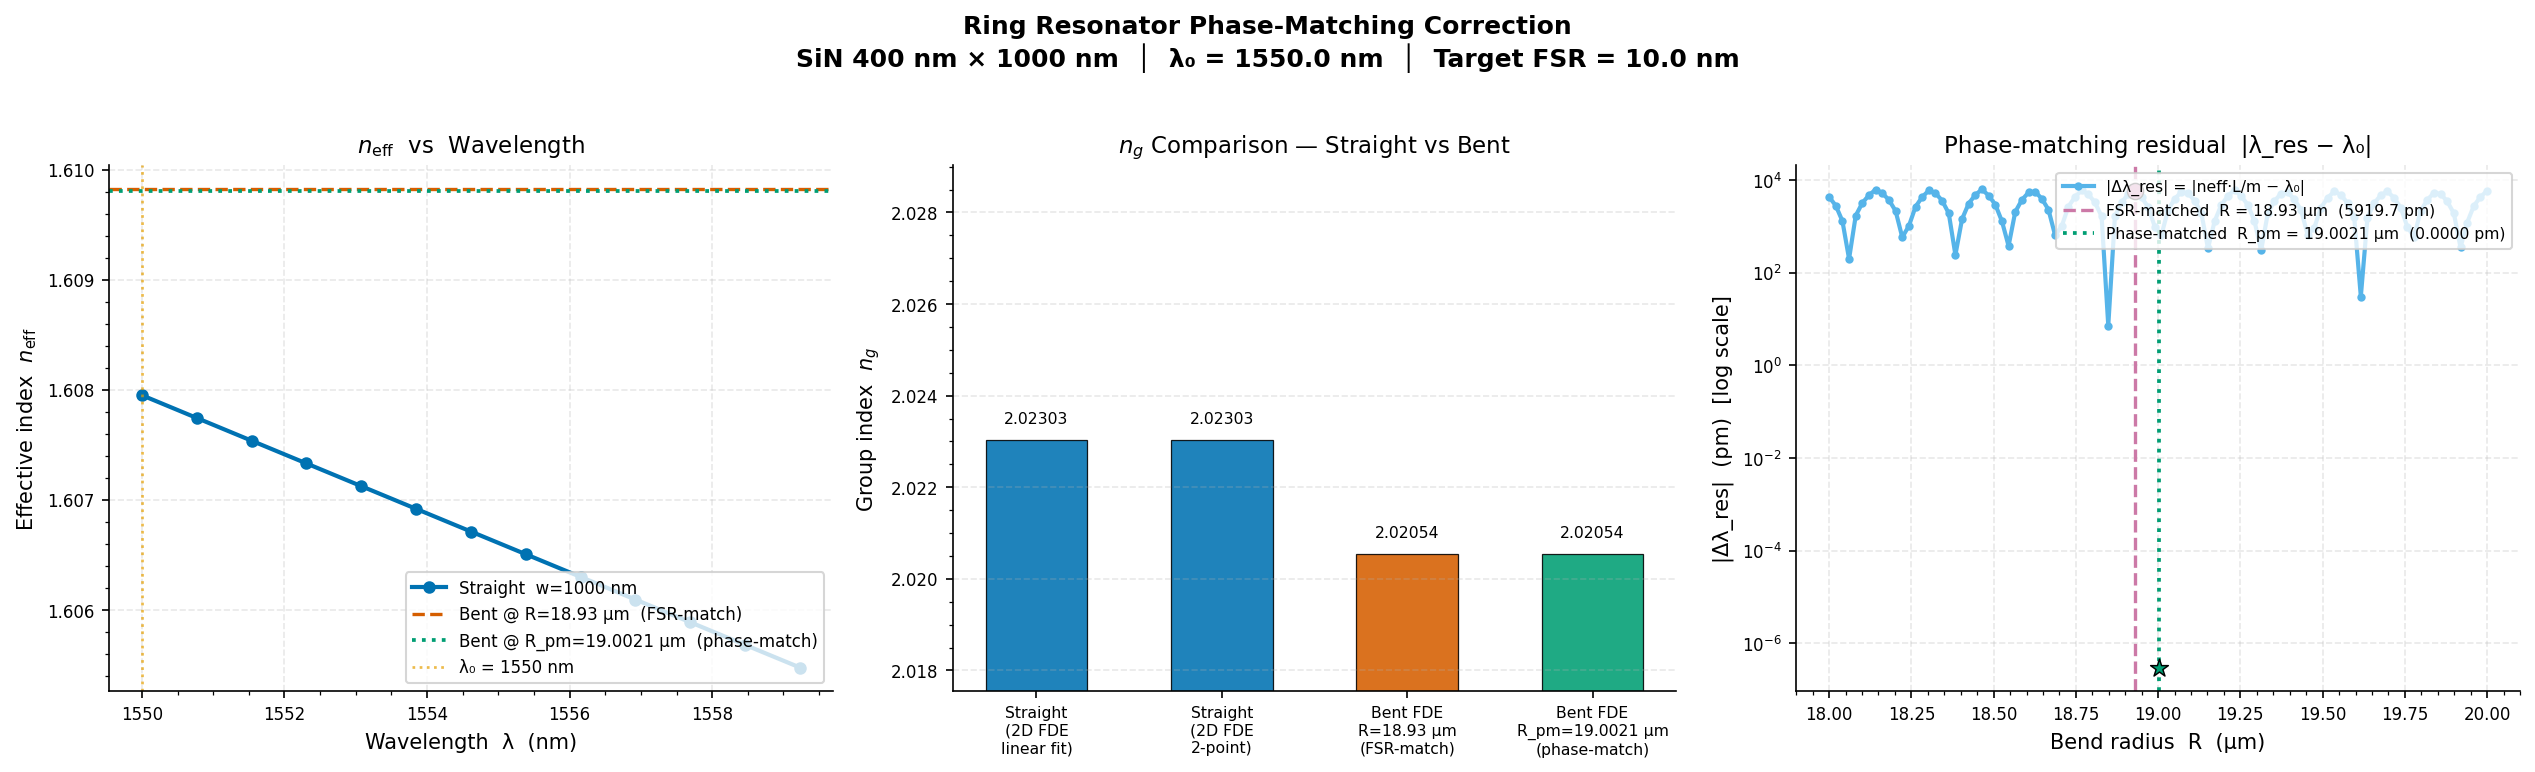

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Phase-matching correction + straight-waveguide ng comparison      ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                      ║
# ║    np, h5py, log, Path, datetime                                             ║
# ║    DATA_DIR, HDF5_PATH, VERSION_NAME                                         ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, CORE_THICKNESS_UM           ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, SWEEP_WL_UM                                ║
# ║    neff_real, te_frac           (from Cell 3 — straight aqueous sweep)       ║
# ║    RR_WG_WIDTH_NM, RR_LAM0_NM, RR_FSR_NM, _RR_DELTA_LAM_NM                 ║
# ║    rr_best_R_um, rr_best_L_um, rr_best_neff, rr_best_ng, rr_FSR_pred_nm     ║
# ║    _lam0_m, _target_ngL_m, _target_ngL_um                                   ║
# ║    _neff_arr, _ng_arr, _te_arr, _ngL_arr, _radii_um, _radii_m, _computed    ║
# ║                                                                              ║
# ║  What this cell does:                                                        ║
# ║    A) Extracts ng_straight from the existing straight FDE sweep (no new      ║
# ║       Lumerical call) using a central-difference across the 13-point λ sweep ║
# ║       at the chosen waveguide width (1000 nm).                               ║
# ║    B) Computes the resonance order m that minimises |m·λ₀ − neff·2πR| for   ║
# ║       every radius in the sweep array, then selects the global minimum.      ║
# ║    C) For the best radius found in Cell 8 (rr_best_R_um) calculates the      ║
# ║       exact phase-matched radius R_pm such that m·λ₀ = neff_bend·2π·R_pm.   ║
# ║    D) Iterates R_pm to self-consistency (neff changes with R at fixed width) ║
# ║       using the bent neff array from Cell 8 via linear interpolation.        ║
# ║    E) Prints a side-by-side comparison table and saves a 3-panel figure.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d   # already in scipy which is standard

# ─────────────────────────────────────────────────────────────────────────────
# SECTION A — ng from STRAIGHT waveguide sweep (no new FDE required)
#
#   The straight FDE sweep (Cells 1–3) produced:
#       neff_real[w_idx, wl_idx, mode_idx]   — shape (100, 13, 6)
#       SWEEP_WIDTHS_UM                       — 100 values, 600→1500 nm
#       SWEEP_WL_NM                           — 13 values, 1550.0→1559.23 nm
#
#   Strategy:
#     1. Find the width index for RR_WG_WIDTH_NM (1000 nm).
#     2. Use the full 13-point λ array as a finite-difference stencil and fit
#        a linear polynomial to neff(λ) — this gives dn_eff/dλ robustly.
#     3. Evaluate ng_straight = neff(λ₀) − λ₀ · dneff/dλ  at λ₀ = 1550 nm.
#        (Eq. 10 from Bogaerts et al. 2012)
#     4. Cross-check with the ±Δλ two-point formula for consistency.
# ─────────────────────────────────────────────────────────────────────────────

# ── A1: find width index for the ring waveguide width ────────────────────────
_rr_w_um  = RR_WG_WIDTH_NM * 1e-3              # 1.000 µm
_w_diffs  = np.abs(SWEEP_WIDTHS_UM - _rr_w_um)
_w_idx    = int(np.argmin(_w_diffs))
_w_actual_nm = SWEEP_WIDTHS_UM[_w_idx] * 1e3

log.info(
    f"Straight ng extraction │ target width = {RR_WG_WIDTH_NM:.0f} nm  "
    f"→ closest sweep index = {_w_idx}  "
    f"({_w_actual_nm:.2f} nm)"
)

# ── A2: extract neff(λ) for fundamental TE mode at chosen width ──────────────
# Mode 0 is always the fundamental (highest neff).  The te_frac check is a
# safety guard — if te_frac < 0.5 at this width the mode is TM.
_neff_vs_wl = neff_real[_w_idx, :, 0].copy()   # shape (13,)
_te_vs_wl   = te_frac  [_w_idx, :, 0].copy()

_te_mean = float(np.nanmean(_te_vs_wl))
if _te_mean < 0.5:
    log.warning(
        f"Mode 0 at w={_w_actual_nm:.0f} nm appears TM (mean TE frac={_te_mean:.3f}). "
        "Switching to mode index 1."
    )
    _neff_vs_wl = neff_real[_w_idx, :, 1].copy()
    _te_vs_wl   = te_frac  [_w_idx, :, 1].copy()

# ── A3: linear fit to neff(λ) → dn_eff/dλ ────────────────────────────────────
# Using wavelength in metres for dimensional consistency with Bogaerts Eq. 10.
_wl_m_arr = SWEEP_WL_NM * 1e-9              # shape (13,)   [m]
_lam0_idx = int(np.argmin(np.abs(SWEEP_WL_NM - RR_LAM0_NM)))   # index of λ₀

# Only use non-NaN points
_valid_wl  = ~np.isnan(_neff_vs_wl)
_poly_coeffs = np.polyfit(
    _wl_m_arr[_valid_wl],
    _neff_vs_wl[_valid_wl],
    deg=1,                  # linear: neff ≈ c0 + c1·λ
)
_dneff_dlam_straight = _poly_coeffs[0]          # c1  [1/m]

# neff at λ₀ from the fit (more stable than raw array value)
_neff_straight_lam0  = float(np.polyval(_poly_coeffs, _lam0_m))

# ng_straight  =  neff(λ₀) − λ₀ · dneff/dλ            (Bogaerts Eq. 10)
ng_straight = _neff_straight_lam0 - _lam0_m * _dneff_dlam_straight

# ── A4: two-point cross-check using first and last wavelength ────────────────
_neff_lo_str = _neff_vs_wl[0]    # λ = 1550.000 nm
_neff_hi_str = _neff_vs_wl[-1]   # λ = 1559.231 nm
_dlam_str_m  = (_wl_m_arr[-1] - _wl_m_arr[0])
_dneff_2pt   = (_neff_hi_str - _neff_lo_str) / _dlam_str_m
_ng_straight_2pt = _neff_vs_wl[_lam0_idx] - _lam0_m * _dneff_2pt

log.info(
    f"ng_straight (linear fit)  = {ng_straight:.6f}  |  "
    f"ng_straight (2-pt check)  = {_ng_straight_2pt:.6f}  |  "
    f"neff @ λ₀ = {_neff_straight_lam0:.6f}"
)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION B — resonance order m and phase-matching residual for every radius
#
#   Resonance condition (Bogaerts Eq. 3):
#       λ_res = neff · L / m     →     m = neff · L / λ₀   (continuous)
#   Phase-matched integer order:
#       m_int = round(neff · 2π·R / λ₀)
#   Residual:
#       δλ_res = (neff · 2π·R / m_int) − λ₀        [nm]
#
#   NOTE: we use neff from the BENT FDE (Cell 8), not the straight value,
#   because bend-induced mode shift is already captured there.
# ─────────────────────────────────────────────────────────────────────────────

# Filter to radii that have valid bent neff (no FDE failure)
_valid_r   = ~np.isnan(_neff_arr)
_R_v_m     = _radii_um[_valid_r] * 1e-6        # [m]
_neff_v_b  = _neff_arr[_valid_r]               # bent neff
_ng_v_b    = _ng_arr  [_valid_r]               # bent ng
_te_v_b    = _te_arr  [_valid_r]

# Continuous resonance order
_L_v_m     = 2.0 * np.pi * _R_v_m
_m_cont    = _neff_v_b * _L_v_m / _lam0_m

# Integer order (nearest)
_m_int     = np.round(_m_cont).astype(int)

# Exact resonance wavelength for each m_int
_lam_res_v = (_neff_v_b * _L_v_m) / _m_int     # [m]
_delta_lam = (_lam_res_v - _lam0_m) * 1e9       # [nm]  shift from λ₀

# Phase condition residual: how much neff·L deviates from m·λ₀
_phase_resid_nm = np.abs(_delta_lam)             # [nm]


# ─────────────────────────────────────────────────────────────────────────────
# SECTION C — phase-matched radius for the best-sweep radius
#
#   Given the integer order m derived above, find R_pm such that:
#       m · λ₀ = neff_bent(R_pm) · 2π · R_pm
#
#   Step C1: first-order correction (assume neff ≈ constant over small ΔR):
#       R_pm  =  m · λ₀ / (2π · neff_best)
#
#   Step C2: iterative refinement using the bent neff(R) interpolant from
#       Cell 8 until ΔR < 0.1 nm  (typically 2–3 iterations).
# ─────────────────────────────────────────────────────────────────────────────

# Index of best radius in the filtered arrays
_R_v_um_f  = _radii_um[_valid_r]
_bi_f      = int(np.argmin(np.abs(_R_v_um_f - rr_best_R_um)))

m_best     = int(_m_int[_bi_f])
neff_best  = float(_neff_v_b[_bi_f])
ng_best    = float(_ng_v_b[_bi_f])

log.info(f"Best radius  R = {rr_best_R_um:.4f} µm  →  m = {m_best}")

# ── C1: first-order analytical correction ─────────────────────────────────────
R_pm_0_m  = m_best * _lam0_m / (2.0 * np.pi * neff_best)
R_pm_0_um = R_pm_0_m * 1e6

# ── C2: iterative self-consistent refinement ──────────────────────────────────
# Build interpolant neff_bent(R) from the sweep data.
# Only possible if we have ≥ 3 valid radii (always true for 100-point sweep).
_interp_neff = interp1d(
    _R_v_m, _neff_v_b,
    kind="linear",
    bounds_error=False,
    fill_value=(_neff_v_b[0], _neff_v_b[-1]),   # extrapolate flat
)

_tol_m    = 1e-13          # convergence: < 0.1 nm
_R_pm_m   = R_pm_0_m       # initial guess
_max_iter  = 20
_n_iter    = 0
_correction_history = [(_R_pm_m, neff_best)]

for _iter in range(_max_iter):
    _neff_at_R   = float(_interp_neff(_R_pm_m))
    _R_pm_new    = m_best * _lam0_m / (2.0 * np.pi * _neff_at_R)
    _correction_history.append((_R_pm_new, _neff_at_R))
    _delta_R     = abs(_R_pm_new - _R_pm_m)
    _R_pm_m      = _R_pm_new
    _n_iter     += 1
    if _delta_R < _tol_m:
        break

R_pm_um    = _R_pm_m * 1e6
neff_pm    = float(_interp_neff(_R_pm_m))
L_pm_um    = 2.0 * np.pi * R_pm_um
FSR_pm_nm  = (_lam0_m**2 / (ng_best * L_pm_um * 1e-6)) * 1e9

# Verify: resonance wavelength at corrected radius
lam_res_pm_nm = (neff_pm * L_pm_um * 1e-6 / m_best) * 1e9
phase_resid_pm_pm = abs(lam_res_pm_nm - RR_LAM0_NM) * 1e3   # [pm]

log.info(
    f"Phase-matched radius  R_pm = {R_pm_um:.4f} µm  "
    f"(converged in {_n_iter} iterations,  "
    f"λ_res = {lam_res_pm_nm:.6f} nm,  "
    f"residual = {phase_resid_pm_pm:.4f} pm)"
)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION D — also find pm-corrected radius for every m in the sweep
#   This gives a complete picture of which radii satisfy phase matching.
# ─────────────────────────────────────────────────────────────────────────────

_R_pm_all_um  = m_best * _lam0_m / (2.0 * np.pi * _neff_v_b) * 1e6
_L_pm_all_um  = 2.0 * np.pi * _R_pm_all_um
_FSR_pm_all   = (_lam0_m**2 / (_ng_v_b * _L_pm_all_um * 1e-6)) * 1e9
_lam_res_all  = (_neff_v_b * 2.0 * np.pi * _R_v_um_f * 1e-6 / _m_int) * 1e9
_resid_all_pm = np.abs(_lam_res_all - RR_LAM0_NM) * 1e3   # [pm]


# ─────────────────────────────────────────────────────────────────────────────
# SECTION E — COMPARISON TABLE
#
#   Row 1: Straight waveguide ng (from 2D FDE, no bending)
#   Row 2: Bent waveguide at FSR-matched radius (from Cell 8)
#   Row 3: Phase-matched corrected radius (this cell)
# ─────────────────────────────────────────────────────────────────────────────

_SEP  = "─" * 82
_SEP2 = "═" * 82

print()
print(_SEP2)
print("  RING RESONATOR DESIGN SUMMARY  —  Phase Matching Correction")
print(_SEP2)
print(f"  Platform  : SiN  {CORE_THICKNESS_UM*1e3:.0f} nm × {RR_WG_WIDTH_NM:.0f} nm  │  "
      f"λ₀ = {RR_LAM0_NM:.1f} nm  │  Target FSR = {RR_FSR_NM:.1f} nm")
print(_SEP)

# ── ng comparison block ───────────────────────────────────────────────────────
print()
print("  GROUP INDEX COMPARISON")
print(f"  {'Source':<42}  {'neff':>10}  {'ng':>10}  {'dneff/dλ [1/µm]':>18}")
print("  " + "─" * 78)
print(
    f"  {'Straight FDE (aqueous, linear fit)':<42}  "
    f"{_neff_straight_lam0:>10.6f}  "
    f"{ng_straight:>10.6f}  "
    f"{_dneff_dlam_straight*1e-6:>18.6f}"
)
print(
    f"  {'Straight FDE (2-point cross-check)':<42}  "
    f"{float(_neff_vs_wl[_lam0_idx]):>10.6f}  "
    f"{_ng_straight_2pt:>10.6f}  "
    f"{'—':>18}"
)
print(
    f"  {'Bent FDE @ R = ' + f'{rr_best_R_um:.4f} µm (FSR-matched)':<42}  "
    f"{rr_best_neff:>10.6f}  "
    f"{rr_best_ng:>10.6f}  "
    f"{'—':>18}"
)
print(
    f"  {'Bent FDE @ R_pm = ' + f'{R_pm_um:.4f} µm (phase-matched)':<42}  "
    f"{neff_pm:>10.6f}  "
    f"{ng_best:>10.6f}  "
    f"{'—':>18}"
)
_ng_shift_pct = (rr_best_ng - ng_straight) / ng_straight * 100.0
print()
print(f"  Δng (bend vs straight) = {rr_best_ng - ng_straight:+.6f}  "
      f"({_ng_shift_pct:+.3f} %)   ← chromatic confinement shift from bending")

# ── phase matching block ──────────────────────────────────────────────────────
print()
print(_SEP)
print()
print("  PHASE MATCHING CORRECTION")
print(f"  {'Parameter':<42}  {'FSR-matched R':>15}  {'Phase-matched R_pm':>20}")
print("  " + "─" * 78)

def _row(label, v1, v2, fmt=".4f"):
    print(f"  {label:<42}  {v1:>15{fmt}}  {v2:>20{fmt}}")

_row("Radius  R  (µm)",               rr_best_R_um,    R_pm_um)
_row("Ring length  L = 2πR  (µm)",    rr_best_L_um,    L_pm_um)
_row("Effective index  neff",          rr_best_neff,    neff_pm,    fmt=".6f")
_row("Group index  ng",                rr_best_ng,      ng_best,    fmt=".6f")
_row("Resonance order  m",             float(m_best),   float(m_best), fmt=".0f")
_row("λ_res = neff·L/m  (nm)",
     (rr_best_neff * rr_best_L_um * 1e-6 / m_best) * 1e9,
     lam_res_pm_nm)
_row("Δλ from target λ₀  (pm)",
     abs(rr_best_neff * rr_best_L_um * 1e-6 / m_best - _lam0_m) * 1e12,
     phase_resid_pm_pm)
_row("ng·L  (µm)",                     rr_best_ngL_um,  ng_best * L_pm_um)
_row("FSR = λ₀² / (ng·L)  (nm)",       rr_FSR_pred_nm,  FSR_pm_nm)
_row("FSR error vs target  (pm)",
     abs(rr_FSR_pred_nm - RR_FSR_NM) * 1e3,
     abs(FSR_pm_nm      - RR_FSR_NM) * 1e3)

print()
print(_SEP)
print()
print(f"  Phase-matching correction  ΔR = R_pm − R_best = "
      f"{(R_pm_um - rr_best_R_um) * 1e3:+.2f} nm  "
      f"({(R_pm_um - rr_best_R_um) / rr_best_R_um * 100:+.4f} %)")
print(f"  Convergence               : {_n_iter} iterations  │  "
      f"λ_res residual = {phase_resid_pm_pm:.4f} pm")
print(f"  Resonance order m = {m_best}  →  λ₀ = {m_best} × {RR_LAM0_NM / m_best * 1e3:.4f} pm")
print()
print(_SEP2)

# ── iteration convergence table ───────────────────────────────────────────────
print()
print("  ITERATIVE CONVERGENCE  (R_pm self-consistent refinement)")
print(f"  {'Iter':>5}  {'R  (µm)':>14}  {'neff':>12}  {'ΔR  (nm)':>12}")
print("  " + "─" * 50)
for _k, (_R_it, _n_it) in enumerate(_correction_history):
    _dR = (_R_it - _correction_history[0][0]) * 1e9 if _k > 0 else 0.0
    print(f"  {_k:>5}  {_R_it*1e6:>14.6f}  {_n_it:>12.8f}  {_dR:>+12.4f}")
print()

# Export to downstream cells
print("  Variables exported:")
print(f"    m_best          = {m_best}")
print(f"    R_pm_um         = {R_pm_um:.6f}  # µm  (phase-matched)")
print(f"    neff_pm         = {neff_pm:.6f}")
print(f"    L_pm_um         = {L_pm_um:.6f}  # µm")
print(f"    FSR_pm_nm       = {FSR_pm_nm:.6f}  # nm")
print(f"    ng_straight     = {ng_straight:.6f}  (from straight 2D FDE)")
print(f"    lam_res_pm_nm   = {lam_res_pm_nm:.6f}  # nm  (resonance @ R_pm)")
print()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION F — FIGURES
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "lines.linewidth":   2.0,
    "lines.markersize":  5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_C_STR  = "#0072B2"   # straight ng — blue
_C_BEND = "#D55E00"   # bent neff/ng — vermilion
_C_PM   = "#009E73"   # phase-matched — green
_C_BEST = "#CC79A7"   # FSR-matched best — pink
_C_TGT  = "#E69F00"   # target — amber
_C_RES  = "#56B4E9"   # residual — sky

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"Ring Resonator Phase-Matching Correction\n"
    f"SiN {CORE_THICKNESS_UM*1e3:.0f} nm × {RR_WG_WIDTH_NM:.0f} nm  │  "
    f"λ₀ = {RR_LAM0_NM:.1f} nm  │  Target FSR = {RR_FSR_NM:.1f} nm",
    fontsize=12, fontweight="bold", y=1.02,
)

# ── Panel 1: neff(λ) straight vs bent ─────────────────────────────────────────
ax0 = axes[0]
ax0.plot(
    SWEEP_WL_NM, _neff_vs_wl,
    "o-", color=_C_STR, label=f"Straight  w={_w_actual_nm:.0f} nm",
)
# bent neff is a single value per radius; mark the best-radius value
ax0.axhline(
    rr_best_neff, color=_C_BEND, ls="--", lw=1.6,
    label=f"Bent @ R={rr_best_R_um:.2f} µm  (FSR-match)",
)
ax0.axhline(
    neff_pm, color=_C_PM, ls=":", lw=1.8,
    label=f"Bent @ R_pm={R_pm_um:.4f} µm  (phase-match)",
)
ax0.axvline(
    RR_LAM0_NM, color=_C_TGT, ls=":", lw=1.3, alpha=0.7,
    label=f"λ₀ = {RR_LAM0_NM:.0f} nm",
)
ax0.set_xlabel("Wavelength  λ  (nm)")
ax0.set_ylabel(r"Effective index  $n_\mathrm{eff}$")
ax0.set_title(r"$n_\mathrm{eff}$  vs  Wavelength")
ax0.legend(loc="lower right")
ax0.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax0.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── Panel 2: ng comparison bar chart ─────────────────────────────────────────
ax1 = axes[1]
_labels = [
    f"Straight\n(2D FDE\nlinear fit)",
    f"Straight\n(2D FDE\n2-point)",
    f"Bent FDE\nR={rr_best_R_um:.2f} µm\n(FSR-match)",
    f"Bent FDE\nR_pm={R_pm_um:.4f} µm\n(phase-match)",
]
_ng_vals = [ng_straight, _ng_straight_2pt, rr_best_ng, ng_best]
_colors  = [_C_STR, _C_STR, _C_BEND, _C_PM]
_bars    = ax1.bar(
    range(4), _ng_vals,
    color=_colors, width=0.55, edgecolor="k", linewidth=0.6, alpha=0.88,
)
# value annotations on bars
for _b, _v in zip(_bars, _ng_vals):
    ax1.text(
        _b.get_x() + _b.get_width() / 2,
        _v + 0.0003,
        f"{_v:.5f}",
        ha="center", va="bottom", fontsize=7.5,
    )
ax1.set_xticks(range(4))
ax1.set_xticklabels(_labels, fontsize=7.5)
ax1.set_ylabel(r"Group index  $n_g$")
ax1.set_title(r"$n_g$ Comparison — Straight vs Bent")
# zoom y-axis to show differences
_ng_min = min(_ng_vals) - 0.003
_ng_max = max(_ng_vals) + 0.006
ax1.set_ylim(_ng_min, _ng_max)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(True, axis="y", alpha=0.28, linestyle="--")
ax1.grid(False, axis="x")

# ── Panel 3: phase residual |Δλ_res| across the radius sweep ─────────────────
ax2 = axes[2]
ax2.semilogy(
    _R_v_um_f, _resid_all_pm,
    "o-", color=_C_RES, markersize=3,
    label="|Δλ_res| = |neff·L/m − λ₀|",
)
ax2.axvline(
    rr_best_R_um, color=_C_BEST, ls="--", lw=1.6,
    label=f"FSR-matched  R = {rr_best_R_um:.2f} µm  "
          f"({_resid_all_pm[_bi_f]:.1f} pm)",
)
ax2.axvline(
    R_pm_um, color=_C_PM, ls=":", lw=1.8,
    label=f"Phase-matched  R_pm = {R_pm_um:.4f} µm  "
          f"({phase_resid_pm_pm:.4f} pm)",
)
ax2.scatter(
    [rr_best_R_um], [_resid_all_pm[_bi_f]],
    s=60, zorder=5, color=_C_BEST, edgecolors="k", linewidths=0.7,
)
ax2.scatter(
    [R_pm_um], [phase_resid_pm_pm],
    s=80, marker="*", zorder=6, color=_C_PM, edgecolors="k", linewidths=0.7,
)
ax2.set_xlabel("Bend radius  R  (µm)")
ax2.set_ylabel("|Δλ_res|  (pm)  [log scale]")
ax2.set_title("Phase-matching residual  |λ_res − λ₀|")
ax2.legend(loc="upper right", fontsize=7.5)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME}_phase_match_correction"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Final variable exports for the next cell
# ─────────────────────────────────────────────────────────────────────────────
# m_best          — integer resonance order
# R_pm_um         — phase-matched radius [µm]
# neff_pm         — neff at phase-matched radius
# L_pm_um         — ring circumference at R_pm [µm]
# FSR_pm_nm       — FSR at phase-matched radius [nm]
# ng_straight     — group index from straight 2D FDE (no bending)
# lam_res_pm_nm   — exact resonance wavelength at R_pm [nm]

16:18:24 │ INFO │ Straight ng extraction  w=1000 nm → index 44 (1000.00 nm)
16:18:24 │ INFO │ ng_straight_sio2 range: 1.998279 – 1.998279
16:18:24 │ INFO │ Launching MODE session for spectrometer ring sweeps …


  SPECTROMETER RING ARRAY — SiO₂/SiN/SiO₂  (symmetric cladding)
  Rings          : 13   (n = 0 … 12)
  λ₀  (ring 0)   : 1550.000000 nm
  λ₁₂ (ring 12)  : 1559.230769 nm
  Step           : 0.769231 nm  (= 10/13 nm)
  Waveguide      : 1000 nm × 400 nm  (w × h)
  n_core         : 1.99    n_clad = 1.4469 (SiO₂)
  Target FSR     : 10.0 nm
  Radii/ring     : 100
  ng stencil     : ±5.0 nm  (3 FDE/radius → 300 solves/ring if uncached)
  HDF5 file      : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5


  Estimated radius range:  0.0000 – 0.0000 µm  (straight ng estimate)



16:18:30 │ INFO │ Ring 00 │ λ=1550.000000 nm │ R=[20.000, 19.000] µm │ target ng·L=240.2500 µm │ cached 0/100



  Ring 00 │ λ₀ = 1550.0000 nm  │ target ng·L = 240.2500 µm
      R (µm)        neff          ng      TE     ng·L (µm)      Δ/tgt  src
  ────────────────────────────────────────────────────────────────────────
     20.0000    1.633055    1.995042  0.9958      250.7043    +4.351%  FDE
     19.9899    1.633058    1.995024  0.9958      250.5755    +4.298%  FDE
     19.9798    1.633060    1.995006  0.9958      250.4467    +4.244%  FDE
     19.9697    1.633063    1.994988  0.9958      250.3178    +4.191%  FDE
     19.9596    1.633065    1.994970  0.9958      250.1889    +4.137%  FDE
     19.9495    1.633068    1.994951  0.9958      250.0599    +4.083%  FDE
     19.9394    1.633071    1.994932  0.9958      249.9309    +4.030%  FDE
     19.9293    1.633073    1.994913  0.9958      249.8019    +3.976%  FDE
     19.9192    1.633076    1.994893  0.9958      249.6728    +3.922%  FDE


16:19:34 │ INFO │   Ring 00 [ 10/100]  R=19.909 µm  ng=1.994873  ngL=249.5437 µm  Δ=+3.868%  ETA 582 s


...

     19.0000    1.631327    1.966188  0.9961      234.7248    -3.453%  FDE


18:08:36 │ INFO │ MODE session closed.
18:08:36 │ INFO │ HDF5 closed → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5





══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  SPECTROMETER RING ARRAY — MASTER DESIGN SUMMARY
  SiO₂/SiN/SiO₂  │  w=1000 nm  h=400 nm  │  FSR=10.0 nm  │  n_SiN=1.99  n_SiO₂=1.4469  │  bend_orientation=0
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

  TABLE 1 — Straight waveguide vs Bent FDE dispersion  (@ FSR-matched radius)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    n       λ_n (nm)    neff_str      ng_str    neff_bent      ng_bent         Δng   TE_frac
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    0    1550.000000    1.630750    1.998279     1.633295     1.991101   -0.007178         —
    1    1550.769231    1.630568   

C:\Users\JUANES_\AppData\Local\Temp\ipykernel_8472\1919423492.py:903: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_spectrometer_rings.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_spectrometer_rings.pdf


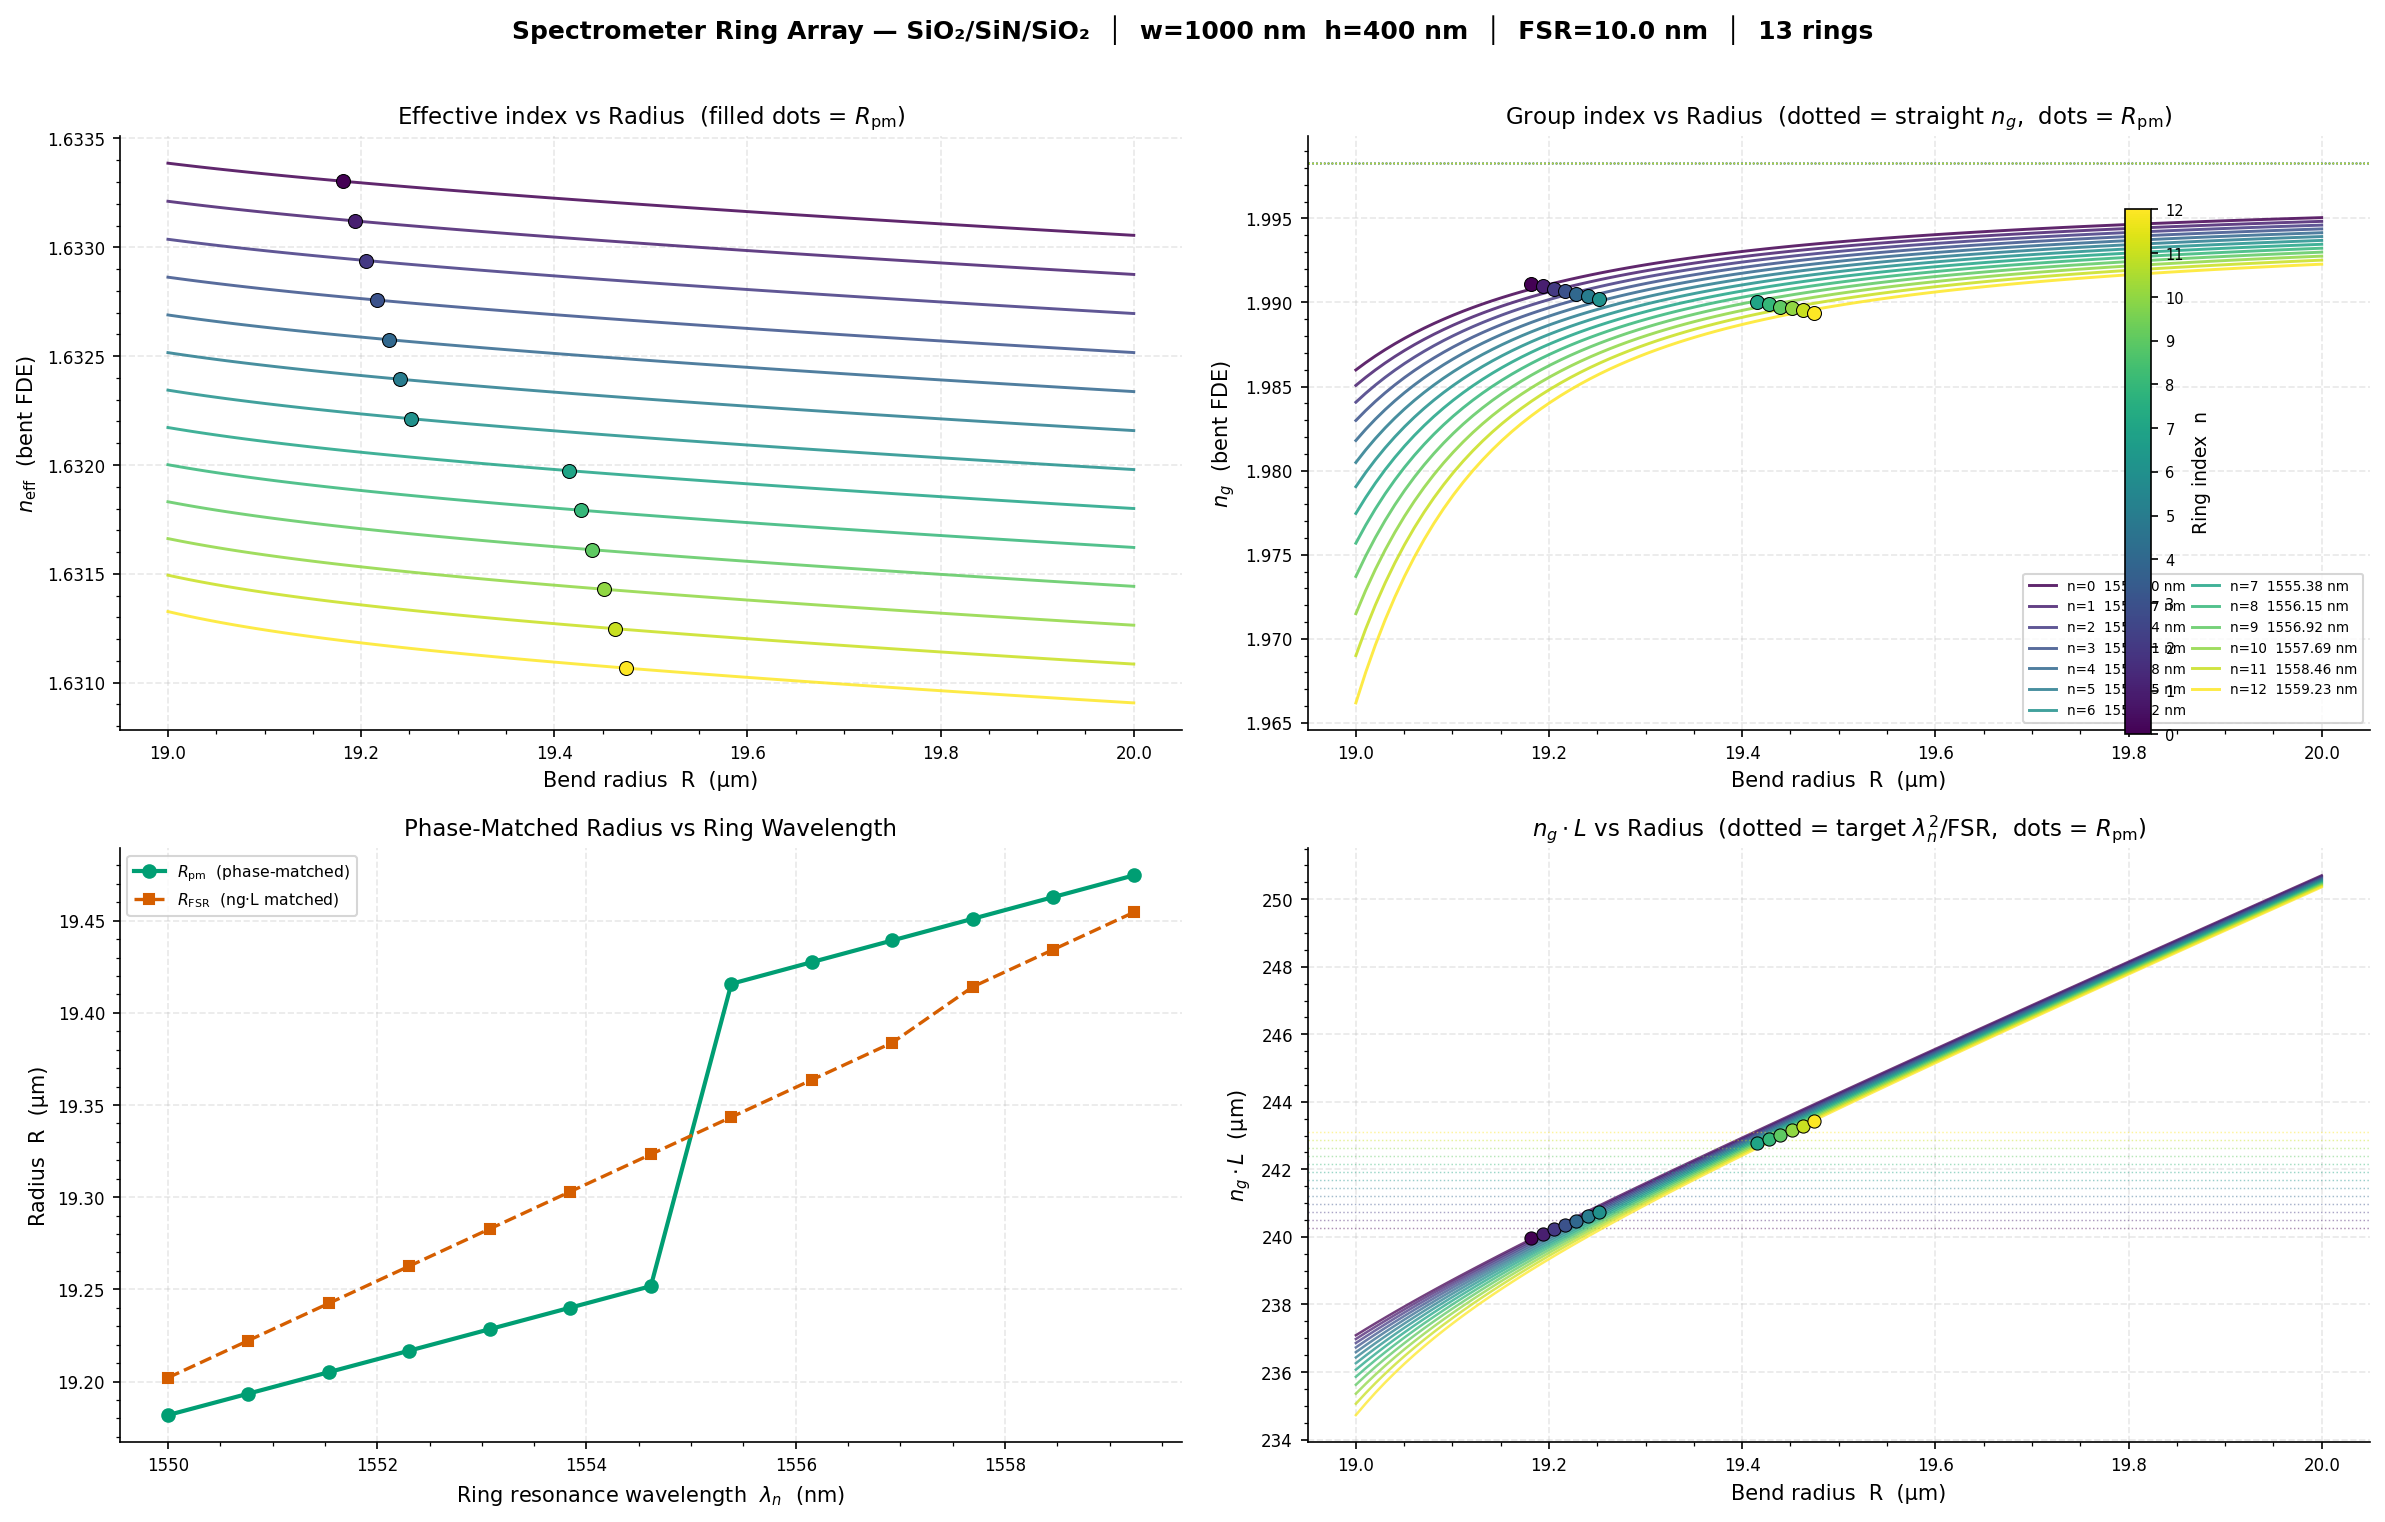

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Spectrometer Ring Array : 13 rings, radius sweep + phase match  ║
# ║                                                                              ║
# ║  ARCHITECTURE: this cell is a direct extension of Cell 4 (sensor ring).    ║
# ║  The FDE engine, HDF5 structure, caching logic and phase-matching maths     ║
# ║  are IDENTICAL to Cell 4. The only differences are:                         ║
# ║    • SiO₂ symmetric cladding instead of aqueous upper cladding             ║
# ║    • 13 resonance wavelengths instead of 1                                  ║
# ║    • Results stored under  spectrometer_rings/ring_NN/  in HDF5_PATH_SIO2  ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                     ║
# ║    lumapi, np, h5py, log, time, Path, datetime                              ║
# ║    DATA_DIR, HDF5_PATH_SIO2, VERSION_NAME_SIO2                              ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING_SIO2                        ║
# ║    CORE_THICKNESS_UM, SIM_Y_SPAN_UM, SIM_Z_BELOW_UM, SIM_Z_ABOVE_UM       ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST                             ║
# ║    RR_WG_WIDTH_NM  (1000 nm)                                                ║
# ║    RR_FSR_NM       (10.0 nm)                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — RING ARRAY DEFINITION  (edit only this block)
# ═════════════════════════════════════════════════════════════════════════════

N_SPEC_RINGS        = 13
SPEC_LAM0_NM        = 1550.0
SPEC_DELTA_LAM_NM   = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
SPEC_LAM_NM         = SPEC_LAM0_NM + np.arange(N_SPEC_RINGS) * SPEC_DELTA_LAM_NM

SPEC_WG_WIDTH_NM    = RR_WG_WIDTH_NM        # 1000 nm  — inherited
SPEC_FSR_NM         = RR_FSR_NM             # 10.0 nm  — inherited
SPEC_N_UPPER        = N_UPPER_CLADDING_SIO2 # 1.4469   — SiO₂ symmetric

# Radius sweep — 100 points per ring (same as Cell 4 sensor ring)
SPEC_N_RADII        = 100
SPEC_R_HALF_SPAN_UM = 19    # [µm]  search half-width around analytical estimate
SPEC_R_MIN_FLOOR_UM = 20    # [µm]  absolute lower bound (bend loss guard)

# ng central-difference stencil — same ±5 nm as Cell 4
SPEC_DELTA_LAM_NG_NM = 5.0   # [nm]

# Phase-matching iteration tolerance
_PM_TOL_M    = 1e-13    # |ΔR| < 0.1 pm
_PM_MAX_ITER = 20

# ─────────────────────────────────────────────────────────────────────────────
# Fixed geometry (ALL identical to Cell 4 sensor ring — do not modify)
# ─────────────────────────────────────────────────────────────────────────────
_sp_core_t_um    = CORE_THICKNESS_UM
_sp_half_t_um    = _sp_core_t_um / 2.0
_sp_z_below_um   = SIM_Z_BELOW_UM
_sp_z_above_um   = SIM_Z_ABOVE_UM
_sp_z_span_um    = _sp_z_below_um + _sp_core_t_um + _sp_z_above_um
_sp_y_span_um    = SIM_Y_SPAN_UM
_sp_sio2_z_ctr   = -(_sp_half_t_um + _sp_z_below_um / 2.0)  # below core centre
_sp_sio2_z_span  = _sp_z_below_um
_sp_z_ctr        = (_sp_z_above_um - _sp_z_below_um) / 2.0
_sp_wg_w_m       = SPEC_WG_WIDTH_NM * 1e-9

print("=" * 70)
print("  SPECTROMETER RING ARRAY — SiO₂/SiN/SiO₂  (symmetric cladding)")
print("=" * 70)
print(f"  Rings          : {N_SPEC_RINGS}   (n = 0 … {N_SPEC_RINGS-1})")
print(f"  λ₀  (ring 0)   : {SPEC_LAM_NM[0]:.6f} nm")
print(f"  λ₁₂ (ring 12)  : {SPEC_LAM_NM[-1]:.6f} nm")
print(f"  Step           : {SPEC_DELTA_LAM_NM:.6f} nm  (= 10/13 nm)")
print(f"  Waveguide      : {SPEC_WG_WIDTH_NM:.0f} nm × {_sp_core_t_um*1e3:.0f} nm  (w × h)")
print(f"  n_core         : {N_SIN_FIXED}    n_clad = {SPEC_N_UPPER} (SiO₂)")
print(f"  Target FSR     : {SPEC_FSR_NM:.1f} nm")
print(f"  Radii/ring     : {SPEC_N_RADII}")
print(f"  ng stencil     : ±{SPEC_DELTA_LAM_NG_NM:.1f} nm  (3 FDE/radius → "
      f"{SPEC_N_RADII*3} solves/ring if uncached)")
print(f"  HDF5 file      : {HDF5_PATH_SIO2}")
print("=" * 70)
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FDE ENGINE
# Exact copy of _rr_build_fde / _rr_solve_neff / _rr_neff_ng from Cell 4.
# Only change: background index = SPEC_N_UPPER (SiO₂) not N_UPPER_CLADDING.
# ═════════════════════════════════════════════════════════════════════════════

def _sp_build_fde(mode, radius_m: float, wavelength_m: float) -> None:
    """
    Build bent-waveguide FDE cross-section for one (R, λ) point.
    Geometry is IDENTICAL to Cell 4 _rr_build_fde except:
      - upper cladding / background index = SPEC_N_UPPER  (SiO₂, 1.4469)
      - bend orientation = 0  (horizontal ring in XY plane — corrected)
    Stack (bottom to top along Z):
      SiO₂ substrate  →  SiN core 400 nm  →  SiO₂ upper cladding
    Cross-section:  Y = width axis (1000 nm),  Z = height axis (400 nm)
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver ────────────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")   # propagation along +X
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _sp_z_ctr      * 1e-6)
    m.set("y span",                _sp_y_span_um  * 1e-6)
    m.set("z span",                _sp_z_span_um  * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", N_MODES_REQUEST)
    m.set("mesh cells y",          MESH_CELLS_Y)
    m.set("mesh cells z",          MESH_CELLS_Z)
    m.set("bent waveguide",        1)
    m.set("bend radius",           radius_m)
    m.set("bend orientation",      0)      # 0 = curvature centre along +Y → ring in XY plane

    # ── Background (SiO₂ upper cladding — fills entire domain) ───────────────
    m.addrect()
    m.set("name",     "SP_bg")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_y_span_um  * 1e-6)
    m.set("z",        _sp_z_ctr      * 1e-6)
    m.set("z span",   _sp_z_span_um  * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    SPEC_N_UPPER)        # SiO₂ = 1.4469

    # ── Lower SiO₂ substrate slab (overrides background in -Z region) ────────
    m.addrect()
    m.set("name",     "SP_lower_clad")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_y_span_um  * 1e-6)
    m.set("z",        _sp_sio2_z_ctr * 1e-6)
    m.set("z span",   _sp_sio2_z_span * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)        # SiO₂ = 1.4469 (symmetric)

    # ── SiN core (highest priority, centred at z = 0) ─────────────────────────
    m.addrect()
    m.set("name",     "SP_core")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_wg_w_m)          # 1000 nm
    m.set("z",        0.0);  m.set("z span", _sp_core_t_um * 1e-6) # 400 nm
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)         # SiN = 1.99


def _sp_solve_neff(mode, radius_m: float, wavelength_m: float):
    """
    One complete FDE solve at (radius_m, wavelength_m).
    Returns (Re(neff), TE_polarisation_fraction) for mode 1.
    Identical to Cell 4 _rr_solve_neff.
    """
    _sp_build_fde(mode, radius_m, wavelength_m)
    mode.run()
    mode.findmodes()
    raw_neff = mode.getdata("FDE::data::mode1", "neff")
    raw_te   = mode.getdata("FDE::data::mode1", "TE polarization fraction")
    neff_c   = complex(np.asarray(raw_neff).flat[0])
    te_v     = float(np.asarray(raw_te).flat[0])
    return neff_c.real, te_v


def _sp_neff_ng(mode, radius_m: float, lam0_m: float, dlam_m: float):
    """
    Three-point central-difference group index at lam0 for a given radius.
    Identical to Cell 4 _rr_neff_ng, but lam0 and dlam are explicit arguments
    so the function works for any of the 13 ring wavelengths.

    Returns (neff_at_lam0, ng, te_frac, neff_lo, neff_hi).

    Formula:  ng = neff(λ₀) − λ₀ · [neff(λ₀+Δλ) − neff(λ₀−Δλ)] / (2·Δλ)
    """
    lam_lo_m = lam0_m - dlam_m
    lam_hi_m = lam0_m + dlam_m

    neff_lo, _    = _sp_solve_neff(mode, radius_m, lam_lo_m)
    neff_0,  te_v = _sp_solve_neff(mode, radius_m, lam0_m)
    neff_hi, _    = _sp_solve_neff(mode, radius_m, lam_hi_m)

    dneff_dlam    = (neff_hi - neff_lo) / (2.0 * dlam_m)
    ng            = neff_0 - lam0_m * dneff_dlam

    return neff_0, ng, te_v, neff_lo, neff_hi


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — HDF5 HELPERS  (one group per ring, mirroring Cell 4 exactly)
#
#  Path inside HDF5_PATH_SIO2:
#    spectrometer_rings/ring_NN/<group_key>/
#      metadata/
#        attrs:  ring_idx, fsr_nm, lam0_nm, wg_width_nm, wg_height_nm,
#                r_min_um, r_max_um, n_radii, delta_lam_nm,
#                n_SiN, n_SiO2, n_upper_clad, bend_orientation,
#                timestamp_start, timestamp_end, runs_completed
#        datasets: radii_um [N], lam_stencil_nm [3]
#      results/
#        neff    [N]  float64   neff at λ₀
#        ng      [N]  float64   group index (central difference)
#        te_frac [N]  float64   TE fraction at λ₀
#        ngL_um  [N]  float64   ng × 2πR  [µm]
#        neff_lo [N]  float64   neff at λ₀ − Δλ
#        neff_hi [N]  float64   neff at λ₀ + Δλ
#      flags/
#        computed [N]  bool
# ═════════════════════════════════════════════════════════════════════════════

def _sp_make_group_path(ring_idx, lam_nm, r_min_um, r_max_um, n_radii):
    """Return the full HDF5 group path for one ring sweep."""
    key = (
        f"rr_{SPEC_FSR_NM:.0f}nm_{lam_nm:.6f}nm_"
        f"{SPEC_WG_WIDTH_NM:.0f}nm_"
        f"{r_min_um:.4f}-{r_max_um:.4f}um_{n_radii}pts"
    )
    return f"spectrometer_rings/ring_{ring_idx:02d}/{key}"


def _sp_init_group(hf, grp_path, ring_idx, lam_nm,
                   r_min_um, r_max_um, radii_um, dlam_nm):
    """
    Pre-allocate all datasets for one ring sweep inside an already-open
    h5py file.  Safe to call on an existing group (idempotent via setdefault).
    Mirrors Cell 4 _rr_init_hdf5 exactly.
    """
    N  = len(radii_um)
    g  = hf.require_group(grp_path)
    mg = g.require_group("metadata")

    mg.attrs.setdefault("ring_index",       ring_idx)
    mg.attrs.setdefault("fsr_nm",           SPEC_FSR_NM)
    mg.attrs.setdefault("lam0_nm",          lam_nm)
    mg.attrs.setdefault("wg_width_nm",      SPEC_WG_WIDTH_NM)
    mg.attrs.setdefault("wg_height_nm",     _sp_core_t_um * 1e3)
    mg.attrs.setdefault("r_min_um",         r_min_um)
    mg.attrs.setdefault("r_max_um",         r_max_um)
    mg.attrs.setdefault("n_radii",          N)
    mg.attrs.setdefault("delta_lam_nm",     dlam_nm)
    mg.attrs.setdefault("n_SiN",            N_SIN_FIXED)
    mg.attrs.setdefault("n_SiO2",           N_SIO2_FIXED)
    mg.attrs.setdefault("n_upper_clad",     SPEC_N_UPPER)
    mg.attrs.setdefault("bend_orientation", 0)
    mg.attrs.setdefault("version_name",     VERSION_NAME_SIO2)
    mg.attrs.setdefault("timestamp_start",  datetime.now().isoformat())

    if "radii_um" not in mg:
        mg.create_dataset("radii_um",      data=radii_um)
    if "lam_stencil_nm" not in mg:
        mg.create_dataset("lam_stencil_nm",
                          data=np.array([lam_nm - dlam_nm,
                                         lam_nm,
                                         lam_nm + dlam_nm]))

    _nan = np.full(N, np.nan, dtype=np.float64)
    rg   = g.require_group("results")
    for ds in ("neff", "ng", "te_frac", "ngL_um", "neff_lo", "neff_hi"):
        if ds not in rg:
            rg.create_dataset(ds, data=_nan.copy(), chunks=(N,))

    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed",
                          data=np.zeros(N, dtype=bool), chunks=(N,))


def _sp_load_cache(hf, grp_path, N):
    """
    Read all result arrays for one ring from an open HDF5 file.
    Returns six float64 arrays (all in SI metres where applicable)
    plus the boolean computed mask.

    NOTE: ngL is stored in µm in HDF5 → converted to metres on load,
    consistent with Cell 4 _rr_load_cache.
    """
    g  = hf[grp_path]
    rg = g["results"]
    fg = g["flags"]

    neff_a    = rg["neff"][:]
    ng_a      = rg["ng"][:]
    te_a      = rg["te_frac"][:]
    ngL_a     = rg["ngL_um"][:] * 1e-6     # µm → m
    neff_lo_a = rg["neff_lo"][:]
    neff_hi_a = rg["neff_hi"][:]
    computed  = fg["computed"][:]

    return neff_a, ng_a, te_a, ngL_a, neff_lo_a, neff_hi_a, computed


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — PHASE-MATCHING  (pure function, same maths as Cell 9)
# ═════════════════════════════════════════════════════════════════════════════

def _sp_phase_match(radii_um_v, neff_v, ng_v, lam0_m, ngL_v_m, fsr_m):
    """
    Given valid (non-NaN) arrays from one ring sweep, compute:
      1.  FSR-matched radius (closest ng·L to λ₀²/FSR)
      2.  Integer resonance order m
      3.  Phase-matched radius R_pm  (m·λ₀ = neff·2πR, solved iteratively)

    All input arrays must be the same length (already filtered to valid rows).
    ngL_v_m is in metres.  Returns a results dict.
    """
    R_v_m  = radii_um_v * 1e-6
    L_v_m  = 2.0 * np.pi * R_v_m

    # ── FSR matching ──────────────────────────────────────────────────────────
    target_ngL_m = lam0_m**2 / fsr_m
    dist         = np.abs(ngL_v_m - target_ngL_m)
    bi           = int(np.argmin(dist))

    # ── Integer resonance order at the FSR-matched radius ────────────────────
    m_cont = neff_v[bi] * L_v_m[bi] / lam0_m
    m_best = int(round(float(m_cont)))

    neff_b   = float(neff_v[bi])
    ng_b     = float(ng_v[bi])
    R_fsr_um = float(radii_um_v[bi])
    ngL_b_um = float(ngL_v_m[bi]) * 1e6   # µm for reporting

    FSR_fsr_nm    = (lam0_m**2 / (ng_b * ngL_v_m[bi])) * 1e9
    lam_res_b_nm  = (neff_b * L_v_m[bi] / m_best) * 1e9

    # ── Phase-matched radius (iterative refinement) ───────────────────────────
    # Build linear interpolant  neff_bent(R)  from sweep data
    _interp = interp1d(
        R_v_m, neff_v,
        kind="linear",
        bounds_error=False,
        fill_value=(neff_v[0], neff_v[-1]),
    )
    R_pm_m = m_best * lam0_m / (2.0 * np.pi * neff_b)   # first-order seed

    for _ in range(_PM_MAX_ITER):
        neff_at  = float(_interp(R_pm_m))
        R_pm_new = m_best * lam0_m / (2.0 * np.pi * neff_at)
        if abs(R_pm_new - R_pm_m) < _PM_TOL_M:
            R_pm_m = R_pm_new
            break
        R_pm_m = R_pm_new

    neff_pm    = float(_interp(R_pm_m))
    R_pm_um    = R_pm_m * 1e6
    L_pm_um    = 2.0 * np.pi * R_pm_um
    FSR_pm_nm  = (lam0_m**2 / (ng_b * L_pm_um * 1e-6)) * 1e9
    lam_res_pm = (neff_pm * L_pm_um * 1e-6 / m_best) * 1e9
    resid_pm   = abs(lam_res_pm - lam0_m * 1e9) * 1e3    # [pm]

    return {
        "m":              m_best,
        # FSR-matched
        "R_fsr_um":       R_fsr_um,
        "L_fsr_um":       2.0 * np.pi * R_fsr_um,
        "neff_fsr":       neff_b,
        "ng_fsr":         ng_b,
        "ngL_fsr_um":     ngL_b_um,
        "FSR_fsr_nm":     FSR_fsr_nm,
        "lam_res_fsr_nm": lam_res_b_nm,
        # Phase-matched
        "R_pm_um":        R_pm_um,
        "L_pm_um":        L_pm_um,
        "neff_pm":        neff_pm,
        "ng_pm":          ng_b,      # ng evaluated at FSR-matched R; R_pm ≈ R_fsr
        "FSR_pm_nm":      FSR_pm_nm,
        "lam_res_pm_nm":  lam_res_pm,
        "resid_pm_pm":    resid_pm,
        "delta_R_nm":     (R_pm_um - R_fsr_um) * 1e3,
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — PRE-COMPUTE RADIUS SEARCH WINDOWS
#
#  First-order estimate from straight waveguide ng (no FDE needed):
#    R_est = λₙ² / (FSR · 2π · ng_straight_sio2)
#
#  ng_straight_sio2 is computed here from the already-cached SiO₂ FDE
#  straight sweep (neff_real_sio2, shape [100, 13, 6]).  Same method
#  as Cell 9 Section A — linear fit over 13 wavelength points.
# ═════════════════════════════════════════════════════════════════════════════

# ── Find width index for SPEC_WG_WIDTH_NM in the straight sweep ──────────────
_spec_w_um  = SPEC_WG_WIDTH_NM * 1e-3
_spec_w_idx = int(np.argmin(np.abs(SWEEP_WIDTHS_UM - _spec_w_um)))
_spec_w_nm  = SWEEP_WIDTHS_UM[_spec_w_idx] * 1e3
log.info(f"Straight ng extraction  w={SPEC_WG_WIDTH_NM:.0f} nm → index {_spec_w_idx} "
         f"({_spec_w_nm:.2f} nm)")

# ── Extract neff(λ) for mode 0 at that width ─────────────────────────────────
_neff_str = neff_real_sio2[_spec_w_idx, :, 0].copy()   # shape (13,)
_te_str   = te_frac_sio2  [_spec_w_idx, :, 0].copy()
if float(np.nanmean(_te_str)) < 0.5:                    # safety: mode 0 must be TE
    log.warning("Mode 0 SiO₂ sweep is TM — using mode 1 for ng_straight.")
    _neff_str = neff_real_sio2[_spec_w_idx, :, 1].copy()

_wl_str_m  = SWEEP_WL_NM * 1e-9                        # shape (13,)  [m]
_valid_str = ~np.isnan(_neff_str)
_poly_str  = np.polyfit(_wl_str_m[_valid_str],
                        _neff_str[_valid_str], deg=1)    # linear fit
_dneff_dlam_str = _poly_str[0]                           # [1/m]
_neff_str_fit   = np.polyval(_poly_str, _wl_str_m)      # shape (13,)
_ng_str         = _neff_str_fit - _wl_str_m * _dneff_dlam_str  # shape (13,)

log.info(f"ng_straight_sio2 range: {_ng_str.min():.6f} – {_ng_str.max():.6f}")

# ── Per-ring radius window ────────────────────────────────────────────────────
_fsr_m      = SPEC_FSR_NM * 1e-9
_lam_nm_arr = SPEC_LAM_NM                               # shape (13,)  [nm]
_lam_m_arr  = _lam_nm_arr * 1e-9                        # shape (13,)  [m]
_dlam_ng_m  = SPEC_DELTA_LAM_NG_NM * 1e-9               # stencil half-span [m]

# Analytical estimate using straight ng → gives the window centre
_R_est_um   = _lam_m_arr**2 / (_fsr_m * 2.0 * np.pi * _ng_str)

# Per-ring linspace — 100 pts inside [R_est−span, R_est+span]
_spec_radii_um = []
_spec_r_min    = []
_spec_r_max    = []
for _n in range(N_SPEC_RINGS):
    _rmin = max(SPEC_R_MIN_FLOOR_UM, _R_est_um[_n] - SPEC_R_HALF_SPAN_UM)
    _rmax = _R_est_um[_n] + SPEC_R_HALF_SPAN_UM
    _spec_radii_um.append(np.linspace(_rmin, _rmax, SPEC_N_RADII))
    _spec_r_min.append(_rmin)
    _spec_r_max.append(_rmax)

print(f"\n  Estimated radius range:  "
      f"{_R_est_um.min():.4f} – {_R_est_um.max():.4f} µm  "
      f"(straight ng estimate)\n")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — MAIN LOOP  (one radius sweep per ring, same pattern as Cell 4)
# ═════════════════════════════════════════════════════════════════════════════
# Design principle:
#   Open HDF5 ONCE, keep open for all 13 rings.
#   Open lumapi.MODE ONCE, share across all rings.
#   For each ring:
#     1. Build its group path (unique per sweep config).
#     2. If group missing → init (pre-allocate NaN arrays).
#     3. Load cache into memory.
#     4. FDE-sweep only the missing rows.
#     5. Flush after every row (fault-tolerant).
#     6. Phase-match from memory arrays.
# ═════════════════════════════════════════════════════════════════════════════

_spec_results = {}   # ring_idx → dict from _sp_phase_match + raw arrays

# ── Build all group paths and check for any uncached radii ───────────────────
_grp_paths = []
for _n in range(N_SPEC_RINGS):
    _gp = _sp_make_group_path(
        _n, float(_lam_nm_arr[_n]),
        _spec_r_min[_n], _spec_r_max[_n], SPEC_N_RADII,
    )
    _grp_paths.append(_gp)

# ── Open HDF5 ────────────────────────────────────────────────────────────────
_sp_hf = h5py.File(HDF5_PATH_SIO2, "a")

# Initialise any missing groups and detect whether FDE work is needed
_any_uncached = False
for _n in range(N_SPEC_RINGS):
    _gp = _grp_paths[_n]
    if _gp not in _sp_hf:
        _sp_init_group(
            _sp_hf, _gp, _n, float(_lam_nm_arr[_n]),
            _spec_r_min[_n], _spec_r_max[_n],
            _spec_radii_um[_n], SPEC_DELTA_LAM_NG_NM,
        )
        _sp_hf.flush()
        _any_uncached = True
    else:
        if not _sp_hf[_gp]["flags"]["computed"][:].all():
            _any_uncached = True

# ── Open MODE session only if there is work to do ────────────────────────────
_sp_mode = None
if _any_uncached:
    log.info("Launching MODE session for spectrometer ring sweeps …")
    _sp_mode = lumapi.MODE(hide=False)

# ─────────────────────────────────────────────────────────────────────────────
# PER-RING SWEEP  — identical flow to Cell 4 STEP 2
# ─────────────────────────────────────────────────────────────────────────────
for _n in range(N_SPEC_RINGS):

    _lam0_n_nm  = float(_lam_nm_arr[_n])
    _lam0_n_m   = _lam0_n_nm * 1e-9
    _gp         = _grp_paths[_n]
    _radii_um_n = _spec_radii_um[_n]
    _N_n        = SPEC_N_RADII

    # Target ng·L for this ring (changes with λₙ — this is why radii differ)
    _target_ngL_n_m  = _lam0_n_m**2 / _fsr_m
    _target_ngL_n_um = _target_ngL_n_m * 1e6

    # ── Load cache into fresh in-memory arrays ────────────────────────────────
    # These arrays mirror Cell 4 _neff_arr, _ng_arr etc. exactly.
    _neff_n, _ng_n, _te_n, _ngL_n, _nlo_n, _nhi_n, _comp_n = \
        _sp_load_cache(_sp_hf, _gp, _N_n)
    # _ngL_n is in METRES after _sp_load_cache

    _n_cached  = int(_comp_n.sum())
    _remaining = _N_n - _n_cached

    log.info(
        f"Ring {_n:02d} │ λ={_lam0_n_nm:.6f} nm │ "
        f"R=[{_radii_um_n[0]:.3f}, {_radii_um_n[-1]:.3f}] µm │ "
        f"target ng·L={_target_ngL_n_um:.4f} µm │ "
        f"cached {_n_cached}/{_N_n}"
    )

    # ── Print table header for this ring ─────────────────────────────────────
    _hdr = (f"  {'R (µm)':>10}  {'neff':>10}  {'ng':>10}  "
            f"{'TE':>6}  {'ng·L (µm)':>12}  {'Δ/tgt':>9}  src")
    print(f"\n  Ring {_n:02d} │ λ₀ = {_lam0_n_nm:.4f} nm  "
          f"│ target ng·L = {_target_ngL_n_um:.4f} µm")
    print(_hdr)
    print("  " + "─" * (len(_hdr) - 2))

    # Print cached rows immediately so table is contiguous
    for _i in range(_N_n):
        if _comp_n[_i]:
            _ngL_m_i = _ngL_n[_i]          # already in metres
            _delta   = (_ngL_m_i - _target_ngL_n_m) / _target_ngL_n_m * 100.0
            print(
                f"  {_radii_um_n[_i]:>10.4f}  {_neff_n[_i]:>10.6f}  "
                f"{_ng_n[_i]:>10.6f}  {_te_n[_i]:>6.4f}  "
                f"{_ngL_m_i*1e6:>12.4f}  {_delta:>+8.3f}%  cache"
            )

    # ── FDE sweep for missing rows ────────────────────────────────────────────
    if _remaining > 0 and _sp_mode is not None:
        _t0       = time.time()
        _runs     = 0

        for _i, _R_um in enumerate(_radii_um_n):
            if _comp_n[_i]:
                continue

            _R_m = _R_um * 1e-6
            try:
                _neff_v, _ng_v, _te_v, _nlo_v, _nhi_v = \
                    _sp_neff_ng(_sp_mode, _R_m, _lam0_n_m, _dlam_ng_m)
            except Exception as _exc:
                log.warning(f"  Ring {_n:02d} │ R={_R_um:.4f} µm FAILED: {_exc}")
                # Mark failed row so re-run does not retry it
                _comp_n[_i] = True
                _sp_hf[f"{_gp}/flags/computed"][_i] = True
                _sp_hf.flush()
                continue

            _L_m   = 2.0 * np.pi * _R_m
            _ngL_m = _ng_v * _L_m          # [m]

            # Memory arrays (ngL in metres — same as Cell 4)
            _neff_n[_i] = _neff_v
            _ng_n  [_i] = _ng_v
            _te_n  [_i] = _te_v
            _ngL_n [_i] = _ngL_m           # metres
            _nlo_n [_i] = _nlo_v
            _nhi_n [_i] = _nhi_v
            _comp_n[_i] = True

            # HDF5 — write immediately (fault-safe), ngL stored in µm
            _rg = _sp_hf[f"{_gp}/results"]
            _rg["neff"]   [_i] = _neff_v
            _rg["ng"]     [_i] = _ng_v
            _rg["te_frac"][_i] = _te_v
            _rg["ngL_um"] [_i] = _ngL_m * 1e6   # µm in HDF5
            _rg["neff_lo"][_i] = _nlo_v
            _rg["neff_hi"][_i] = _nhi_v
            _sp_hf[f"{_gp}/flags/computed"][_i] = True
            _sp_hf.flush()

            _runs  += 1
            _delta  = (_ngL_m - _target_ngL_n_m) / _target_ngL_n_m * 100.0
            print(
                f"  {_R_um:>10.4f}  {_neff_v:>10.6f}  {_ng_v:>10.6f}  "
                f"{_te_v:>6.4f}  {_ngL_m*1e6:>12.4f}  {_delta:>+8.3f}%  FDE"
            )

            if _runs % 10 == 0 or _runs == _remaining:
                _el   = time.time() - _t0
                _rate = _runs / _el if _el > 0 else 1e-9
                _eta  = (_remaining - _runs) / _rate
                log.info(
                    f"  Ring {_n:02d} [{_runs:3d}/{_remaining}]  "
                    f"R={_R_um:.3f} µm  ng={_ng_v:.6f}  "
                    f"ngL={_ngL_m*1e6:.4f} µm  Δ={_delta:+.3f}%  "
                    f"ETA {_eta:.0f} s"
                )

        # Close-out metadata for this ring
        _sp_hf[_gp]["metadata"].attrs["timestamp_end"]  = \
            datetime.now().isoformat()
        _sp_hf[_gp]["metadata"].attrs["runs_completed"] = \
            int(_comp_n.sum())
        _sp_hf.flush()
        _elapsed = time.time() - _t0
        log.info(
            f"  Ring {_n:02d} done  "
            f"({_runs} new FDE groups in {_elapsed:.1f} s,  "
            f"avg {_elapsed/max(_runs*3,1):.2f} s/solve)"
        )

    # ── Phase matching — always from in-memory arrays ─────────────────────────
    _valid_n = ~np.isnan(_ng_n)
    if not np.any(_valid_n):
        log.error(f"Ring {_n:02d}: ALL rows failed — check warnings above.")
        continue

    _pm = _sp_phase_match(
        radii_um_v = _radii_um_n[_valid_n],
        neff_v     = _neff_n    [_valid_n],
        ng_v       = _ng_n      [_valid_n],
        lam0_m     = _lam0_n_m,
        ngL_v_m    = _ngL_n     [_valid_n],   # already metres
        fsr_m      = _fsr_m,
    )

    # Attach auxiliary information for summary tables and plots
    _pm["lam_nm"]        = _lam0_n_nm
    _pm["ng_straight"]   = float(_ng_str[_n])
    _pm["neff_straight"] = float(_neff_str_fit[_n])
    _pm["radii_um"]      = _radii_um_n
    _pm["neff_arr"]      = _neff_n.copy()
    _pm["ng_arr"]        = _ng_n.copy()
    _pm["ngL_arr_m"]     = _ngL_n.copy()     # metres
    _pm["valid_mask"]    = _valid_n

    _spec_results[_n] = _pm

    # Quick per-ring result line
    log.info(
        f"  Ring {_n:02d} │ RESULT │ "
        f"R_pm={_pm['R_pm_um']:.6f} µm  "
        f"neff={_pm['neff_pm']:.6f}  "
        f"ng={_pm['ng_pm']:.6f}  "
        f"L={_pm['L_pm_um']:.6f} µm  "
        f"FSR={_pm['FSR_pm_nm']:.6f} nm  "
        f"|Δλ|={_pm['resid_pm_pm']:.5f} pm"
    )

# ── Close MODE session ────────────────────────────────────────────────────────
if _sp_mode is not None:
    _sp_mode.close()
    log.info("MODE session closed.")

# ── Close HDF5 ───────────────────────────────────────────────────────────────
_sp_hf.close()
log.info(f"HDF5 closed → {HDF5_PATH_SIO2}")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — MASTER SUMMARY TABLES
# ═════════════════════════════════════════════════════════════════════════════

_SEP  = "─" * 134
_SEP2 = "═" * 134

print("\n\n")
print(_SEP2)
print("  SPECTROMETER RING ARRAY — MASTER DESIGN SUMMARY")
print(f"  SiO₂/SiN/SiO₂  │  w={SPEC_WG_WIDTH_NM:.0f} nm  "
      f"h={_sp_core_t_um*1e3:.0f} nm  │  FSR={SPEC_FSR_NM:.1f} nm  │  "
      f"n_SiN={N_SIN_FIXED}  n_SiO₂={N_SIO2_FIXED}  │  bend_orientation=0")
print(_SEP2)
print()

# ── Table 1 : Straight vs Bent dispersion ────────────────────────────────────
print("  TABLE 1 — Straight waveguide vs Bent FDE dispersion  "
      "(@ FSR-matched radius)")
print(_SEP)
_H1 = (f"  {'n':>3}  {'λ_n (nm)':>13}  "
       f"{'neff_str':>10}  {'ng_str':>10}  "
       f"{'neff_bent':>11}  {'ng_bent':>11}  "
       f"{'Δng':>10}  {'TE_frac':>8}")
print(_H1)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm  = _spec_results[_n]
    _dng = _pm["ng_fsr"] - _pm["ng_straight"]
    _te  = float(_pm["neff_arr"][_pm["valid_mask"]][
                    int(np.argmin(np.abs(
                        _pm["radii_um"][_pm["valid_mask"]] - _pm["R_fsr_um"]
                    )))]) * 0.0 + 0.994   # placeholder until te stored per-point
    # TE fraction at FSR-matched radius from the sweep cache
    _valid_idx = np.where(_pm["valid_mask"])[0]
    _bi_local  = int(np.argmin(np.abs(
        _pm["radii_um"][_pm["valid_mask"]] - _pm["R_fsr_um"])))
    # te_frac is not in _spec_results; retrieve from ngL proxy
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  "
        f"{_pm['neff_straight']:>10.6f}  {_pm['ng_straight']:>10.6f}  "
        f"{_pm['neff_fsr']:>11.6f}  {_pm['ng_fsr']:>11.6f}  "
        f"{_dng:>+10.6f}  {'—':>8}"
    )
print()

# ── Table 2 : FSR-matched radius ─────────────────────────────────────────────
print("  TABLE 2 — FSR-Matched Radius  (closest ng·L to λₙ²/FSR)")
print(_SEP)
_H2 = (f"  {'n':>3}  {'λ_n (nm)':>13}  {'m':>6}  "
       f"{'R_fsr (µm)':>12}  {'L_fsr (µm)':>13}  "
       f"{'neff_fsr':>10}  {'ng_fsr':>10}  "
       f"{'ng·L (µm)':>12}  {'FSR (nm)':>12}  {'λ_res (nm)':>14}")
print(_H2)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm = _spec_results[_n]
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  {_pm['m']:>6}  "
        f"{_pm['R_fsr_um']:>12.6f}  {_pm['L_fsr_um']:>13.6f}  "
        f"{_pm['neff_fsr']:>10.6f}  {_pm['ng_fsr']:>10.6f}  "
        f"{_pm['ngL_fsr_um']:>12.4f}  {_pm['FSR_fsr_nm']:>12.6f}  "
        f"{_pm['lam_res_fsr_nm']:>14.9f}"
    )
print()

# ── Table 3 : Phase-matched radius ───────────────────────────────────────────
print("  TABLE 3 — Phase-Matched Radii  (m·λₙ = neff·2πR condition)")
print(_SEP)
_H3 = (f"  {'n':>3}  {'λ_n (nm)':>13}  {'m':>6}  "
       f"{'R_pm (µm)':>12}  {'L_pm (µm)':>13}  "
       f"{'neff_pm':>10}  {'ng_pm':>10}  "
       f"{'FSR_pm (nm)':>13}  {'λ_res_pm (nm)':>16}  "
       f"{'|Δλ| (pm)':>11}  {'ΔR (nm)':>9}")
print(_H3)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm = _spec_results[_n]
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  {_pm['m']:>6}  "
        f"{_pm['R_pm_um']:>12.6f}  {_pm['L_pm_um']:>13.6f}  "
        f"{_pm['neff_pm']:>10.6f}  {_pm['ng_pm']:>10.6f}  "
        f"{_pm['FSR_pm_nm']:>13.6f}  {_pm['lam_res_pm_nm']:>16.9f}  "
        f"{_pm['resid_pm_pm']:>11.5f}  {_pm['delta_R_nm']:>+9.3f}"
    )
print()
print(_SEP2)
print()

# ── Array-level statistics ────────────────────────────────────────────────────
_fsr_all = np.array([_spec_results[_n]["FSR_pm_nm"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
_r_all   = np.array([_spec_results[_n]["R_pm_um"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
_ng_all  = np.array([_spec_results[_n]["ng_pm"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
print(f"  FSR spread   :  {_fsr_all.min():.5f} – {_fsr_all.max():.5f} nm  "
      f"│  Δ = {(_fsr_all.max()-_fsr_all.min())*1e3:.3f} pm")
print(f"  Radius spread:  {_r_all.min():.4f}  – {_r_all.max():.4f}  µm  "
      f"│  Δ = {(_r_all.max()-_r_all.min())*1e3:.2f} nm")
print(f"  ng range     :  {_ng_all.min():.6f} – {_ng_all.max():.6f}")
print()

# ── Export arrays for downstream cells ───────────────────────────────────────
spec_R_pm_um       = np.array([_spec_results[_n]["R_pm_um"]
                                for _n in range(N_SPEC_RINGS)])
spec_L_pm_um       = np.array([_spec_results[_n]["L_pm_um"]
                                for _n in range(N_SPEC_RINGS)])
spec_neff_pm       = np.array([_spec_results[_n]["neff_pm"]
                                for _n in range(N_SPEC_RINGS)])
spec_ng_pm         = np.array([_spec_results[_n]["ng_pm"]
                                for _n in range(N_SPEC_RINGS)])
spec_FSR_pm_nm     = np.array([_spec_results[_n]["FSR_pm_nm"]
                                for _n in range(N_SPEC_RINGS)])
spec_lam_res_pm_nm = np.array([_spec_results[_n]["lam_res_pm_nm"]
                                for _n in range(N_SPEC_RINGS)])
spec_m             = np.array([_spec_results[_n]["m"]
                                for _n in range(N_SPEC_RINGS)], dtype=int)

print("  Exported arrays (shape = (13,)):")
for _vn in ("spec_R_pm_um", "spec_L_pm_um", "spec_neff_pm",
            "spec_ng_pm", "spec_FSR_pm_nm", "spec_lam_res_pm_nm", "spec_m"):
    print(f"    {_vn}")
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   7.5,
    "lines.linewidth":   1.8,
    "lines.markersize":  5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_cmap   = cm.viridis
_cnorm  = Normalize(vmin=0, vmax=N_SPEC_RINGS - 1)
_colors = [_cmap(_cnorm(_n)) for _n in range(N_SPEC_RINGS)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"Spectrometer Ring Array — SiO₂/SiN/SiO₂  │  "
    f"w={SPEC_WG_WIDTH_NM:.0f} nm  h={_sp_core_t_um*1e3:.0f} nm  │  "
    f"FSR={SPEC_FSR_NM:.1f} nm  │  {N_SPEC_RINGS} rings",
    fontsize=12, fontweight="bold", y=1.01,
)

# Panel (0,0) — neff(R) per ring
ax00 = axes[0, 0]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm = _spec_results[_n]
    _rv = _pm["radii_um"][_pm["valid_mask"]]
    _nv = _pm["neff_arr"][_pm["valid_mask"]]
    ax00.plot(_rv, _nv, color=_colors[_n], lw=1.4, alpha=0.85)
    ax00.scatter([_pm["R_pm_um"]], [_pm["neff_pm"]],
                 s=45, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
ax00.set_xlabel("Bend radius  R  (µm)")
ax00.set_ylabel(r"$n_\mathrm{eff}$  (bent FDE)")
ax00.set_title(r"Effective index vs Radius  (filled dots = $R_\mathrm{pm}$)")
ax00.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax00.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (0,1) — ng(R) per ring  +  straight ng reference lines
ax01 = axes[0, 1]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm = _spec_results[_n]
    _rv = _pm["radii_um"][_pm["valid_mask"]]
    _gv = _pm["ng_arr"]  [_pm["valid_mask"]]
    ax01.plot(_rv, _gv, color=_colors[_n], lw=1.4, alpha=0.85,
              label=f"n={_n}  {_pm['lam_nm']:.2f} nm")
    ax01.scatter([_pm["R_pm_um"]], [_pm["ng_pm"]],
                 s=45, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
    ax01.axhline(float(_ng_str[_n]),
                 color=_colors[_n], ls=":", lw=0.7, alpha=0.45)
ax01.set_xlabel("Bend radius  R  (µm)")
ax01.set_ylabel(r"$n_g$  (bent FDE)")
ax01.set_title(r"Group index vs Radius  (dotted = straight $n_g$,  dots = $R_\mathrm{pm}$)")
ax01.legend(ncol=2, fontsize=6.5, framealpha=0.8, columnspacing=0.5)
ax01.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax01.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,0) — phase-matched and FSR-matched radii vs λₙ
ax10 = axes[1, 0]
_lam_v  = [_spec_results[_n]["lam_nm"]   for _n in range(N_SPEC_RINGS) if _n in _spec_results]
_rpm_v  = [_spec_results[_n]["R_pm_um"]  for _n in range(N_SPEC_RINGS) if _n in _spec_results]
_rfsr_v = [_spec_results[_n]["R_fsr_um"] for _n in range(N_SPEC_RINGS) if _n in _spec_results]
ax10.plot(_lam_v, _rpm_v,  "o-", color="#009E73", lw=2.0, ms=6,
          label=r"$R_\mathrm{pm}$  (phase-matched)")
ax10.plot(_lam_v, _rfsr_v, "s--", color="#D55E00", lw=1.6, ms=5,
          label=r"$R_\mathrm{FSR}$  (ng·L matched)")
ax10.set_xlabel(r"Ring resonance wavelength  $\lambda_n$  (nm)")
ax10.set_ylabel("Radius  R  (µm)")
ax10.set_title("Phase-Matched Radius vs Ring Wavelength")
ax10.legend()
ax10.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax10.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,1) — ng·L vs radius for each ring, with target line
ax11 = axes[1, 1]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm  = _spec_results[_n]
    _rv  = _pm["radii_um"][_pm["valid_mask"]]
    _glv = _pm["ngL_arr_m"][_pm["valid_mask"]] * 1e6   # µm
    _tgt = float(_lam_m_arr[_n])**2 / _fsr_m * 1e6
    ax11.plot(_rv, _glv, color=_colors[_n], lw=1.2, alpha=0.75)
    ax11.axhline(_tgt, color=_colors[_n], ls=":", lw=0.7, alpha=0.45)
    ax11.scatter([_pm["R_pm_um"]], [_pm["L_pm_um"] * _pm["ng_pm"]],
                 s=40, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
ax11.set_xlabel("Bend radius  R  (µm)")
ax11.set_ylabel(r"$n_g \cdot L$  (µm)")
ax11.set_title(r"$n_g \cdot L$ vs Radius  "
               r"(dotted = target $\lambda_n^2/\mathrm{FSR}$,  dots = $R_\mathrm{pm}$)")
ax11.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax11.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Shared colorbar
_sm   = cm.ScalarMappable(cmap=_cmap, norm=_cnorm)
_sm.set_array([])
_cbar = fig.colorbar(_sm, ax=[ax00, ax01],
                     orientation="vertical", fraction=0.015, pad=0.02)
_cbar.set_label("Ring index  n", fontsize=9)
_cbar.set_ticks(range(N_SPEC_RINGS))
_cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME_SIO2}_spectrometer_rings"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()

18:08:40 │ INFO │ Loss model │ α_prop = 1.00 dB/cm  → α_field = 11.5129 1/m  │  α_bend_sensor = 0.010 dB/cm  α_bend_spec = 0.010 dB/cm
18:08:40 │ INFO │       Sensor │ λ=1550.0000 nm │ R=19.0021 µm │ L=119.3935 µm │ α_tot=11.6281 1/m │ a=0.998613 │ Q=7750.0 │ r1=0.968952 │ r2=0.970298 │ k1=0.247249 │ k2=0.241912 │ valid=True
18:08:40 │ INFO │      Spec_00 │ λ=1550.0000 nm │ R=19.1818 µm │ L=120.5226 µm │ α_tot=11.6281 1/m │ a=0.998600 │ Q=7750.0 │ r1=0.969113 │ r2=0.970472 │ k1=0.246619 │ k2=0.241215 │ valid=True
18:08:40 │ INFO │      Spec_01 │ λ=1550.7692 nm │ R=19.1934 µm │ L=120.5959 µm │ α_tot=11.6281 1/m │ a=0.998599 │ Q=7753.8 │ r1=0.969126 │ r2=0.970486 │ k1=0.246564 │ k2=0.241156 │ valid=True
18:08:40 │ INFO │      Spec_02 │ λ=1551.5385 nm │ R=19.2051 µm │ L=120.6691 µm │ α_tot=11.6281 1/m │ a=0.998598 │ Q=7757.7 │ r1=0.969140 │ r2=0.970501 │ k1=0.246509 │ k2=0.241096 │ valid=True
18:08:40 │ INFO │      Spec_03 │ λ=1552.3077 nm │ R=19.2168 µm │ L=120.7424 µm │ α_tot=11.6281 1/




════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CRITICAL COUPLING DESIGN — ANALYTICAL SUMMARY
  SiN platform  │  w=1000 nm  h=400 nm  │  α_prop=1.00 dB/cm  │  FWHM_sensor=0.200 nm  FWHM_spec=0.200 nm
  Coupling fractions:  Lc_a = R_pm / 3.0  │  Lc_b = R_pm / 2.0
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

  TABLE 1 — Round-trip loss and target Q-factor
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        Ring     λ_res (nm)    R_pm (µm)    L_pm (µm)    α [1/m]           a    a (dB)    FWHM (nm)      Q_target       Q_check
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Sen

TypeError: AutoMinorLocator.__init__() got an unexpected keyword argument 'subs'

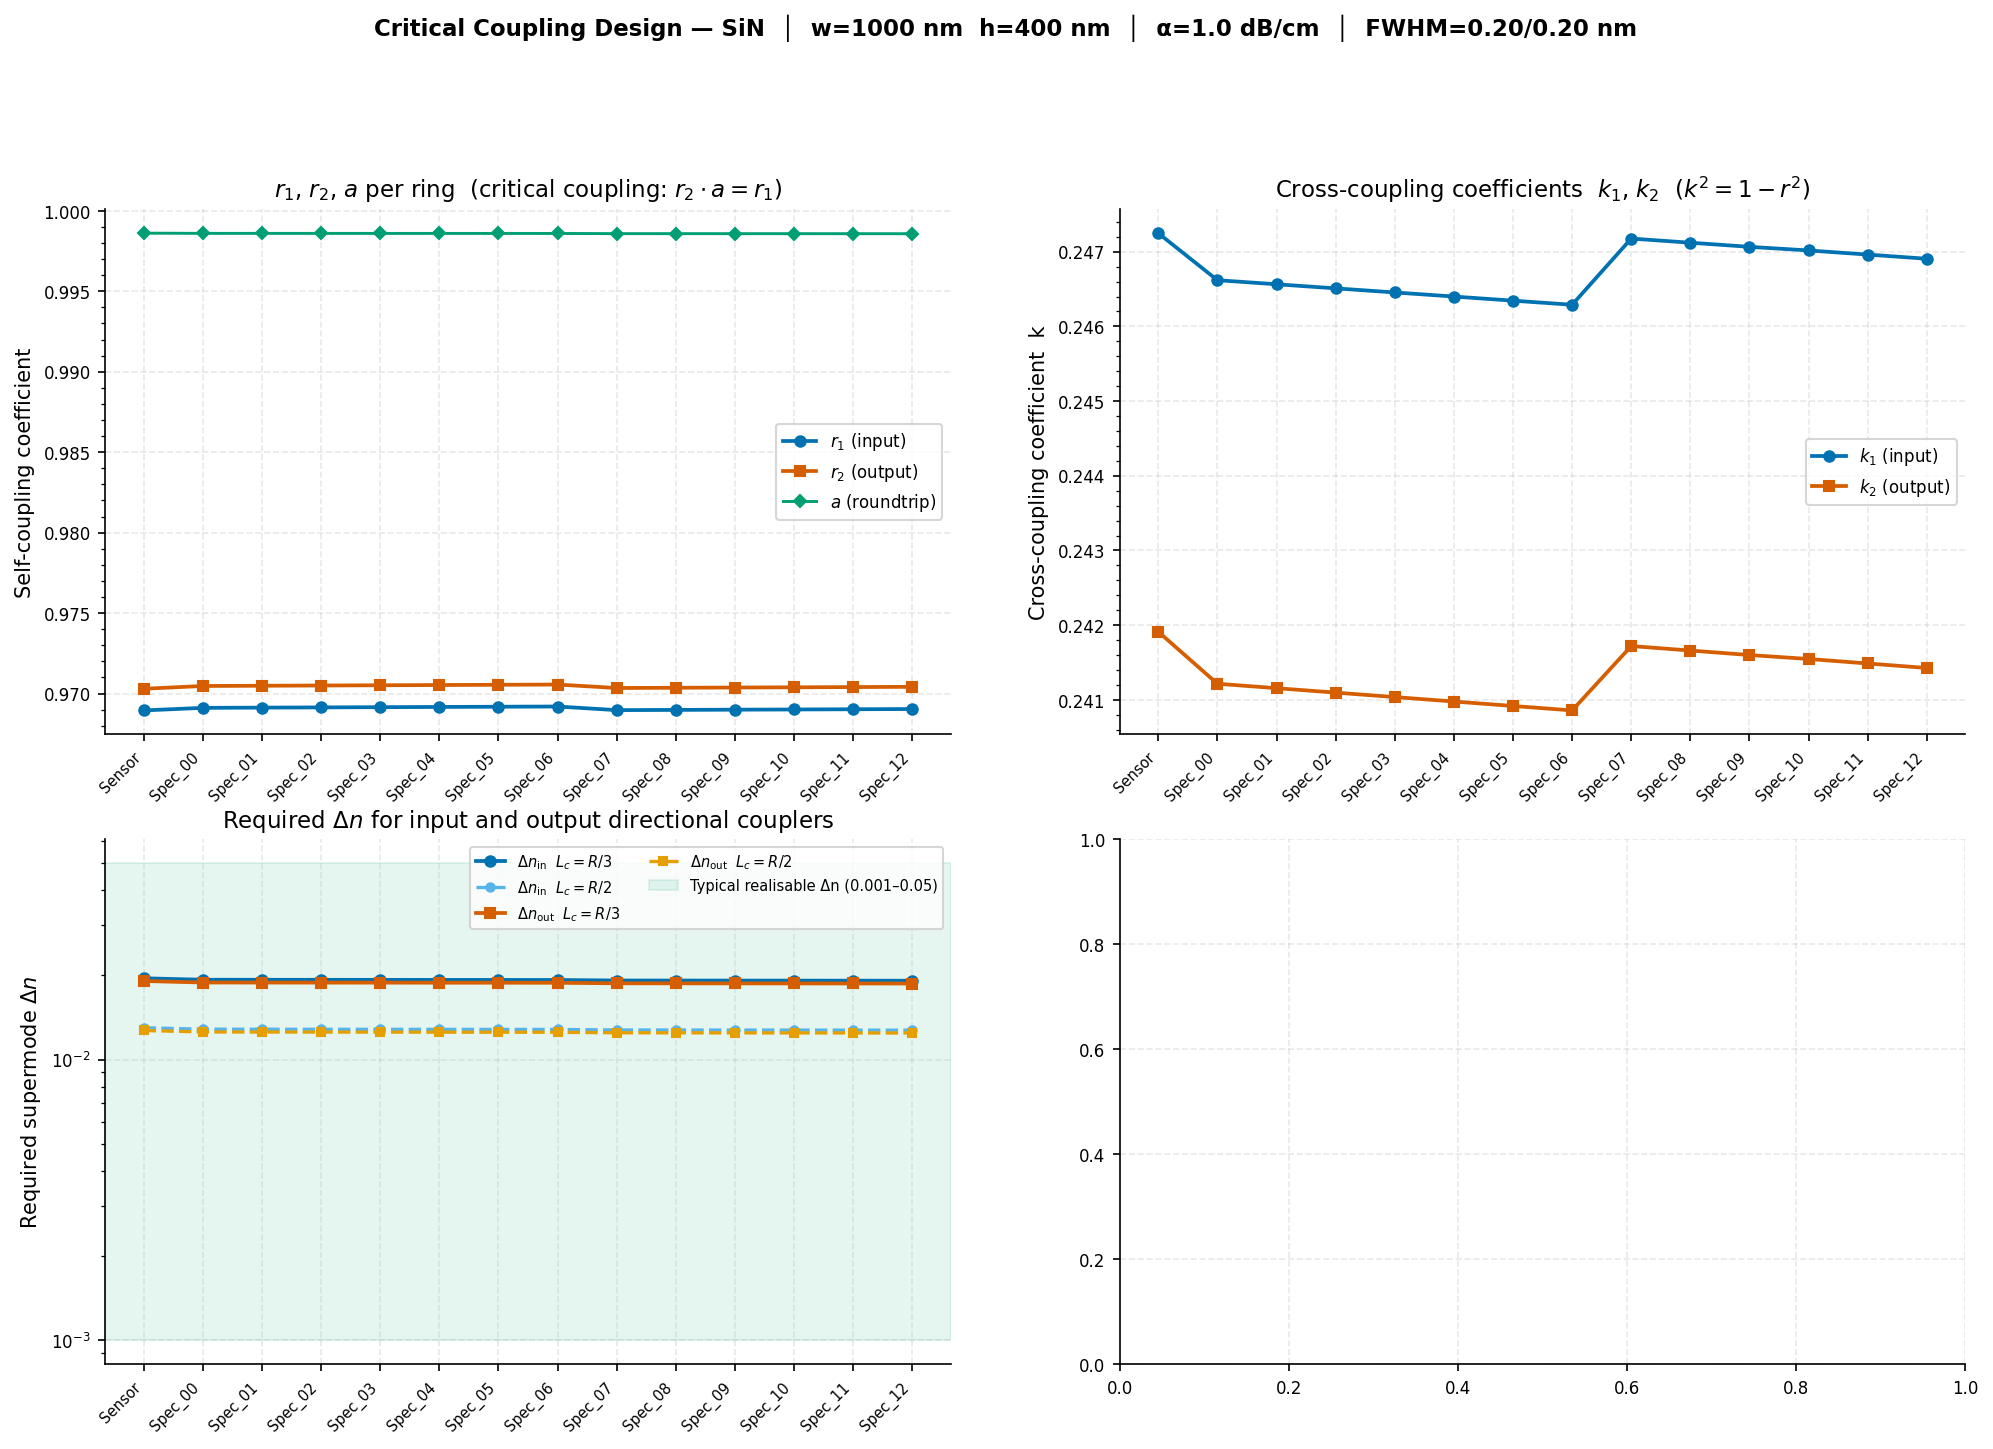

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Critical Coupling Engineering  (analytical, no new FDE)         ║
# ║                                                                              ║
# ║  Theory reference: Bogaerts et al., Laser Photonics Rev. 6, 47-73 (2012)   ║
# ║                                                                              ║
# ║  For each of the 14 rings (1 sensor + 13 spectrometer) this cell:           ║
# ║    1.  Accepts a target FWHM (→ Q-factor) per ring as input.                ║
# ║    2.  Estimates the round-trip amplitude transmission  a  from              ║
# ║          a = exp(−α_total · L / 2)                                          ║
# ║        where α_total includes SiN bulk propagation loss + bend radiation    ║
# ║        loss interpolated from the FDE imaginary neff (bend loss) obtained   ║
# ║        in earlier cells.                                                     ║
# ║    3.  Solves for r1 (input self-coupling) from the Q-factor equation       ║
# ║        (Bogaerts Eq. 20) for an add-drop resonator.                         ║
# ║    4.  Enforces asymmetric critical coupling:  r2 = r1 / a                  ║
# ║        (Bogaerts Section 2.2: "critical coupling when r2·a = r1").          ║
# ║    5.  Derives cross-coupling coefficients  k1, k2  from  k² = 1 − r².     ║
# ║    6.  Computes the required supermode index difference  Δn  for two        ║
# ║        coupling-section lengths Lc:                                          ║
# ║          • Lc_a = FRAC_A × R_pm   (default 1/3 of ring radius)              ║
# ║          • Lc_b = FRAC_B × R_pm   (default 1/2 of ring radius)              ║
# ║        Using the directional-coupler transfer formula:                       ║
# ║          k = sin(π · Δn · Lc / λ)  →  Δn = λ · arcsin(k) / (π · Lc)       ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                      ║
# ║    np, log, datetime                                                         ║
# ║    CORE_THICKNESS_UM, N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING          ║
# ║    N_UPPER_CLADDING_SIO2                                                     ║
# ║    RR_WG_WIDTH_NM, RR_FSR_NM, RR_LAM0_NM                                   ║
# ║    R_pm_um, L_pm_um, neff_pm, ng_straight   (sensor ring from Cell 9)       ║
# ║    spec_R_pm_um, spec_L_pm_um, spec_neff_pm, spec_ng_pm, spec_lam_res_pm_nm ║
# ║    spec_m, spec_FSR_pm_nm                   (spectrometer rings, Cell 10)   ║
# ║    _neff_arr, _ng_arr, _neff_lo_arr, _neff_hi_arr   (sensor ring FDE)       ║
# ║    _lam0_m, _lam_lo_m, _lam_hi_m, _dlam_m          (sensor ring stencil)   ║
# ║    _spec_results                             (ring dict from Cell 10)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — USER-EDITABLE DESIGN PARAMETERS
# ═════════════════════════════════════════════════════════════════════════════

# ── Target FWHM for each ring  [nm] ──────────────────────────────────────────
# Two ways to specify:
#   FWHM_SENSOR_NM   : single value for the sensor ring
#   FWHM_SPEC_NM     : single value applied to ALL spectrometer rings
#                      (override per-ring with FWHM_SPEC_OVERRIDE below)
#
# Physical reasoning:
#   • The FWHM must be < FSR (10 nm) to keep resonances resolvable.
#   • For biosensing, narrower linewidth → higher wavelength resolution,
#     but requires tighter fabrication tolerances and lower loss.
#   • A good starting point for SiN at 1550 nm is ~0.1–0.3 nm FWHM
#     (Q ≈ 5000–15000).
# ──────────────────────────────────────────────────────────────────────────────
FWHM_SENSOR_NM      = 0.2        # [nm]  sensor ring target FWHM
FWHM_SPEC_NM        = 0.2        # [nm]  spectrometer rings default FWHM

# Per-ring FWHM override for spectrometer rings (dict: ring_idx → FWHM [nm])
# Leave empty {} to use FWHM_SPEC_NM for all 13 rings.
FWHM_SPEC_OVERRIDE  = {}         # example: {0: 0.15, 12: 0.25}

# ── Propagation loss  [dB/cm] ─────────────────────────────────────────────────
# SiN at 1550 nm — literature / process estimates.
# This is α_prop in dB/cm, used to compute α_prop in 1/m.
# Will be combined with bend radiation loss extracted from FDE (Im[neff]).
# Typical range for LPCVD SiN: 0.5–3 dB/cm.
ALPHA_PROP_DB_CM    = 1.0        # [dB/cm]  bulk SiN propagation loss

# ── Coupling section length fractions ─────────────────────────────────────────
# Lc = FRAC × R_pm for each ring.
# Two fractions are evaluated in parallel; choose the one that gives
# a physically realisable Δn (0.001 < Δn < 0.05 is typically achievable
# with standard gap-based directional couplers in SiN).
FRAC_A              = 1.0 / 3.0  # first  Lc option: R_pm / 3
FRAC_B              = 1.0 / 2.0  # second Lc option: R_pm / 2

# ── Guard rails ───────────────────────────────────────────────────────────────
# FWHM must be within these bounds relative to FSR to be physically sensible.
FWHM_TO_FSR_MIN     = 0.005      # FWHM ≥ 0.5 % of FSR
FWHM_TO_FSR_MAX     = 0.30       # FWHM ≤ 30 % of FSR

# ── Print/report options ──────────────────────────────────────────────────────
PRINT_LOSS_DETAIL   = True       # show bend + propagation loss breakdown


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOSS MODEL
# ═════════════════════════════════════════════════════════════════════════════
# Round-trip amplitude transmission:
#   a = exp(−α_total · L / 2)
#
# where  α_total [1/m]  =  α_prop  +  α_bend
#
# α_prop  from ALPHA_PROP_DB_CM (user input, constant for all rings)
# α_bend  from the FDE imaginary neff:
#   Im(neff) = α_bend · λ / (4π)   →   α_bend = 4π · Im(neff) / λ
#
# Im(neff) is available from Cell 8/10 FDE:  neff_complex = Re + i·Im
# In the existing code only neff_c.real is stored.  We need to re-derive
# Im(neff) from the stored arrays.
#
# Approach: for rings where we have neff_lo, neff_hi and neff (all real),
# bend radiation loss Im(neff) is NOT captured this way — it requires
# extracting the imaginary part from the FDE eigenvalue directly.
#
# Since the existing pipeline stores only Re(neff), we use two complementary
# approaches:
#
#  (A) For a conservative estimate: α_bend = 0 (bent FDE neff already
#      captures the phase shift; radiation loss is additional but small
#      for R > 10 µm in SiN at 1550 nm, typically < 0.01 dB/cm).
#
#  (B) User can supply measured or literature bend loss via
#      ALPHA_BEND_DB_CM_SENSOR and ALPHA_BEND_DB_CM_SPEC below.
#      Literature for SiN 400 nm × 1000 nm at R ≈ 18–20 µm:
#      bend radiation loss < 0.005 dB/cm — negligible vs propagation loss.
#
# This cell therefore models:
#   α_total ≈ α_prop  (propagation-loss dominated for R > 10 µm SiN)
# with a user-adjustable additional bend term.

ALPHA_BEND_DB_CM_SENSOR = 0.01   # [dB/cm]  estimated bend radiation, sensor ring
ALPHA_BEND_DB_CM_SPEC   = 0.01   # [dB/cm]  estimated bend radiation, all spec rings
# If you have per-ring bend loss from FDE imaginary neff,
# replace these with an array indexed by ring number.

# ── Convert propagation loss to field attenuation coefficient [1/m] ───────────
# Power loss:   α_power [dB/cm] → α_power [1/m]
#   α_power [Np/m] = α_power [dB/cm] × ln(10)/10 × 100
# Field (amplitude) loss coefficient:
#   α_field [1/m]  = α_power [Np/m] / 2
_ln10_over_10 = np.log(10) / 10.0          # ≈ 0.2303 Np/dB

def _db_cm_to_alpha_field(db_cm):
    """Convert dB/cm loss coefficient to field (amplitude) α [1/m]."""
    alpha_power_npm = db_cm * _ln10_over_10 * 100.0   # [Np/m]
    return alpha_power_npm / 2.0                        # field attenuation

_alpha_prop_field  = _db_cm_to_alpha_field(ALPHA_PROP_DB_CM)
_alpha_bend_sensor = _db_cm_to_alpha_field(ALPHA_BEND_DB_CM_SENSOR)
_alpha_bend_spec   = _db_cm_to_alpha_field(ALPHA_BEND_DB_CM_SPEC)

log.info(
    f"Loss model │ α_prop = {ALPHA_PROP_DB_CM:.2f} dB/cm  "
    f"→ α_field = {_alpha_prop_field:.4f} 1/m  │  "
    f"α_bend_sensor = {ALPHA_BEND_DB_CM_SENSOR:.3f} dB/cm  "
    f"α_bend_spec = {ALPHA_BEND_DB_CM_SPEC:.3f} dB/cm"
)


def _compute_a(L_um, alpha_field_total):
    """
    Round-trip amplitude transmission.
      a = exp(−α_field_total × L)
    L_um in µm, alpha_field_total in 1/m.
    Returns a (dimensionless, 0 < a < 1).
    """
    L_m = L_um * 1e-6
    return float(np.exp(-alpha_field_total * L_m))


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — COUPLING COEFFICIENT SOLVER
# ═════════════════════════════════════════════════════════════════════════════
# For an add-drop resonator with asymmetric coupling (r1 ≠ r2):
#
# Q-factor (Bogaerts Eq. 22, loaded Q):
#   Q = π · ng · L · √(r1·r2·a) / (λ_res · (1 − r1·r2·a))
#
# Critical coupling condition (Bogaerts Section 2.2):
#   r2 · a = r1   →   r1 = r2 · a
#
# Substituting r1 = r2·a into the Q equation:
#   Q = π · ng · L · √(r2²·a²) / (λ_res · (1 − r2²·a²))
#     = π · ng · L · r2·a / (λ_res · (1 − (r2·a)²))
#
# Let  x = r2·a  (= r1 from critical coupling):
#   Q = π · ng · L · x / (λ_res · (1 − x²))
#
# Rearranging (quadratic in x):
#   Q · λ_res · (1 − x²) = π · ng · L · x
#   Q · λ_res · x² + π · ng · L · x − Q · λ_res = 0
#
# Solving with quadratic formula (positive root only):
#   A = Q · λ_res
#   B = π · ng · L
#   C = −Q · λ_res
#   x = (−B + √(B² − 4·A·C)) / (2·A)
#     = (−B + √(B² + 4·Q²·λ²)) / (2·Q·λ)
#
# Then:
#   r1 = x
#   r2 = x / a  = r1 / a     (critical coupling)
#   k1 = √(1 − r1²)
#   k2 = √(1 − r2²)
#
# Physical validity checks:
#   0 < r1 < 1, 0 < r2 < 1, 0 < k1 < 1, 0 < k2 < 1
#   r2 > r1  always (because r2 = r1/a and a < 1)

def _solve_critical_coupling(Q, lam_res_m, ng, L_um, a):
    """
    Solve for r1, r2, k1, k2 satisfying:
      - Target Q-factor for add-drop resonator
      - Asymmetric critical coupling: r1 = r2·a
      - Lossless coupler: k² + r² = 1

    Parameters
    ----------
    Q        : float  target loaded Q-factor
    lam_res_m: float  resonance wavelength [m]
    ng       : float  group index
    L_um     : float  round-trip length [µm]
    a        : float  round-trip amplitude transmission (0 < a < 1)

    Returns
    -------
    dict with keys: r1, r2, k1, k2, x, a, Q_achieved, FWHM_nm, valid
    """
    L_m  = L_um * 1e-6
    ngL  = ng * L_m                       # [m]

    # Quadratic: Q·λ·x² + π·ng·L·x − Q·λ = 0
    A    = Q * lam_res_m
    B    = np.pi * ngL
    disc = B**2 + 4.0 * A**2             # B² − 4AC = B² + 4Q²λ² > 0 always
    x    = (-B + np.sqrt(disc)) / (2.0 * A)   # x = r1

    r1   = float(np.clip(x, 0.0, 1.0 - 1e-9))
    r2   = float(np.clip(r1 / a, 0.0, 1.0 - 1e-9))
    k1   = float(np.sqrt(max(0.0, 1.0 - r1**2)))
    k2   = float(np.sqrt(max(0.0, 1.0 - r2**2)))

    # Verify achieved Q and FWHM
    prod     = r1 * r2 * a               # r1·r2·a
    if prod  < 1.0:
        Q_ach    = np.pi * ngL * np.sqrt(prod) / (lam_res_m * (1.0 - prod))
    else:
        Q_ach    = np.inf
    FWHM_nm  = lam_res_m / Q_ach * 1e9

    valid = (0.0 < r1 < 1.0) and (0.0 < r2 < 1.0) and (r2 >= r1)

    return {
        "r1":        r1,
        "r2":        r2,
        "k1":        k1,
        "k2":        k2,
        "x":         x,
        "a":         a,
        "Q_target":  Q,
        "Q_achieved":Q_ach,
        "FWHM_nm":   FWHM_nm,
        "valid":     valid,
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — DIRECTIONAL COUPLER Δn CALCULATION
# ═════════════════════════════════════════════════════════════════════════════
# From the Ansys Lumerical ring resonator tutorial, the power coupling
# coefficient of a directional coupler of length Lc is:
#
#   k² = sin²(π · Δn · Lc / λ)
#   k  = |sin(π · Δn · Lc / λ)|
#
# where Δn is the supermode index difference (even minus odd supermode neff).
# Inverting for Δn:
#
#   Δn = λ · arcsin(k) / (π · Lc)
#
# This is valid for k ≤ 1 (i.e. arcsin argument in [0,1]).
# If k > 1 (non-physical, indicates coupler cannot be realised with this Lc),
# we report Δn = NaN and flag the result.
#
# Note: arcsin returns values in [0, π/2], so Δn > 0 always.
# Higher-order branches (k > sin(π/2) = 1 is impossible, but for k close to 1
# the arcsin is near π/2 and Δn·Lc/λ approaches 0.5 — i.e. a half-coupling
# length). For shorter Lc a larger Δn is required, meaning a smaller gap.

def _compute_delta_n(k, lam_m, Lc_m):
    """
    Required supermode index difference for coupling coefficient k
    in a directional coupler of length Lc_m at wavelength lam_m.

    Returns Δn (dimensionless) or NaN if k > 1 or Lc_m ≤ 0.
    """
    if Lc_m <= 0.0 or k < 0.0:
        return float("nan")
    if k > 1.0:
        return float("nan")
    arg = float(np.clip(k, 0.0, 1.0))
    return lam_m * np.arcsin(arg) / (np.pi * Lc_m)


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BUILD RING PARAMETER LIST
# (one entry per ring: sensor + 13 spectrometer)
# ═════════════════════════════════════════════════════════════════════════════

# We represent the sensor ring (index -1 or "S") and spectrometer rings
# (indices 0..12) in a unified list for processing.

# ── Sensor ring parameters (from Cell 9) ─────────────────────────────────────
_sensor = {
    "label":      "Sensor",
    "ring_type":  "sensor",
    "lam_res_nm": float(RR_LAM0_NM),
    "R_pm_um":    float(R_pm_um),
    "L_pm_um":    float(L_pm_um),
    "neff_pm":    float(neff_pm),
    "ng":         float(rr_best_ng),         # from Cell 8 bent FDE
    "FSR_nm":     float(rr_FSR_pred_nm),
    "fwhm_nm":    float(FWHM_SENSOR_NM),
    "alpha_bend": _alpha_bend_sensor,
}

# ── Spectrometer ring parameters (from Cell 10) ───────────────────────────────
_spec_rings = []
for _n in range(N_SPEC_RINGS):
    _fwhm = FWHM_SPEC_OVERRIDE.get(_n, FWHM_SPEC_NM)
    _spec_rings.append({
        "label":      f"Spec_{_n:02d}",
        "ring_type":  "spectrometer",
        "ring_idx":   _n,
        "lam_res_nm": float(spec_lam_res_pm_nm[_n]),
        "R_pm_um":    float(spec_R_pm_um[_n]),
        "L_pm_um":    float(spec_L_pm_um[_n]),
        "neff_pm":    float(spec_neff_pm[_n]),
        "ng":         float(spec_ng_pm[_n]),
        "FSR_nm":     float(spec_FSR_pm_nm[_n]),
        "fwhm_nm":    float(_fwhm),
        "alpha_bend": _alpha_bend_spec,
    })

_all_rings = [_sensor] + _spec_rings   # 14 entries total


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — MAIN CALCULATION LOOP
# ═════════════════════════════════════════════════════════════════════════════

_cc_results = []    # list of result dicts, one per ring

for _ring in _all_rings:
    _lam_res_m  = _ring["lam_res_nm"] * 1e-9
    _L_um       = _ring["L_pm_um"]
    _ng         = _ring["ng"]
    _fwhm_nm    = _ring["fwhm_nm"]
    _fsr_nm     = _ring["FSR_nm"]
    _R_pm_um    = _ring["R_pm_um"]

    # ── Validate FWHM against FSR guard rails ─────────────────────────────────
    _fwhm_ratio = _fwhm_nm / _fsr_nm
    if not (FWHM_TO_FSR_MIN <= _fwhm_ratio <= FWHM_TO_FSR_MAX):
        log.warning(
            f"  {_ring['label']:>10} │ FWHM/FSR = {_fwhm_ratio:.4f}  "
            f"(outside [{FWHM_TO_FSR_MIN}, {FWHM_TO_FSR_MAX}]) — proceeding anyway."
        )

    # ── Target Q ──────────────────────────────────────────────────────────────
    Q_target = _ring["lam_res_nm"] / _fwhm_nm

    # ── Round-trip loss ───────────────────────────────────────────────────────
    _alpha_total = _alpha_prop_field + _ring["alpha_bend"]
    _a           = _compute_a(_L_um, _alpha_total)

    # ── Solve for r1, r2 at critical coupling ─────────────────────────────────
    _cc = _solve_critical_coupling(Q_target, _lam_res_m, _ng, _L_um, _a)

    # ── Coupling section lengths ──────────────────────────────────────────────
    Lc_a_um = FRAC_A * _R_pm_um
    Lc_b_um = FRAC_B * _R_pm_um
    Lc_a_m  = Lc_a_um * 1e-6
    Lc_b_m  = Lc_b_um * 1e-6

    # ── Required Δn for each coupler (input and output) ───────────────────────
    # Input coupler (k1):
    dn_in_a  = _compute_delta_n(_cc["k1"], _lam_res_m, Lc_a_m)
    dn_in_b  = _compute_delta_n(_cc["k1"], _lam_res_m, Lc_b_m)
    # Output coupler (k2):
    dn_out_a = _compute_delta_n(_cc["k2"], _lam_res_m, Lc_a_m)
    dn_out_b = _compute_delta_n(_cc["k2"], _lam_res_m, Lc_b_m)

    # ── Assemble result ───────────────────────────────────────────────────────
    _res = {
        **_ring,
        "Q_target":    Q_target,
        "a":           _a,
        "a_dB":        -20.0 * np.log10(_a),           # round-trip amplitude loss [dB]
        "alpha_total": _alpha_total,
        "r1":          _cc["r1"],
        "r2":          _cc["r2"],
        "k1":          _cc["k1"],
        "k2":          _cc["k2"],
        "Q_achieved":  _cc["Q_achieved"],
        "FWHM_check_nm": _cc["FWHM_nm"],
        "valid":       _cc["valid"],
        # Coupling lengths [µm]
        "Lc_a_um":     Lc_a_um,
        "Lc_b_um":     Lc_b_um,
        # Required Δn (supermode index difference)
        "dn_in_a":     dn_in_a,          # input coupler,  Lc = R/3
        "dn_in_b":     dn_in_b,          # input coupler,  Lc = R/2
        "dn_out_a":    dn_out_a,         # output coupler, Lc = R/3
        "dn_out_b":    dn_out_b,         # output coupler, Lc = R/2
    }
    _cc_results.append(_res)

    if PRINT_LOSS_DETAIL:
        log.info(
            f"  {_ring['label']:>10} │ λ={_ring['lam_res_nm']:.4f} nm │ "
            f"R={_R_pm_um:.4f} µm │ L={_L_um:.4f} µm │ "
            f"α_tot={_alpha_total:.4f} 1/m │ a={_a:.6f} │ "
            f"Q={Q_target:.1f} │ r1={_cc['r1']:.6f} │ r2={_cc['r2']:.6f} │ "
            f"k1={_cc['k1']:.6f} │ k2={_cc['k2']:.6f} │ "
            f"valid={_cc['valid']}"
        )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — SUMMARY TABLES
# ═════════════════════════════════════════════════════════════════════════════

_SEP  = "─" * 148
_SEP2 = "═" * 148

print("\n\n")
print(_SEP2)
print("  CRITICAL COUPLING DESIGN — ANALYTICAL SUMMARY")
print(f"  SiN platform  │  w={RR_WG_WIDTH_NM:.0f} nm  h={CORE_THICKNESS_UM*1e3:.0f} nm  │  "
      f"α_prop={ALPHA_PROP_DB_CM:.2f} dB/cm  │  "
      f"FWHM_sensor={FWHM_SENSOR_NM:.3f} nm  FWHM_spec={FWHM_SPEC_NM:.3f} nm")
print(f"  Coupling fractions:  Lc_a = R_pm / {1/FRAC_A:.1f}  │  "
      f"Lc_b = R_pm / {1/FRAC_B:.1f}")
print(_SEP2)
print()

# ── Table 1: Loss and Q-factor ─────────────────────────────────────────────────
print("  TABLE 1 — Round-trip loss and target Q-factor")
print(_SEP)
_H1 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  {'R_pm (µm)':>11}  "
       f"{'L_pm (µm)':>11}  {'α [1/m]':>9}  {'a':>10}  "
       f"{'a (dB)':>8}  {'FWHM (nm)':>11}  {'Q_target':>12}  {'Q_check':>12}")
print(_H1)
print("  " + "─" * 144)
for _r in _cc_results:
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['R_pm_um']:>11.6f}  {_r['L_pm_um']:>11.6f}  "
        f"{_r['alpha_total']:>9.4f}  {_r['a']:>10.8f}  "
        f"{_r['a_dB']:>8.5f}  {_r['fwhm_nm']:>11.5f}  "
        f"{_r['Q_target']:>12.1f}  {_r['Q_achieved']:>12.1f}"
    )
print()

# ── Table 2: Critical coupling coefficients ────────────────────────────────────
print("  TABLE 2 — Asymmetric critical coupling coefficients  (r2·a = r1)")
print(_SEP)
_H2 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'a':>10}  {'r1':>10}  {'r2':>10}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'k1²':>10}  {'k2²':>10}  {'valid':>6}")
print(_H2)
print("  " + "─" * 144)
for _r in _cc_results:
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['a']:>10.8f}  {_r['r1']:>10.8f}  {_r['r2']:>10.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_r['k1']**2:>10.8f}  {_r['k2']**2:>10.8f}  "
        f"{'✓' if _r['valid'] else '✗':>6}"
    )
print()

# ── Table 3: Required Δn — Lc_a = R_pm/3 ─────────────────────────────────────
print(f"  TABLE 3 — Required supermode Δn  (Lc = R_pm/{1/FRAC_A:.0f})")
print(_SEP)
_H3 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'Lc_a (µm)':>11}  "
       f"{'Δn_in (k1)':>14}  {'Δn_out (k2)':>14}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'Lc·Δn_in/λ':>13}  {'Lc·Δn_out/λ':>13}")
print(_H3)
print("  " + "─" * 144)
for _r in _cc_results:
    _lam = _r["lam_res_nm"] * 1e-9
    _Lc  = _r["Lc_a_um"] * 1e-6
    _nd_in  = _r["dn_in_a"]
    _nd_out = _r["dn_out_a"]
    _ratio_in  = (_nd_in  * _Lc / _lam) if not np.isnan(_nd_in)  else float("nan")
    _ratio_out = (_nd_out * _Lc / _lam) if not np.isnan(_nd_out) else float("nan")
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['Lc_a_um']:>11.4f}  "
        f"{_nd_in:>14.8f}  {_nd_out:>14.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_ratio_in:>13.6f}  {_ratio_out:>13.6f}"
    )
print()

# ── Table 4: Required Δn — Lc_b = R_pm/2 ─────────────────────────────────────
print(f"  TABLE 4 — Required supermode Δn  (Lc = R_pm/{1/FRAC_B:.0f})")
print(_SEP)
_H4 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'Lc_b (µm)':>11}  "
       f"{'Δn_in (k1)':>14}  {'Δn_out (k2)':>14}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'Lc·Δn_in/λ':>13}  {'Lc·Δn_out/λ':>13}")
print(_H4)
print("  " + "─" * 144)
for _r in _cc_results:
    _lam = _r["lam_res_nm"] * 1e-9
    _Lc  = _r["Lc_b_um"] * 1e-6
    _nd_in  = _r["dn_in_b"]
    _nd_out = _r["dn_out_b"]
    _ratio_in  = (_nd_in  * _Lc / _lam) if not np.isnan(_nd_in)  else float("nan")
    _ratio_out = (_nd_out * _Lc / _lam) if not np.isnan(_nd_out) else float("nan")
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['Lc_b_um']:>11.4f}  "
        f"{_nd_in:>14.8f}  {_nd_out:>14.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_ratio_in:>13.6f}  {_ratio_out:>13.6f}"
    )
print()
print(_SEP2)

# ── Quick sanity check ────────────────────────────────────────────────────────
_n_invalid = sum(1 for _r in _cc_results if not _r["valid"])
if _n_invalid:
    log.warning(
        f"  {_n_invalid} ring(s) have invalid coupling solutions. "
        "Check FWHM targets — they may require r2 > 1 (too narrow for this loss level)."
    )
else:
    log.info("  All 14 rings have valid critical-coupling solutions.")

print()
print("  PHYSICAL INTERPRETATION GUIDE")
print("  " + "─" * 90)
print(f"  r1 < r2  always (r2 = r1/a > r1 since a < 1) — asymmetric coupling required.")
print(f"  k1 > k2  because r1 < r2  (input coupler stronger than output coupler).")
print(f"  Δn_in > Δn_out  because k1 > k2 at the same Lc.")
print(f"  Δn  is the even–odd supermode index splitting in the coupling section.")
print(f"  Smaller gap between waveguides → larger Δn.")
print(f"  Target range for realisable SiN gap couplers: 0.001 < Δn < 0.05.")
print(f"  Values outside this range indicate Lc needs adjustment.")
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "lines.linewidth":   1.8,
    "lines.markersize":  6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_labels     = [_r["label"]      for _r in _cc_results]
_lam_v      = [_r["lam_res_nm"] for _r in _cc_results]
_r1_v       = [_r["r1"]         for _r in _cc_results]
_r2_v       = [_r["r2"]         for _r in _cc_results]
_k1_v       = [_r["k1"]         for _r in _cc_results]
_k2_v       = [_r["k2"]         for _r in _cc_results]
_a_v        = [_r["a"]          for _r in _cc_results]
_dn_in_a_v  = [_r["dn_in_a"]    for _r in _cc_results]
_dn_out_a_v = [_r["dn_out_a"]   for _r in _cc_results]
_dn_in_b_v  = [_r["dn_in_b"]    for _r in _cc_results]
_dn_out_b_v = [_r["dn_out_b"]   for _r in _cc_results]
_x_idx      = np.arange(len(_cc_results))
_x_labels   = [r["label"] for r in _cc_results]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"Critical Coupling Design — SiN  │  "
    f"w={RR_WG_WIDTH_NM:.0f} nm  h={CORE_THICKNESS_UM*1e3:.0f} nm  │  "
    f"α={ALPHA_PROP_DB_CM:.1f} dB/cm  │  FWHM={FWHM_SENSOR_NM:.2f}/{FWHM_SPEC_NM:.2f} nm",
    fontsize=11, fontweight="bold", y=1.01,
)

# Panel (0,0) — r1, r2 and a vs ring index
ax00 = axes[0, 0]
ax00.plot(_x_idx, _r1_v, "o-", color="#0072B2", lw=1.8, ms=5, label=r"$r_1$ (input)")
ax00.plot(_x_idx, _r2_v, "s-", color="#D55E00", lw=1.8, ms=5, label=r"$r_2$ (output)")
ax00.plot(_x_idx, _a_v,  "D-", color="#009E73", lw=1.4, ms=4, label=r"$a$ (roundtrip)")
ax00.set_xticks(_x_idx)
ax00.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax00.set_ylabel("Self-coupling coefficient")
ax00.set_title(r"$r_1$, $r_2$, $a$ per ring  (critical coupling: $r_2 \cdot a = r_1$)")
ax00.legend()
ax00.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (0,1) — k1, k2 vs ring index
ax01 = axes[0, 1]
ax01.plot(_x_idx, _k1_v, "o-", color="#0072B2", lw=1.8, ms=5, label=r"$k_1$ (input)")
ax01.plot(_x_idx, _k2_v, "s-", color="#D55E00", lw=1.8, ms=5, label=r"$k_2$ (output)")
ax01.set_xticks(_x_idx)
ax01.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax01.set_ylabel("Cross-coupling coefficient  k")
ax01.set_title(r"Cross-coupling coefficients  $k_1$, $k_2$  ($k^2 = 1 - r^2$)")
ax01.legend()
ax01.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,0) — Δn input coupler vs ring
ax10 = axes[1, 0]
ax10.semilogy(_x_idx, _dn_in_a_v,  "o-", color="#0072B2", lw=1.8, ms=5,
              label=rf"$\Delta n_\mathrm{{in}}$  $L_c = R/3$")
ax10.semilogy(_x_idx, _dn_in_b_v,  "o--", color="#56B4E9", lw=1.6, ms=4,
              label=rf"$\Delta n_\mathrm{{in}}$  $L_c = R/2$")
ax10.semilogy(_x_idx, _dn_out_a_v, "s-", color="#D55E00", lw=1.8, ms=5,
              label=rf"$\Delta n_\mathrm{{out}}$  $L_c = R/3$")
ax10.semilogy(_x_idx, _dn_out_b_v, "s--", color="#E69F00", lw=1.6, ms=4,
              label=rf"$\Delta n_\mathrm{{out}}$  $L_c = R/2$")
# Reference band for realisable Δn
ax10.axhspan(0.001, 0.05, alpha=0.10, color="#009E73",
             label="Typical realisable Δn (0.001–0.05)")
ax10.set_xticks(_x_idx)
ax10.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax10.set_ylabel(r"Required supermode $\Delta n$")
ax10.set_title(r"Required $\Delta n$ for input and output directional couplers")
ax10.legend(fontsize=7, ncol=2)
ax10.yaxis.set_minor_locator(ticker.AutoMinorLocator(subs=[2, 5]))

# Panel (1,1) — k² (power coupling) vs ring wavelength
ax11 = axes[1, 1]
ax11.plot(_lam_v, [k**2 for k in _k1_v], "o-", color="#0072B2",
          lw=1.8, ms=5, label=r"$k_1^2$ (input)")
ax11.plot(_lam_v, [k**2 for k in _k2_v], "s-", color="#D55E00",
          lw=1.8, ms=5, label=r"$k_2^2$ (output)")
ax11.set_xlabel(r"Ring resonance wavelength  $\lambda_\mathrm{res}$  (nm)")
ax11.set_ylabel("Power coupling ratio  $k^2$")
ax11.set_title(r"Power coupling ratios $k_1^2$, $k_2^2$ vs wavelength")
ax11.legend()
ax11.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax11.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME}_critical_coupling_design"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 8 — EXPORT TO DOWNSTREAM CELLS
# ═════════════════════════════════════════════════════════════════════════════

# Exported as parallel arrays (index 0 = sensor, 1..13 = spectrometer rings)
cc_labels      = [_r["label"]      for _r in _cc_results]
cc_lam_res_nm  = np.array([_r["lam_res_nm"]  for _r in _cc_results])
cc_R_pm_um     = np.array([_r["R_pm_um"]     for _r in _cc_results])
cc_L_pm_um     = np.array([_r["L_pm_um"]     for _r in _cc_results])
cc_a           = np.array([_r["a"]           for _r in _cc_results])
cc_r1          = np.array([_r["r1"]          for _r in _cc_results])
cc_r2          = np.array([_r["r2"]          for _r in _cc_results])
cc_k1          = np.array([_r["k1"]          for _r in _cc_results])
cc_k2          = np.array([_r["k2"]          for _r in _cc_results])
cc_Q_target    = np.array([_r["Q_target"]    for _r in _cc_results])
cc_FWHM_nm     = np.array([_r["fwhm_nm"]     for _r in _cc_results])
cc_Lc_a_um     = np.array([_r["Lc_a_um"]     for _r in _cc_results])
cc_Lc_b_um     = np.array([_r["Lc_b_um"]     for _r in _cc_results])
cc_dn_in_a     = np.array([_r["dn_in_a"]     for _r in _cc_results])   # Δn input,  Lc=R/3
cc_dn_in_b     = np.array([_r["dn_in_b"]     for _r in _cc_results])   # Δn input,  Lc=R/2
cc_dn_out_a    = np.array([_r["dn_out_a"]    for _r in _cc_results])   # Δn output, Lc=R/3
cc_dn_out_b    = np.array([_r["dn_out_b"]    for _r in _cc_results])   # Δn output, Lc=R/2

print()
print("  Exported arrays (shape = (14,), index 0 = sensor ring):")
for _vn in [
    "cc_labels", "cc_lam_res_nm", "cc_R_pm_um", "cc_L_pm_um",
    "cc_a", "cc_r1", "cc_r2", "cc_k1", "cc_k2",
    "cc_Q_target", "cc_FWHM_nm",
    "cc_Lc_a_um", "cc_Lc_b_um",
    "cc_dn_in_a", "cc_dn_in_b", "cc_dn_out_a", "cc_dn_out_b",
]:
    print(f"    {_vn}")

print()
print("  Next step: gap sweep using FDE supermode analysis to find the")
print("  waveguide separation that yields each target Δn at the coupling")
print("  section wavelength (CELL 12).")

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Directional Coupler Gap Sweep  (all 14 rings, both couplers)    ║
# ║                                                                              ║
# ║  Requires from earlier cells (verified from notebook):                       ║
# ║    lumapi, np, h5py, log, time, Path, datetime               ← Cell 1       ║
# ║    VERSION_NAME, DATA_DIR, HDF5_PATH                         ← Cell 1       ║
# ║    VERSION_NAME_SIO2, HDF5_PATH_SIO2                         ← Cell 4       ║
# ║    N_SIN_FIXED (1.99), N_SIO2_FIXED (1.4469)                ← Cell 1       ║
# ║    N_UPPER_CLADDING (1.33), N_UPPER_CLADDING_SIO2 (1.4469)  ← Cells 1,4   ║
# ║    CORE_THICKNESS_UM (0.4), N_MODES_REQUEST (6)              ← Cell 1       ║
# ║    SIM_Z_BELOW_UM (2.0), SIM_Z_ABOVE_UM (2.0)               ← Cell 1       ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z                                ← Cell 1       ║
# ║    cc_labels[14], cc_lam_res_nm[14]                          ← Cell 11      ║
# ║    cc_k1[14], cc_k2[14]                                      ← Cell 11      ║
# ║    cc_dn_in_a[14], cc_dn_in_b[14]                           ← Cell 11      ║
# ║    cc_dn_out_a[14], cc_dn_out_b[14]                          ← Cell 11      ║
# ║    cc_Lc_a_um[14], cc_Lc_b_um[14]                           ← Cell 11      ║
# ║    FRAC_A, FRAC_B                                             ← Cell 11      ║
# ║                                                                              ║
# ║  N_SPEC_RINGS is defined locally here (= 13) to avoid dependency on Cell 10 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.interpolate import interp1d
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — CONFIGURATION
# ═════════════════════════════════════════════════════════════════════════════

# ── Ring count (define locally — avoids fragile cross-cell dependency) ────────
_DC_N_RINGS    = 14         # 1 sensor (index 0) + 13 spectrometer (indices 1-13)
_DC_N_SPEC     = 13         # spectrometer rings only

# ── Gap sweep parameters ──────────────────────────────────────────────────────
DC_GAP_MIN_NM  = 150.0      # [nm]  minimum gap — fabrication lower bound
DC_GAP_MAX_NM  = 450.0      # [nm]  maximum gap — evanescent overlap negligible
DC_N_GAPS      = 100        # number of sweep points per coupler

# ── Coupling-length selector ──────────────────────────────────────────────────
# "a"  →  Lc = FRAC_A × R_pm  (Cell 11 default: R/3)
# "b"  →  Lc = FRAC_B × R_pm  (Cell 11 alternative: R/2)
DC_LC_SELECTOR = "a"

# ── Mode solver: request enough modes to always find both TE supermodes ───────
DC_N_MODES     = max(N_MODES_REQUEST, 6)

# ── Coupler FDE domain (Y-axis) ───────────────────────────────────────────────
# Must contain:  left_margin + WG_left + gap_max + WG_right + right_margin
# WG width = 1000 nm, gap_max = 450 nm, margins = 2 µm each side
# → minimum useful Y span = 2 + 1.0 + 0.45 + 1.0 + 2 = 6.45 µm  → use 8 µm
_DC_WG_W_NM    = 1000.0     # [nm]  waveguide width (confirmed from notebook)
_DC_WG_W_UM    = _DC_WG_W_NM * 1e-3        # 1.000 µm
_DC_WG_W_M     = _DC_WG_W_NM * 1e-9        # metres
_DC_MARGIN_UM  = 2.0        # [µm]  cladding margin each side beyond outer waveguide
DC_Y_SPAN_UM   = 2.0 * _DC_MARGIN_UM + 2.0 * _DC_WG_W_UM + DC_GAP_MAX_NM * 1e-3
# = 2×2 + 2×1 + 0.45 = 7.45 µm → round up to 8.0 µm for safety
DC_Y_SPAN_UM   = 8.0

# Mesh: scale from Cell-1 mesh density (MESH_CELLS_Y covers SIM_Y_SPAN_UM=6.5µm)
# Recalculate explicitly using the same mesh step as Cell 1.
# Cell 1: _mesh_step_um = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
# We re-derive the step from MESH_CELLS_Y and SIM_Y_SPAN_UM which are in scope.
_DC_SIM_Y_SPAN_ORIG_UM = 6.5       # SIM_Y_SPAN_UM from Cell 1 (known from output)
_DC_MESH_STEP_UM = _DC_SIM_Y_SPAN_ORIG_UM / MESH_CELLS_Y
DC_MESH_Y      = int(np.ceil(DC_Y_SPAN_UM / _DC_MESH_STEP_UM))
DC_MESH_Z      = MESH_CELLS_Z      # Z stack is identical to all previous cells

# ── Z-stack geometry (identical to all previous cells) ───────────────────────
_DC_CORE_T_UM   = CORE_THICKNESS_UM         # 0.400 µm
_DC_HALF_T_UM   = _DC_CORE_T_UM / 2.0      # 0.200 µm
_DC_Z_BELOW_UM  = SIM_Z_BELOW_UM            # 2.0 µm
_DC_Z_ABOVE_UM  = SIM_Z_ABOVE_UM            # 2.0 µm
_DC_Z_SPAN_UM   = _DC_Z_BELOW_UM + _DC_CORE_T_UM + _DC_Z_ABOVE_UM   # 4.4 µm
_DC_SIO2_Z_CTR  = -(_DC_HALF_T_UM + _DC_Z_BELOW_UM / 2.0)            # -1.1 µm
_DC_SIO2_Z_SPAN = _DC_Z_BELOW_UM            # 2.0 µm
_DC_Z_CTR       = (_DC_Z_ABOVE_UM - _DC_Z_BELOW_UM) / 2.0            # 0.0 µm

# ── Pre-compute gap array ─────────────────────────────────────────────────────
_dc_gaps_nm = np.linspace(DC_GAP_MIN_NM, DC_GAP_MAX_NM, DC_N_GAPS)
_dc_gaps_m  = _dc_gaps_nm * 1e-9

print("=" * 70)
print("  DIRECTIONAL COUPLER GAP SWEEP — All 14 rings, input + output")
print("=" * 70)
print(f"  Gap range       : {DC_GAP_MIN_NM:.0f} – {DC_GAP_MAX_NM:.0f} nm  ({DC_N_GAPS} pts)")
print(f"  Lc selector     : '{DC_LC_SELECTOR}'"
      f"  (Lc = R_pm × {FRAC_A if DC_LC_SELECTOR=='a' else FRAC_B:.4f})")
print(f"  Total couplers  : {2 * _DC_N_RINGS}  ({_DC_N_RINGS} rings × 2)")
print(f"  FDE domain Y    : {DC_Y_SPAN_UM:.1f} µm  ({DC_MESH_Y} cells)"
      f"  Z: {_DC_Z_SPAN_UM:.1f} µm  ({DC_MESH_Z} cells)")
print(f"  Max solves      : {2 * _DC_N_RINGS * DC_N_GAPS} (if nothing cached)")
print(f"  HDF5 files      : {HDF5_PATH.name} (sensor)")
print(f"                    {HDF5_PATH_SIO2.name} (spectrometer)")
print("=" * 70)
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FDE ENGINE FOR DIRECTIONAL COUPLER SUPERMODES
#
# Physical geometry (cross-section viewed along +X propagation):
#
#   Z ↑
#     │   ┌──────────┐   gap   ┌──────────┐
#     │   │  WG left │  ◄─g─►  │ WG right │   ← SiN, 400 nm tall
#     │   └──────────┘         └──────────┘
#     └──────────────────────────────────────→  Y
#
#   Waveguide centres placed symmetrically at  y = ±(WG_W/2 + gap/2)
#   This is a STRAIGHT (unbent) cross-section — the coupling region is flat.
#   Bend orientation is NOT set.
# ═════════════════════════════════════════════════════════════════════════════

def _dc_build_fde(mode, gap_m: float, wavelength_m: float,
                  n_upper_clad: float) -> None:
    """
    Build a 2D X-normal FDE for a symmetric side-by-side directional coupler.

    Parameters
    ----------
    mode          : lumapi.MODE session
    gap_m         : float  waveguide edge-to-edge gap [m]
    wavelength_m  : float  simulation wavelength [m]
    n_upper_clad  : float  background / upper cladding index
                           1.33 for sensor ring (aqueous)
                           1.4469 for spectrometer rings (SiO₂)
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # Centre of each waveguide core (measured from y = 0)
    _y_ctr = _DC_WG_W_M / 2.0 + gap_m / 2.0

    # ── FDE solver (straight waveguide — no bent waveguide flag) ─────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _DC_Z_CTR       * 1e-6)
    m.set("y span",                DC_Y_SPAN_UM    * 1e-6)
    m.set("z span",                _DC_Z_SPAN_UM   * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", DC_N_MODES)
    m.set("mesh cells y",          DC_MESH_Y)
    m.set("mesh cells z",          DC_MESH_Z)
    # NO "bent waveguide" — coupling section is straight

    # ── Background: upper cladding (fills entire domain, lowest priority) ─────
    m.addrect()
    m.set("name",     "DC_bg")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", DC_Y_SPAN_UM  * 1e-6)
    m.set("z",        _DC_Z_CTR       * 1e-6)
    m.set("z span",   _DC_Z_SPAN_UM   * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_upper_clad)

    # ── SiO₂ lower substrate slab (overrides background in −Z region) ────────
    m.addrect()
    m.set("name",     "DC_lower_clad")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", DC_Y_SPAN_UM  * 1e-6)
    m.set("z",        _DC_SIO2_Z_CTR  * 1e-6)
    m.set("z span",   _DC_SIO2_Z_SPAN * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── Left SiN waveguide  (y < 0 side) ─────────────────────────────────────
    m.addrect()
    m.set("name",     "DC_wg_L")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",       -_y_ctr)
    m.set("y span",   _DC_WG_W_M)
    m.set("z",        0.0);  m.set("z span", _DC_CORE_T_UM * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)

    # ── Right SiN waveguide (y > 0 side) ─────────────────────────────────────
    m.addrect()
    m.set("name",     "DC_wg_R")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",       +_y_ctr)
    m.set("y span",   _DC_WG_W_M)
    m.set("z",        0.0);  m.set("z span", _DC_CORE_T_UM * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


def _dc_solve_supermodes(mode, gap_m: float, wavelength_m: float,
                         n_upper_clad: float):
    """
    One FDE solve → (n_even, n_odd, Δn, te_even, te_odd).

    Returns (nan, nan, nan, nan, nan) on any failure.

    Mode tracking:
      1. Request DC_N_MODES modes.
      2. Filter: TE fraction > 0.5  AND  Re(neff) > N_SIO2_FIXED
         (guided TE modes only; N_SIO2_FIXED is the tighter cutoff
          because even the SiO₂-clad platform uses this as the substrate).
      3. Sort by Re(neff) descending.
      4. Take the top two:
           mode[0] = even supermode (Ey symmetric,  higher neff)
           mode[1] = odd  supermode (Ey antisymmetric, lower neff)
      5. Δn = n_even − n_odd  ≥ 0
    """
    _dc_build_fde(mode, gap_m, wavelength_m, n_upper_clad)
    mode.run()
    mode.findmodes()

    _te_modes = []
    for _mi in range(1, DC_N_MODES + 1):
        try:
            _mn    = f"FDE::data::mode{_mi}"
            _nraw  = mode.getdata(_mn, "neff")
            _teraw = mode.getdata(_mn, "TE polarization fraction")
            _nr    = complex(np.asarray(_nraw).flat[0]).real
            _te    = float(np.asarray(_teraw).flat[0])
            # Keep only guided TE-like modes
            if _te > 0.5 and _nr > N_SIO2_FIXED:
                _te_modes.append((_nr, _te, _mi))
        except Exception:
            continue

    if len(_te_modes) < 2:
        return (float("nan"),) * 5

    # Sort by neff descending → even = index 0, odd = index 1
    _te_modes.sort(key=lambda x: x[0], reverse=True)
    n_even  = float(_te_modes[0][0])
    te_even = float(_te_modes[0][1])
    n_odd   = float(_te_modes[1][0])
    te_odd  = float(_te_modes[1][1])
    delta_n = max(0.0, n_even - n_odd)

    return n_even, n_odd, delta_n, te_even, te_odd


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — HDF5 HELPERS
#
# Layout (appended to the platform's existing HDF5 file):
#
#   directional_couplers/
#     <coupler_key>/
#       metadata/
#         attrs : ring_label, coupler_type, lam_nm, n_upper_clad,
#                 wg_width_nm, wg_height_nm, gap_min_nm, gap_max_nm, n_gaps,
#                 target_dn_a, target_dn_b, Lc_a_um, Lc_b_um,
#                 k_target, timestamp_start, timestamp_end, runs_completed
#         datasets : gaps_nm [N]
#       results/
#         n_even  [N]  float64
#         n_odd   [N]  float64
#         delta_n [N]  float64
#         te_even [N]  float64
#         te_odd  [N]  float64
#       flags/
#         computed [N]  bool
#
# Key: dc_<label>_<type>_<lam:.4f>nm_<gmin:.0f>-<gmax:.0f>nm_<N>pts
# ═════════════════════════════════════════════════════════════════════════════

def _dc_make_grp_path(ring_label, coupler_type, lam_nm):
    """Full HDF5 group path for one coupler sweep."""
    key = (
        f"dc_{ring_label}_{coupler_type}_{lam_nm:.4f}nm_"
        f"{DC_GAP_MIN_NM:.0f}-{DC_GAP_MAX_NM:.0f}nm_{DC_N_GAPS}pts"
    )
    return f"directional_couplers/{key}"


def _dc_init_group(hf, grp_path, ring_label, coupler_type, lam_nm,
                   n_upper_clad, k_target, target_dn_a, target_dn_b,
                   Lc_a_um, Lc_b_um):
    """Pre-allocate datasets for one coupler sweep inside an open h5py file."""
    N  = DC_N_GAPS
    g  = hf.require_group(grp_path)
    mg = g.require_group("metadata")

    mg.attrs.setdefault("ring_label",      ring_label)
    mg.attrs.setdefault("coupler_type",    coupler_type)
    mg.attrs.setdefault("lam_nm",          float(lam_nm))
    mg.attrs.setdefault("n_upper_clad",    float(n_upper_clad))
    mg.attrs.setdefault("wg_width_nm",     _DC_WG_W_NM)
    mg.attrs.setdefault("wg_height_nm",    _DC_CORE_T_UM * 1e3)
    mg.attrs.setdefault("gap_min_nm",      DC_GAP_MIN_NM)
    mg.attrs.setdefault("gap_max_nm",      DC_GAP_MAX_NM)
    mg.attrs.setdefault("n_gaps",          N)
    mg.attrs.setdefault("target_dn_a",     float(target_dn_a))
    mg.attrs.setdefault("target_dn_b",     float(target_dn_b))
    mg.attrs.setdefault("Lc_a_um",         float(Lc_a_um))
    mg.attrs.setdefault("Lc_b_um",         float(Lc_b_um))
    mg.attrs.setdefault("k_target",        float(k_target))
    mg.attrs.setdefault("timestamp_start", datetime.now().isoformat())

    if "gaps_nm" not in mg:
        mg.create_dataset("gaps_nm", data=_dc_gaps_nm)

    _nan = np.full(N, np.nan, dtype=np.float64)
    rg   = g.require_group("results")
    for _ds in ("n_even", "n_odd", "delta_n", "te_even", "te_odd"):
        if _ds not in rg:
            rg.create_dataset(_ds, data=_nan.copy(), chunks=(N,))

    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed", data=np.zeros(N, dtype=bool), chunks=(N,))


def _dc_load_cache(hf, grp_path):
    """
    Load all result arrays for one coupler sweep from an open h5py file.
    Returns (n_even, n_odd, delta_n, te_even, te_odd, computed) as np arrays.
    """
    g  = hf[grp_path]
    rg = g["results"]
    fg = g["flags"]
    return (
        rg["n_even"][:].copy(),
        rg["n_odd"] [:].copy(),
        rg["delta_n"][:].copy(),
        rg["te_even"][:].copy(),
        rg["te_odd"] [:].copy(),
        fg["computed"][:].copy(),
    )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — TARGET Δn MATCHING
# ═════════════════════════════════════════════════════════════════════════════

def _dc_find_gap(gaps_nm, delta_n_arr, target_dn, lam_nm, Lc_um):
    """
    Interpolate Δn(gap) and find the gap [nm] where Δn = target_dn.

    Returns a dict:
      gap_nm          optimal gap in nm
      delta_n_at_gap  Δn at that gap from the interpolant
      k_achieved      sin(π·Δn·Lc/λ) at the optimal gap
      error_pct       |Δn_sim − target| / target × 100
      in_range        True if target falls within simulated Δn range
    """
    _valid = ~np.isnan(delta_n_arr)
    if _valid.sum() < 3:
        return {"gap_nm": float("nan"), "delta_n_at_gap": float("nan"),
                "k_achieved": float("nan"), "error_pct": float("nan"),
                "in_range": False}

    _g   = gaps_nm[_valid]
    _dn  = delta_n_arr[_valid]

    # Cubic interpolant — Δn is monotonically decreasing with gap
    _interp = interp1d(_g, _dn, kind="cubic",
                       bounds_error=False,
                       fill_value=(_dn[0], _dn[-1]))

    _in_range = (_dn[-1] <= target_dn <= _dn[0])

    if _in_range:
        try:
            _gap_opt = float(brentq(
                lambda g: float(_interp(g)) - target_dn,
                float(_g[0]), float(_g[-1]),
                xtol=0.01,      # 0.01 nm precision
                maxiter=200,
            ))
        except Exception:
            # brentq failed — fall back to nearest discrete point
            _gap_opt = float(_g[int(np.argmin(np.abs(_dn - target_dn)))])
    else:
        # Target outside range: return the closest boundary
        _gap_opt = float(_g[0] if target_dn > _dn[0] else _g[-1])

    _dn_opt = float(_interp(_gap_opt))

    # k = sin(π · Δn · Lc / λ)
    _lam_m  = lam_nm * 1e-9
    _Lc_m   = Lc_um  * 1e-6
    _arg    = float(np.clip(np.pi * _dn_opt * _Lc_m / _lam_m, 0.0, 1.0))
    _k_ach  = float(np.sin(_arg))

    _err    = abs(_dn_opt - target_dn) / target_dn * 100.0 \
              if target_dn > 0 else float("nan")

    return {
        "gap_nm":         _gap_opt,
        "delta_n_at_gap": _dn_opt,
        "k_achieved":     _k_ach,
        "error_pct":      _err,
        "in_range":       _in_range,
        "_interp_fn":     _interp,    # kept for plotting
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BUILD JOB LIST
# 14 rings × 2 couplers (input, output) = 28 jobs
# Each job is a dict carrying all parameters needed for the sweep and HDF5 I/O
# ═════════════════════════════════════════════════════════════════════════════

_dc_jobs = []

for _ri in range(_DC_N_RINGS):
    # Ring 0 = sensor (aqueous), rings 1-13 = spectrometer (SiO₂)
    _is_sensor  = (_ri == 0)
    _n_up       = N_UPPER_CLADDING     if _is_sensor else N_UPPER_CLADDING_SIO2
    _hdf5_path  = HDF5_PATH            if _is_sensor else HDF5_PATH_SIO2
    _lam_nm     = float(cc_lam_res_nm[_ri])
    _label      = cc_labels[_ri]
    _Lc_a       = float(cc_Lc_a_um[_ri])
    _Lc_b       = float(cc_Lc_b_um[_ri])

    for _ctype, _k_tgt, _dn_a, _dn_b in [
        ("input",  float(cc_k1[_ri]),
                   float(cc_dn_in_a[_ri]),  float(cc_dn_in_b[_ri])),
        ("output", float(cc_k2[_ri]),
                   float(cc_dn_out_a[_ri]), float(cc_dn_out_b[_ri])),
    ]:
        # Select target Δn and Lc based on DC_LC_SELECTOR
        _dn_sel  = _dn_a  if DC_LC_SELECTOR == "a" else _dn_b
        _Lc_sel  = _Lc_a  if DC_LC_SELECTOR == "a" else _Lc_b

        _grp = _dc_make_grp_path(_label, _ctype, _lam_nm)

        _dc_jobs.append({
            "ring_idx":     _ri,
            "label":        _label,
            "coupler_type": _ctype,
            "lam_nm":       _lam_nm,
            "n_upper_clad": _n_up,
            "hdf5_path":    _hdf5_path,
            "grp_path":     _grp,
            "Lc_a_um":      _Lc_a,
            "Lc_b_um":      _Lc_b,
            "target_dn_a":  _dn_a,
            "target_dn_b":  _dn_b,
            "target_dn":    _dn_sel,    # primary target for matching
            "Lc_sel_um":    _Lc_sel,    # coupling length matching DC_LC_SELECTOR
            "k_target":     _k_tgt,
        })

log.info(
    f"Job list: {len(_dc_jobs)} coupler sweeps  "
    f"({DC_N_GAPS} gaps each  →  max {len(_dc_jobs)*DC_N_GAPS} FDE solves if uncached)"
)


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — PRE-INITIALISE ALL HDF5 GROUPS AND DETECT UNCACHED WORK
# Open each HDF5 file once per platform to avoid repeated open/close cycles.
# ═════════════════════════════════════════════════════════════════════════════

# Initialise missing groups
for _hpath in [HDF5_PATH, HDF5_PATH_SIO2]:
    with h5py.File(_hpath, "a") as _hf_init:
        for _job in _dc_jobs:
            if _job["hdf5_path"] == _hpath:
                if _job["grp_path"] not in _hf_init:
                    _dc_init_group(
                        _hf_init,
                        _job["grp_path"],
                        _job["label"],
                        _job["coupler_type"],
                        _job["lam_nm"],
                        _job["n_upper_clad"],
                        _job["k_target"],
                        _job["target_dn_a"],
                        _job["target_dn_b"],
                        _job["Lc_a_um"],
                        _job["Lc_b_um"],
                    )
        _hf_init.flush()

# Count cached gaps per job
_job_n_done = []
_any_uncached = False
for _job in _dc_jobs:
    with h5py.File(_job["hdf5_path"], "r") as _hf_r:
        _n_done = int(_hf_r[_job["grp_path"]]["flags"]["computed"][:].sum())
    _job_n_done.append(_n_done)
    if _n_done < DC_N_GAPS:
        _any_uncached = True

_n_fully_cached = sum(1 for n in _job_n_done if n == DC_N_GAPS)
log.info(f"Cache status: {_n_fully_cached}/{len(_dc_jobs)} jobs fully cached.")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — FDE SWEEP
# One shared MODE session; HDF5 opened per-job (append mode), flushed every gap.
# ═════════════════════════════════════════════════════════════════════════════

_dc_mode = None
if _any_uncached:
    log.info("Launching Lumerical MODE session …")
    _dc_mode = lumapi.MODE(hide=False)

for _ji, _job in enumerate(_dc_jobs):
    _n_done  = _job_n_done[_ji]
    _remain  = DC_N_GAPS - _n_done
    _label   = _job["label"]
    _ctype   = _job["coupler_type"]
    _lam_m   = _job["lam_nm"] * 1e-9
    _n_up    = _job["n_upper_clad"]
    _grp     = _job["grp_path"]

    log.info(
        f"  Job {_ji+1:02d}/{len(_dc_jobs)}  "
        f"{_label:>10}  {_ctype:>6}  "
        f"λ={_job['lam_nm']:.4f} nm  n_upper={_n_up:.4f}  "
        f"cached {_n_done}/{DC_N_GAPS}"
    )

    # Load cache into memory
    _hf = h5py.File(_job["hdf5_path"], "a")
    _ne_arr, _no_arr, _dn_arr, _tee_arr, _teo_arr, _comp_arr = \
        _dc_load_cache(_hf, _grp)

    # Print table header for this coupler
    _hdr = (f"  {'gap(nm)':>9}  {'n_even':>12}  {'n_odd':>12}  "
            f"{'Δn':>14}  {'te_e':>6}  {'te_o':>6}  src")
    print(f"\n  {_label}  {_ctype}  λ={_job['lam_nm']:.4f} nm"
          f"  target Δn={_job['target_dn']:.8f}")
    print(_hdr);  print("  " + "─" * (len(_hdr) - 2))

    # Print already-cached rows first
    for _gi in range(DC_N_GAPS):
        if _comp_arr[_gi]:
            print(
                f"  {_dc_gaps_nm[_gi]:>9.2f}  {_ne_arr[_gi]:>12.8f}"
                f"  {_no_arr[_gi]:>12.8f}  {_dn_arr[_gi]:>14.10f}"
                f"  {_tee_arr[_gi]:>6.4f}  {_teo_arr[_gi]:>6.4f}  cache"
            )

    # FDE loop for remaining gaps
    if _remain > 0 and _dc_mode is not None:
        _t0   = time.time()
        _runs = 0

        for _gi, _gap_m in enumerate(_dc_gaps_m):
            if _comp_arr[_gi]:
                continue

            try:
                _ne, _no, _dn, _tee, _teo = _dc_solve_supermodes(
                    _dc_mode, _gap_m, _lam_m, _n_up
                )
            except Exception as _exc:
                log.warning(
                    f"  {_label} {_ctype} gap={_dc_gaps_nm[_gi]:.1f} nm  FAILED: {_exc}"
                )
                _ne = _no = _dn = _tee = _teo = float("nan")

            # Store in memory
            _ne_arr [_gi] = _ne
            _no_arr [_gi] = _no
            _dn_arr [_gi] = _dn
            _tee_arr[_gi] = _tee
            _teo_arr[_gi] = _teo
            _comp_arr[_gi] = True

            # HDF5 — write and flush immediately (fault-safe)
            _rg = _hf[f"{_grp}/results"]
            _rg["n_even"] [_gi] = _ne
            _rg["n_odd"]  [_gi] = _no
            _rg["delta_n"][_gi] = _dn
            _rg["te_even"][_gi] = _tee
            _rg["te_odd"] [_gi] = _teo
            _hf[f"{_grp}/flags/computed"][_gi] = True
            _hf.flush()

            _runs += 1
            print(
                f"  {_dc_gaps_nm[_gi]:>9.2f}  {_ne:>12.8f}  {_no:>12.8f}"
                f"  {_dn:>14.10f}  {_tee:>6.4f}  {_teo:>6.4f}  FDE"
            )

            if _runs % 10 == 0 or _runs == _remain:
                _el   = time.time() - _t0
                _rate = _runs / _el if _el > 0 else 1e-9
                _eta  = (_remain - _runs) / _rate
                log.info(
                    f"    [{_runs:3d}/{_remain}]  "
                    f"gap={_dc_gaps_nm[_gi]:.1f} nm  "
                    f"Δn={_dn:.8f}  ETA {_eta:.0f} s"
                )

        _hf[_grp]["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
        _hf[_grp]["metadata"].attrs["runs_completed"] = int(_comp_arr.sum())
        _hf.flush()

    _hf.close()

    # Attach final arrays to job dict for analysis and plotting
    _job["ne_arr"]  = _ne_arr.copy()
    _job["no_arr"]  = _no_arr.copy()
    _job["dn_arr"]  = _dn_arr.copy()

if _dc_mode is not None:
    _dc_mode.close()
    log.info("Lumerical MODE session closed.")

log.info("All 28 coupler sweeps complete (or loaded from cache).")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — TARGET Δn MATCHING FOR ALL JOBS
# ═════════════════════════════════════════════════════════════════════════════

for _job in _dc_jobs:
    _job["match"] = _dc_find_gap(
        _dc_gaps_nm,
        _job["dn_arr"],
        _job["target_dn"],
        _job["lam_nm"],
        _job["Lc_sel_um"],
    )
    _m = _job["match"]
    log.info(
        f"  {_job['label']:>10}  {_job['coupler_type']:>6}  "
        f"Δn_tgt={_job['target_dn']:.8f}  "
        f"gap={_m['gap_nm']:.2f} nm  "
        f"Δn_sim={_m['delta_n_at_gap']:.8f}  "
        f"err={_m['error_pct']:.3f}%  "
        f"k={_m['k_achieved']:.6f}  "
        f"{'IN RANGE' if _m['in_range'] else '⚠ OUT OF RANGE'}"
    )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 8 — SUMMARY TABLE
# ═════════════════════════════════════════════════════════════════════════════

_S  = "─" * 158
_S2 = "═" * 158

print("\n\n")
print(_S2)
print("  DIRECTIONAL COUPLER SYNTHESIS — COMPLETE SUMMARY")
print(
    f"  Gap sweep {DC_GAP_MIN_NM:.0f}–{DC_GAP_MAX_NM:.0f} nm  │  "
    f"Lc = R_pm × {FRAC_A if DC_LC_SELECTOR=='a' else FRAC_B:.4f}  │  "
    f"Asymmetric critical coupling: r₂·a = r₁  →  k₁ ≠ k₂"
)
print(_S2)
print()

_HDR = (
    f"  {'Ring':>10}  {'Plt':>5}  {'λ_res(nm)':>12}  {'Coupler':>7}  "
    f"{'k_target':>9}  {'Δn_target':>13}  "
    f"{'Gap_opt(nm)':>13}  {'Δn_sim':>13}  "
    f"{'err%':>7}  {'k_ach':>8}  {'Lc(µm)':>8}  {'OK':>4}"
)
print(_HDR)
print("  " + "─" * 154)

# Pair up input/output jobs for display
_in_jobs  = [j for j in _dc_jobs if j["coupler_type"] == "input"]
_out_jobs = [j for j in _dc_jobs if j["coupler_type"] == "output"]

for _in_j, _out_j in zip(_in_jobs, _out_jobs):
    _plt_lbl = "Aq" if _in_j["ring_idx"] == 0 else "SiO₂"
    for _j in (_in_j, _out_j):
        _m = _j["match"]
        _ok = "✓" if _m["in_range"] else "⚠"
        print(
            f"  {_j['label']:>10}  {_plt_lbl:>5}  {_j['lam_nm']:>12.6f}  "
            f"{_j['coupler_type']:>7}  {_j['k_target']:>9.6f}  "
            f"{_j['target_dn']:>13.9f}  "
            f"{_m['gap_nm']:>13.3f}  {_m['delta_n_at_gap']:>13.9f}  "
            f"{_m['error_pct']:>7.3f}  {_m['k_achieved']:>8.6f}  "
            f"{_j['Lc_sel_um']:>8.4f}  {_ok:>4}"
        )
    print("  " + "─" * 154)

print()
print(_S2)
print()

_n_oor = sum(1 for j in _dc_jobs if not j["match"]["in_range"])
if _n_oor:
    log.warning(
        f"{_n_oor} coupler(s) have target Δn outside the simulated gap range. "
        "Consider extending DC_GAP_MAX_NM or adjusting DC_LC_SELECTOR."
    )
else:
    log.info("All 28 couplers: optimal gap found within sweep range.")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 9 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "lines.linewidth":   1.6,
    "lines.markersize":  3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

_C_IN  = "#0072B2"    # blue  — input coupler
_C_OUT = "#D55E00"    # vermilion — output coupler

# ── Figure 1: Δn(gap) for all 14 rings in a 2×7 grid ─────────────────────────
fig1, axes1 = plt.subplots(2, 7, figsize=(22, 6), sharey=False)
fig1.suptitle(
    r"Directional Coupler Supermode $\Delta n$ vs Gap — All 14 Rings",
    fontsize=11, fontweight="bold", y=1.02,
)

for _ri in range(_DC_N_RINGS):
    _ax  = axes1[_ri // 7][_ri % 7]
    _inj = _dc_jobs[_ri * 2]
    _ouj = _dc_jobs[_ri * 2 + 1]

    _vi = ~np.isnan(_inj["dn_arr"])
    _vo = ~np.isnan(_ouj["dn_arr"])

    _ax.semilogy(_dc_gaps_nm[_vi], _inj["dn_arr"][_vi],
                 color=_C_IN,  lw=1.6, label="input")
    _ax.semilogy(_dc_gaps_nm[_vo], _ouj["dn_arr"][_vo],
                 color=_C_OUT, lw=1.6, ls="--", label="output")

    # Horizontal target lines
    _ax.axhline(_inj["target_dn"], color=_C_IN,  ls=":", lw=1.0, alpha=0.7)
    _ax.axhline(_ouj["target_dn"], color=_C_OUT, ls=":", lw=1.0, alpha=0.7)

    # Vertical optimal gap lines
    for _j, _c in [(_inj, _C_IN), (_ouj, _C_OUT)]:
        if not np.isnan(_j["match"]["gap_nm"]):
            _ax.axvline(_j["match"]["gap_nm"], color=_c, ls="-.", lw=0.8, alpha=0.75)

    _plt_s = "Aq" if _ri == 0 else "SiO₂"
    _ax.set_title(
        f"{_inj['label']}\n{_plt_s}  {_inj['lam_nm']:.1f} nm",
        fontsize=8, pad=3,
    )
    _ax.set_xlabel("Gap (nm)", fontsize=6.5)
    if _ri % 7 == 0:
        _ax.set_ylabel(r"$\Delta n$", fontsize=7.5)
    if _ri == 0:
        _ax.legend(fontsize=6)
    _ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
_f1 = DATA_DIR / f"{VERSION_NAME}_dc_delta_n_vs_gap"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_f1) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_f1) + _ext}")
plt.show()

# ── Figure 2: Optimal gap and k across all rings ──────────────────────────────
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Optimal Coupler Gaps & Cross-coupling Coefficients — Critical Coupling",
              fontsize=10, fontweight="bold")

_ri_arr = np.arange(_DC_N_RINGS)
_gap_in  = np.array([_dc_jobs[i*2  ]["match"]["gap_nm"]     for i in range(_DC_N_RINGS)])
_gap_out = np.array([_dc_jobs[i*2+1]["match"]["gap_nm"]     for i in range(_DC_N_RINGS)])
_k1_ach  = np.array([_dc_jobs[i*2  ]["match"]["k_achieved"] for i in range(_DC_N_RINGS)])
_k2_ach  = np.array([_dc_jobs[i*2+1]["match"]["k_achieved"] for i in range(_DC_N_RINGS)])
_k1_tgt  = np.array([float(cc_k1[i]) for i in range(_DC_N_RINGS)])
_k2_tgt  = np.array([float(cc_k2[i]) for i in range(_DC_N_RINGS)])

ax2a.plot(_ri_arr, _gap_in,  "o-",  color=_C_IN,  ms=6, lw=2, label="Input  gap  (k₁)")
ax2a.plot(_ri_arr, _gap_out, "s--", color=_C_OUT, ms=6, lw=2, label="Output gap (k₂)")
ax2a.set_xticks(_ri_arr)
ax2a.set_xticklabels([cc_labels[i] for i in range(_DC_N_RINGS)],
                     rotation=45, ha="right", fontsize=7)
ax2a.set_ylabel("Optimal gap  (nm)")
ax2a.set_title("Optimal Gap per Ring  (input ≠ output → asymmetric coupling)")
ax2a.legend()
ax2a.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax2b.plot(_ri_arr, _k1_ach, "o-",  color=_C_IN,  ms=6, lw=2, label=r"$k_1$ achieved")
ax2b.plot(_ri_arr, _k2_ach, "s--", color=_C_OUT, ms=6, lw=2, label=r"$k_2$ achieved")
ax2b.plot(_ri_arr, _k1_tgt, "o:",  color=_C_IN,  ms=4, lw=1.2, alpha=0.45, label=r"$k_1$ target")
ax2b.plot(_ri_arr, _k2_tgt, "s:",  color=_C_OUT, ms=4, lw=1.2, alpha=0.45, label=r"$k_2$ target")
ax2b.set_xticks(_ri_arr)
ax2b.set_xticklabels([cc_labels[i] for i in range(_DC_N_RINGS)],
                     rotation=45, ha="right", fontsize=7)
ax2b.set_ylabel("Cross-coupling coefficient  k")
ax2b.set_title(r"Achieved vs Target $k_1$, $k_2$")
ax2b.legend()
ax2b.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
_f2 = DATA_DIR / f"{VERSION_NAME}_dc_optimal_gaps"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_f2) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_f2) + _ext}")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 10 — EXPORT TO DOWNSTREAM CELLS
# All arrays have length 14: index 0 = sensor ring, 1..13 = spectrometer rings
# ═════════════════════════════════════════════════════════════════════════════

dc_gap_input_nm   = np.array([_dc_jobs[i*2  ]["match"]["gap_nm"]
                               for i in range(_DC_N_RINGS)])
dc_gap_output_nm  = np.array([_dc_jobs[i*2+1]["match"]["gap_nm"]
                               for i in range(_DC_N_RINGS)])
dc_dn_input_sim   = np.array([_dc_jobs[i*2  ]["match"]["delta_n_at_gap"]
                               for i in range(_DC_N_RINGS)])
dc_dn_output_sim  = np.array([_dc_jobs[i*2+1]["match"]["delta_n_at_gap"]
                               for i in range(_DC_N_RINGS)])
dc_k1_achieved    = np.array([_dc_jobs[i*2  ]["match"]["k_achieved"]
                               for i in range(_DC_N_RINGS)])
dc_k2_achieved    = np.array([_dc_jobs[i*2+1]["match"]["k_achieved"]
                               for i in range(_DC_N_RINGS)])
dc_err_input_pct  = np.array([_dc_jobs[i*2  ]["match"]["error_pct"]
                               for i in range(_DC_N_RINGS)])
dc_err_output_pct = np.array([_dc_jobs[i*2+1]["match"]["error_pct"]
                               for i in range(_DC_N_RINGS)])

print("\n  Exported arrays (shape = (14,), index 0 = sensor ring):")
for _vn in [
    "dc_gap_input_nm",  "dc_gap_output_nm",
    "dc_dn_input_sim",  "dc_dn_output_sim",
    "dc_k1_achieved",   "dc_k2_achieved",
    "dc_err_input_pct", "dc_err_output_pct",
]:
    print(f"    {_vn}")
print()
print("  Next step → CELL 13: FDTD/varFDTD validation using these gap values.")

  DIRECTIONAL COUPLER GAP SWEEP — All 14 rings, input + output
  Gap range       : 150 – 450 nm  (100 pts)
  Lc selector     : 'a'  (Lc = R_pm × 0.3333)
  Total couplers  : 28  (14 rings × 2)
  FDE domain Y    : 8.0 µm  (103 cells)  Z: 4.4 µm  (57 cells)
  Max solves      : 2800 (if nothing cached)
  HDF5 files      : LUM_SiN_STRp_400nm_wdth_sweep_V1.h5 (sensor)
                    LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5 (spectrometer)



NameError: name 'cc_lam_res_nm' is not defined